In [1]:

# Cell 1 — Imports + user paths
# Import the packages, define the class labels, and point the notebook to your real server folders.

from pathlib import Path  # Use pathlib so folder paths are easier to read and safer to join.
import json  # Read and write small settings and manifest files.
import itertools  # Build pairwise comparisons between runs.
from datetime import datetime  # Create readable timestamp-based default folder names.

import numpy as np  # Work with arrays and numeric values.
import pandas as pd  # Read CSV files and organize tables.
import zarr  # Open the dataset.zarr file without loading everything into memory.
import matplotlib.pyplot as plt  # Show images and save confusion-matrix figures.

import ipywidgets as widgets  # Build simple interactive controls inside the notebook.
from IPython.display import display, HTML, clear_output  # Show tables, widgets, and refreshed outputs.

from sklearn.metrics import confusion_matrix  # Build confusion-matrix counts from labels.

pd.set_option("display.max_columns", 200)  # Show many columns when a wide table is displayed.
pd.set_option("display.max_rows", 200)  # Show enough rows to inspect selected-run tables.
pd.set_option("display.width", 160)  # Make printed tables wrap less often.

CLASS_ORDER = ["gray_d", "gray_l", "red", "green", "blue", "yellow"]  # Keep the same label order used in your current workflow.
LABEL_TO_INT = {label: idx for idx, label in enumerate(CLASS_ORDER)}  # Convert text labels into integer class IDs.
INT_TO_LABEL = {idx: label for label, idx in LABEL_TO_INT.items()}  # Convert integer class IDs back to text labels.
KEY_TO_LABEL = {"a": "red", "s": "green", "d": "blue", "f": "yellow", "k": "gray_d", "l": "gray_l"}  # Map keyboard choices to class labels.
LABEL_TO_KEY = {label: key for key, label in KEY_TO_LABEL.items()}  # Build the reverse mapping for display.

COMBINE_GRAY_CLASSES = True  # 03.26.2026 Choose whether gray_d and gray_l are merged into one evaluation class called gray.
USE_HUMAN_REVIEW = False  # 03.26.2026 Choose whether downstream evaluation uses reviewed labels or only the automated true labels.
USE_PREVIOUS_HUMAN_LABELS = False  # 03.26.2026 Choose whether previously saved notebook and scope labels are reused when human review is enabled.
LOAD_SAVED_RESULTS_ONLY = False  # 03.26.2026 Choose whether the notebook skips new analysis work and only reloads saved files to rebuild figures.
EVAL_CLASS_ORDER = ["gray", "red", "green", "blue", "yellow"] if COMBINE_GRAY_CLASSES else list(CLASS_ORDER)  # 03.26.2026 Build the active evaluation class order from the gray-merge choice.
EVAL_MODE_SUFFIX = "gray_merged" if COMBINE_GRAY_CLASSES else "separate_gray"  # 03.26.2026 Build one short text label for the active gray-handling mode.
LABEL_SOURCE_SUFFIX = "human_review" if USE_HUMAN_REVIEW else "auto_labels"  # 03.26.2026 Build one short text label for the active label source.
NOTEBOOK_SUMMARY_FILE_NAME = f"simple_summary_human_review_long_{EVAL_MODE_SUFFIX}.csv" if USE_HUMAN_REVIEW else ("simple_summary_original_long_gray_merged.csv" if COMBINE_GRAY_CLASSES else "simple_summary_original_long.csv")  # 03.26.2026 Define the notebook-level long-summary filename for the active evaluation mode.
EVAL_OUTPUT_FOLDER_NAME = "gray_merged_outputs" if (not USE_HUMAN_REVIEW and COMBINE_GRAY_CLASSES) else f"{LABEL_SOURCE_SUFFIX}_{EVAL_MODE_SUFFIX}_outputs"  # 03.26.2026 Define one output-folder name for the active evaluation mode.


# -------------------------------------------------------------------------
# EDIT THESE PATHS FOR YOUR REMOTE SERVER BEFORE YOU RUN THE NOTEBOOK.
# -------------------------------------------------------------------------
RESULTS_ROOT = Path(".")  # Folder that contains the original saved result folders such as svm_mlr_rf_eval_20260317_010806.
DATASET_RUN_DIR = Path("export_retina_20260313_230715")  # Folder that contains dataset.zarr and metadata.csv on your remote server.
ZARR_PATH = DATASET_RUN_DIR / "dataset.zarr"  # Full path to the image dataset used by the saved runs.
META_PATH = DATASET_RUN_DIR / "metadata.csv"  # Full path to the metadata table used by the saved runs.
NOTEBOOK_OUTPUT_PARENT = Path(".")  # Parent folder where this new notebook will make or reuse one output directory.
DEFAULT_OUTPUT_DIR_NAME = "multi_run_review_" + datetime.now().strftime("%Y%m%d_%H%M%S")  # Default new output-folder name.

if not RESULTS_ROOT.exists():  # Stop early if the saved-results root folder is missing.
    raise FileNotFoundError("RESULTS_ROOT was not found: " + str(RESULTS_ROOT))  # Give a clear message about the missing results folder.

if not META_PATH.exists():  # Stop early if the metadata CSV is missing.
    raise FileNotFoundError("META_PATH was not found: " + str(META_PATH))  # Give a clear message about the missing metadata file.

if not ZARR_PATH.exists():  # Stop early if the dataset.zarr folder is missing.
    raise FileNotFoundError("ZARR_PATH was not found: " + str(ZARR_PATH))  # Give a clear message about the missing image dataset.

if "cividis" not in plt.colormaps():  # 03.26.2026 Check that the requested confusion-matrix colormap exists in this Python environment.
    raise ValueError("The 'cividis' colormap is not available in this environment, so the confusion-matrix cells cannot use the requested style.")  # 03.26.2026 Stop with a direct explanation when the requested colormap is unavailable.

print("RESULTS_ROOT:", RESULTS_ROOT.resolve())  # Show the resolved results-root path.
print("DATASET_RUN_DIR:", DATASET_RUN_DIR.resolve())  # Show the resolved dataset folder path.
print("ZARR_PATH:", ZARR_PATH.resolve())  # Show the resolved Zarr path.
print("META_PATH:", META_PATH.resolve())  # Show the resolved metadata path.
print("NOTEBOOK_OUTPUT_PARENT:", NOTEBOOK_OUTPUT_PARENT.resolve())  # Show where this notebook will store its own reusable files.

print("Gray handling mode:", EVAL_MODE_SUFFIX)  # 03.26.2026 Show the active gray-handling choice at the top of the notebook.
print("Label source mode:", LABEL_SOURCE_SUFFIX)  # 03.26.2026 Show whether the notebook will use human review or automated labels.
print("Reuse previous human labels:", USE_PREVIOUS_HUMAN_LABELS)  # 03.26.2026 Show whether prior saved labels will be reused when human review is enabled.
print("Load saved results only:", LOAD_SAVED_RESULTS_ONLY)  # 03.26.2026 Show whether the notebook will skip new analysis and only rebuild figures from saved files.


RESULTS_ROOT: /data/retina-neitz/notebooks
DATASET_RUN_DIR: /data/retina-neitz/notebooks/export_retina_20260313_230715
ZARR_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/dataset.zarr
META_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/metadata.csv
NOTEBOOK_OUTPUT_PARENT: /data/retina-neitz/notebooks
Gray handling mode: gray_merged
Label source mode: auto_labels
Reuse previous human labels: False
Load saved results only: False


In [2]:

# Cell 2 — Load metadata and open the dataset.zarr file
# Open the image dataset, check that stim_ID matches Zarr row order, and summarize the dataset.

root = zarr.open_group(str(ZARR_PATH), mode="r")  # Open the dataset.zarr group in read-only mode.
imgs_z = root["imgs"]  # Open the saved image array without loading the whole array into memory.

meta = pd.read_csv(META_PATH)  # Load the stimulus metadata table from disk.
meta = meta.copy()  # Make an explicit copy so later edits stay local to this notebook.
meta["stim_ID"] = meta["stim_ID"].astype(np.int64)  # Make sure stim_ID is an integer key.
meta = meta.set_index("stim_ID").sort_index()  # Use stim_ID as the canonical index and keep the rows ordered.

if "_obj_int_r" not in meta.columns:  # Recreate the rounded object-brightness helper column if it is not already present.
    meta["_obj_int_r"] = np.round(meta["obj_int"].astype(float), 6)  # Match the rounding style used in the current workflow.

if "_obj_sat_r" not in meta.columns:  # Recreate the rounded object-saturation helper column if it is not already present.
    meta["_obj_sat_r"] = np.round(meta["obj_sat"].astype(float), 6)  # Match the rounding style used in the current workflow.

N_IMAGES = int(imgs_z.shape[0])  # Read the total number of saved images from the Zarr file.
IMAGE_HEIGHT = int(imgs_z.shape[1])  # Read the image height from the Zarr file.
IMAGE_WIDTH = int(imgs_z.shape[2])  # Read the image width from the Zarr file.
N_CHANNELS = int(imgs_z.shape[3])  # Read the number of image channels from the Zarr file.

expected_stim_ids = np.arange(N_IMAGES, dtype=np.int64)  # Build the expected stim_ID sequence if rows and images are perfectly aligned.
actual_stim_ids = meta.index.to_numpy(dtype=np.int64)  # Read the actual ordered stim_ID values from the metadata table.

if not np.array_equal(actual_stim_ids, expected_stim_ids):  # Stop if the metadata rows do not line up exactly with the Zarr rows.
    raise ValueError("metadata.csv stim_ID order does not exactly match the first axis of dataset.zarr, so the image viewer would show the wrong images.")  # Explain why this alignment matters.

unknown_labels = sorted(set(meta["true_label"].astype(str).unique()) - set(CLASS_ORDER))  # Find any labels that are not part of the expected class order.
if unknown_labels:  # Stop if an unexpected label appears in the dataset.
    raise ValueError("metadata.csv contains unexpected true_label values: " + str(unknown_labels))  # Explain which labels caused the failure.

meta["true_label_int"] = meta["true_label"].astype(str).map(LABEL_TO_INT).astype(np.int64)  # Convert each true label into its integer class ID.
DATASET_LABEL_COUNTS = meta["true_label"].astype(str).value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)  # Count images in each class using the canonical order.

print("Dataset image shape:", (N_IMAGES, IMAGE_HEIGHT, IMAGE_WIDTH, N_CHANNELS))  # Show the basic image-array shape.
print("Metadata rows:", len(meta))  # Show how many rows are in the metadata table.
print("Label counts:", DATASET_LABEL_COUNTS.to_dict())  # Show the full dataset counts per true label.


Dataset image shape: (4710, 1000, 1000, 3)
Metadata rows: 4710
Label counts: {'gray_d': 925, 'gray_l': 925, 'red': 715, 'green': 715, 'blue': 715, 'yellow': 715}


In [3]:
# Cell 3 — Helper functions and scan of the saved result folders
# Define the reusable helper functions, scan for candidate result folders, and build one table the user can choose from later.

def build_run_key(model_name, group_name, run_dir_name):  # Create one readable unique ID for each saved model/group result.
    return f"{str(model_name)} | {str(group_name)} | {str(run_dir_name)}"  # Combine model, group, and folder name into one stable text key.


def sanitize_name(text):  # Convert free text into a simple folder-safe name.
    text = str(text).strip()  # Remove extra spaces around the text.
    text = text.replace(" ", "_")  # Replace spaces with underscores.
    safe_chars = []  # Collect the kept characters one at a time.
    for char in text:  # Check each character in the proposed name.
        if char.isalnum() or char in {"_", "-"}:  # Keep only simple file-name-safe characters.
            safe_chars.append(char)  # Add the allowed character to the output list.
    cleaned = "".join(safe_chars).strip("_")  # Join the kept characters and trim extra underscores.
    return cleaned if cleaned else "scope"  # Fall back to a simple name if nothing valid remains.


def resolve_artifact_path(results_root, run_dir, raw_path, allow_missing=False):  # Turn a stored relative path into a real local file path.
    raw_text = str(raw_path).strip()  # Read the incoming path value as plain text.
    if raw_text == "" or raw_text.lower() == "nan":  # Treat blank or NaN-like path text as missing.
        if allow_missing:  # Return None when a missing path is acceptable.
            return None  # Allow the notebook to keep going when an optional artifact path was not saved.
        raise FileNotFoundError("Artifact path was blank for run folder " + str(run_dir))  # Explain why the path could not be resolved.
    raw = Path(raw_text)  # Convert the text into a Path object.
    candidates = []  # Collect path candidates in the order we want to test them.
    if raw.is_absolute():  # Keep the absolute path if one was stored.
        candidates.append(raw)  # Test the absolute path directly first.
    candidates.append(run_dir / raw.name)  # Try the file inside the run folder using just its file name.
    candidates.append(run_dir / raw_text)  # Try the raw relative path inside the run folder.
    candidates.append(results_root / raw_text)  # Try the raw relative path inside the results-root folder.
    for candidate in candidates:  # Check each possible location one by one.
        if candidate.exists():  # Stop as soon as we find the first real file.
            return candidate  # Return the working path.
    if allow_missing:  # Return None instead of failing when a missing file can be rebuilt later.
        return None  # Allow the notebook to keep going when an optional artifact is missing.
    raise FileNotFoundError("Could not resolve artifact path: " + raw_text + " for run folder " + str(run_dir))  # Fail with a clear explanation.


def load_json_if_exists(path_obj):  # Read a JSON file only if it exists.
    if not Path(path_obj).exists():  # Return an empty dictionary when the file is missing.
        return {}  # Missing optional JSON files should not break the notebook scan.
    with open(path_obj, "r", encoding="utf-8") as infile:  # Open the JSON file safely.
        return json.load(infile)  # Load and return the parsed JSON data.


def normalize_review_df(review_df, model_name, group_name):  # Standardize old and new human-review CSV files to one shared schema.
    review_df = review_df.copy()  # Work on a copy so the caller's dataframe is not changed in place.
    required_numeric = ["review_order", "test_pos", "stim_id", "computer_pred_int", "true_label_int", "human_label_int"]  # List the numeric review columns that may need to exist.
    required_text = ["computer_pred_label", "true_label", "human_label", "saved_at", "review_model", "review_group"]  # List the text review columns that may need to exist.
    for column_name in required_numeric:  # Create each missing numeric column if needed.
        if column_name not in review_df.columns:  # Check whether the numeric column is missing.
            review_df[column_name] = np.nan  # Fill missing numeric columns with NaN values.
    for column_name in required_text:  # Create each missing text column if needed.
        if column_name not in review_df.columns:  # Check whether the text column is missing.
            review_df[column_name] = None  # Fill missing text columns with empty values.
    review_df["review_model"] = review_df["review_model"].fillna(str(model_name)).astype(str)  # Fill the model name when old files omitted it.
    review_df["review_group"] = review_df["review_group"].fillna(str(group_name)).astype(str)  # Fill the group name when old files omitted it.
    review_df["stim_id"] = pd.to_numeric(review_df["stim_id"], errors="coerce")  # Convert stim_id to numeric values.
    review_df["test_pos"] = pd.to_numeric(review_df["test_pos"], errors="coerce")  # Convert test_pos to numeric values.
    review_df["computer_pred_int"] = pd.to_numeric(review_df["computer_pred_int"], errors="coerce")  # Convert computer_pred_int to numeric values.
    review_df["true_label_int"] = pd.to_numeric(review_df["true_label_int"], errors="coerce")  # Convert true_label_int to numeric values.
    review_df["human_label_int"] = pd.to_numeric(review_df["human_label_int"], errors="coerce")  # Convert human_label_int to numeric values.
    return review_df  # Return the standardized review dataframe.


def expected_error_count_from_cm_table(cm_df):  # Count how many final-test errors the confusion-matrix table says a run should have.
    cm_df = cm_df.copy()  # Work on a copy for safety.
    cm_df["raw_count"] = pd.to_numeric(cm_df["raw_count"], errors="coerce").fillna(0).astype(int)  # Make sure raw_count is an integer column.
    cm_df["is_error"] = cm_df["is_error"].astype(bool)  # Convert the error flag into True or False values.
    return int(cm_df.loc[cm_df["is_error"], "raw_count"].sum())  # Sum the counts in every off-diagonal cell.


def build_test_df(meta_df, test_idx):  # Build one dataframe that describes the final test set in test-order.
    test_idx = np.asarray(test_idx, dtype=np.int64)  # Convert the incoming test indices into a clean integer array.
    test_df = meta_df.loc[test_idx].copy()  # Pull the matching metadata rows in exactly the saved test order.
    test_df = test_df.reset_index()  # Turn stim_ID back into a normal column for easier merges.
    test_df.insert(0, "test_pos", np.arange(len(test_df), dtype=np.int64))  # Add the position of each item within the final test set.
    return test_df  # Return the ordered final-test metadata table.


def reconstruct_misclassified_from_review(review_df, meta_df, test_df, model_name, group_name):  # Rebuild a missing misclassified CSV from the saved human-review file.
    review_df = normalize_review_df(review_df, model_name, group_name)  # Standardize the review-file schema first.
    review_df = review_df.loc[~review_df["stim_id"].isna()].copy()  # Keep only rows with a valid stim_id.
    review_df["stim_id"] = review_df["stim_id"].astype(np.int64)  # Convert stim_id to an integer key.
    review_df = review_df.sort_values(["stim_id", "review_order", "saved_at"], kind="mergesort")  # Put repeated reviews into a stable order.
    review_df = review_df.drop_duplicates(subset=["stim_id"], keep="last")  # Keep the most recent review row for each stim_id.
    review_df = review_df.rename(columns={"stim_id": "stim_ID", "computer_pred_label": "pred_label"})  # Rename columns so the output matches the misclassified CSV style.
    merged = test_df[["test_pos", "stim_ID", "true_label"]].merge(review_df[["stim_ID", "pred_label"]], on="stim_ID", how="inner")  # Keep only reviewed items that are in the test set.
    merged = merged.merge(meta_df.reset_index(), on=["stim_ID", "true_label"], how="left")  # Add the full metadata columns back to each reconstructed row.
    merged["model"] = str(model_name)  # Add the model name column expected in the misclassified table.
    merged["group"] = str(group_name)  # Add the group name column expected in the misclassified table.
    keep_order = ["test_pos", "stim_ID", "true_label", "bg_hue", "bg_r", "bg_g", "bg_b", "obj_r", "obj_g", "obj_b", "bg_int", "obj_int", "delta_int", "bg_sat", "obj_sat", "delta_sat", "hsv_bg", "hsv_obj", "delta_hsv", "_obj_int_r", "_obj_sat_r", "model", "group", "pred_label"]  # Define the beginner-friendly output column order.
    keep_cols = [column_name for column_name in keep_order if column_name in merged.columns]  # Keep only the columns that are available after the merge.
    merged = merged[keep_cols].copy()  # Reorder the columns into the chosen output order.
    return merged  # Return the reconstructed misclassified dataframe.


def load_misclassified_df(run_row, meta_df):  # Load the run's misclassified table, or rebuild it if the CSV is missing.
    split_data = np.load(run_row["split_path"])  # Open the saved train/test split file for this run.
    test_df = build_test_df(meta_df, split_data["test_idx"])  # Build the ordered final-test metadata table.
    misclassified_path = Path(run_row["misclassified_path"])  # Read the stored misclassified-file path.
    if misclassified_path.exists():  # Use the original misclassified CSV when it is available.
        misclassified_df = pd.read_csv(misclassified_path)  # Load the saved misclassified rows.
        if "test_pos" not in misclassified_df.columns:  # Recreate test_pos if the original CSV did not save it.
            misclassified_df = misclassified_df.merge(test_df[["test_pos", "stim_ID"]], on="stim_ID", how="left")  # Add the test position back by stim_ID.
    else:  # Rebuild the missing misclassified table from the saved human-review file.
        review_path = Path(run_row["human_review_path"])  # Read the stored human-review path.
        if not review_path.exists():  # Stop if neither a misclassified CSV nor a human-review CSV is available.
            raise FileNotFoundError("Missing both misclassified CSV and human-review CSV for run " + str(run_row["run_key"]))  # Explain which run could not be reconstructed.
        review_df = pd.read_csv(review_path)  # Load the human-review CSV.
        misclassified_df = reconstruct_misclassified_from_review(review_df, meta_df, test_df, run_row["model"], run_row["group"])  # Rebuild the missing table.
    misclassified_df = misclassified_df.copy()  # Work on a local copy.
    misclassified_df["stim_ID"] = pd.to_numeric(misclassified_df["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
    misclassified_df = misclassified_df.loc[~misclassified_df["stim_ID"].isna()].copy()  # Drop rows that still lack a valid stim_ID.
    misclassified_df["stim_ID"] = misclassified_df["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
    if "test_pos" not in misclassified_df.columns:  # Add test_pos if it is still missing after reconstruction.
        misclassified_df = misclassified_df.merge(test_df[["test_pos", "stim_ID"]], on="stim_ID", how="left")  # Add the test position by joining on stim_ID.
    misclassified_df["test_pos"] = pd.to_numeric(misclassified_df["test_pos"], errors="coerce")  # Convert test_pos into numeric values.
    misclassified_df = misclassified_df.loc[~misclassified_df["test_pos"].isna()].copy()  # Keep only rows with a valid test position.
    misclassified_df["test_pos"] = misclassified_df["test_pos"].astype(np.int64)  # Convert test_pos to integer type.
    misclassified_df["pred_label"] = misclassified_df["pred_label"].astype(str)  # Convert predicted labels to text.
    misclassified_df["true_label"] = misclassified_df["true_label"].astype(str)  # Convert true labels to text.
    misclassified_df = misclassified_df.sort_values(["test_pos", "stim_ID"], kind="mergesort")  # Put the rows into stable final-test order.
    misclassified_df = misclassified_df.drop_duplicates(subset=["stim_ID"], keep="last")  # Keep only one final row per misclassified stimulus.
    return misclassified_df, test_df  # Return the cleaned misclassified table and the matching test-set table.


def build_full_prediction_arrays(test_df, misclassified_df, expected_error_count):  # Rebuild the full test predictions using the true labels plus the saved misclassified rows.
    y_true_labels = test_df["true_label"].astype(str).tolist()  # Read the true labels for every item in the final test set.
    y_pred_labels = list(y_true_labels)  # Start with the correct label for every item.
    for row in misclassified_df.itertuples(index=False):  # Walk through each saved misclassified row.
        y_pred_labels[int(row.test_pos)] = str(row.pred_label)  # Overwrite the predicted label at that test position.
    observed_error_count = int(sum(true_label != pred_label for true_label, pred_label in zip(y_true_labels, y_pred_labels)))  # Count how many positions are now incorrect.
    if observed_error_count != int(expected_error_count):  # Stop if the rebuilt predictions disagree with the confusion-matrix table.
        raise ValueError("Rebuilt prediction error count does not match the confusion-matrix table. Expected " + str(expected_error_count) + ", observed " + str(observed_error_count))  # Explain the mismatch.
    y_true_int = np.asarray([LABEL_TO_INT[label] for label in y_true_labels], dtype=np.int64)  # Convert the true labels into integer class IDs.
    y_pred_int = np.asarray([LABEL_TO_INT[label] for label in y_pred_labels], dtype=np.int64)  # Convert the rebuilt predicted labels into integer class IDs.
    return y_true_int, y_pred_int  # Return both integer arrays for later confusion-matrix work.


def cm_long_from_predictions(y_true_int, y_pred_int, model_name, group_name, accuracy_value, summary_type, review_scope_name, n_human_reviewed_images):  # Convert predictions into the long table used for the simple summary CSV.
    cm_counts = confusion_matrix(y_true_int, y_pred_int, labels=list(range(len(CLASS_ORDER))))  # Build the raw confusion-matrix counts.
    row_totals = cm_counts.sum(axis=1).astype(np.int64)  # Count how many items belong to each true class.
    rows = []  # Collect one long-format row per confusion-matrix cell.
    for true_idx, true_label in enumerate(CLASS_ORDER):  # Walk through each true-label row.
        for pred_idx, pred_label in enumerate(CLASS_ORDER):  # Walk through each predicted-label column.
            raw_count = int(cm_counts[true_idx, pred_idx])  # Read the raw count in this cell.
            true_class_total = int(row_totals[true_idx])  # Read the row total for this true class.
            percent_value = (float(raw_count) / float(true_class_total) * 100.0) if true_class_total > 0 else 0.0  # Convert the raw count into a row-normalized percentage.
            rows.append({"model": str(model_name), "group": str(group_name), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "raw_count": raw_count, "true_class_total": true_class_total, "percent_of_true_class": percent_value, "final_test_accuracy": float(accuracy_value), "summary_type": str(summary_type), "review_scope_name": str(review_scope_name), "n_human_reviewed_images": int(n_human_reviewed_images), "n_test_images_total": int(len(y_true_int))})  # Save one long-format row for this cell.
    return pd.DataFrame(rows)  # Return the completed long-format confusion-matrix table.


def save_cm_png(cm_pct, out_path, title_text, annotate_numbers):  # Save one percentage confusion matrix as a PNG file.
    fig, ax = plt.subplots(figsize=(7, 7))  # Create one square figure.
    image = ax.imshow(cm_pct, cmap="berlin", vmin=0.0, vmax=100.0)  # Draw the row-normalized percentages using the Berlin colormap.
    ax.set_xticks(np.arange(len(CLASS_ORDER)))  # Put one tick at each predicted-label column.
    ax.set_yticks(np.arange(len(CLASS_ORDER)))  # Put one tick at each true-label row.
    ax.set_xticklabels(CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # Show the predicted labels on the x axis.
    ax.set_yticklabels(CLASS_ORDER)  # Show the true labels on the y axis.
    ax.set_xlabel("Predicted label")  # Label the x axis.
    ax.set_ylabel("True label")  # Label the y axis.
    ax.set_title(title_text)  # Add a descriptive figure title.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # Add the color scale bar.
    colorbar.set_label("Percent of true class")  # Label the colorbar.
    if annotate_numbers:  # Add one number to each cell when requested.
        for row_idx in range(cm_pct.shape[0]):  # Loop over rows.
            for col_idx in range(cm_pct.shape[1]):  # Loop over columns.
                value = float(cm_pct[row_idx, col_idx])  # Read the current cell value.
                text_color = "white" if value >= 50.0 else "black"  # Choose a readable text color for the background shade.
                ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=10)  # Write the percentage value into the cell.
    fig.subplots_adjust(left=0.22, bottom=0.20, right=0.92, top=0.90)  # Reserve room so the labels are not clipped.
    fig.savefig(out_path, dpi=150)  # Save the figure to disk.
    plt.close(fig)  # Close the figure so memory does not keep growing.


def initialize_output_dir(base_dir):  # Create the reusable folder structure used by this new notebook.
    base_dir.mkdir(parents=True, exist_ok=True)  # Create the main output directory if it does not already exist.
    (base_dir / "manifests").mkdir(exist_ok=True)  # Create the folder for saved manifest files.
    (base_dir / "summaries").mkdir(exist_ok=True)  # Create the folder for summary CSV files.
    (base_dir / "shared_misclassified").mkdir(exist_ok=True)  # Create the folder for shared-misclassification tables.
    (base_dir / "cache").mkdir(exist_ok=True)  # Create the folder for reusable notebook-level human labels.
    (base_dir / "review_scopes").mkdir(exist_ok=True)  # Create the folder for each saved review scope.
    cache_path = base_dir / "cache" / "review_cache_master.csv"  # Define the path to the notebook's reusable review-label cache.
    if not cache_path.exists():  # Make an empty cache file the first time this output folder is used.
        empty_cache = pd.DataFrame(columns=["review_order", "scope_name", "stim_id", "test_pos", "true_label", "human_key", "human_label", "human_label_int", "saved_at", "selected_run_keys", "previous_cache_hit"])  # Create an empty dataframe with the notebook cache schema.
        empty_cache.to_csv(cache_path, index=False)  # Save the empty cache file to disk.
    return cache_path  # Return the cache path for later use.


def load_notebook_cache(cache_path):  # Load the notebook-level human-label cache.
    cache_path = Path(cache_path)  # Convert the incoming value into a Path object.
    if not cache_path.exists():  # Return an empty dataframe when the cache file does not exist yet.
        return pd.DataFrame(columns=["review_order", "scope_name", "stim_id", "test_pos", "true_label", "human_key", "human_label", "human_label_int", "saved_at", "selected_run_keys", "previous_cache_hit"])  # Use the expected cache schema.
    cache_df = pd.read_csv(cache_path)  # Load the saved cache CSV.
    if len(cache_df) == 0:  # Return the empty dataframe directly if no rows have been saved yet.
        return cache_df  # Nothing else is needed for an empty cache.
    cache_df["stim_id"] = pd.to_numeric(cache_df["stim_id"], errors="coerce")  # Convert stim_id into numeric values.
    cache_df = cache_df.loc[~cache_df["stim_id"].isna()].copy()  # Keep only rows with a valid stim_id.
    cache_df["stim_id"] = cache_df["stim_id"].astype(np.int64)  # Convert stim_id to integer type.
    return cache_df  # Return the cleaned cache dataframe.


def latest_cache_by_stim(cache_df):  # Keep only the newest notebook-cache row for each stim_id.
    if len(cache_df) == 0:  # Return the empty dataframe unchanged when no cache rows exist yet.
        return cache_df.copy()  # There is nothing to group or sort.
    work_df = cache_df.copy()  # Work on a copy so the caller's dataframe stays unchanged.
    if "saved_at" not in work_df.columns:  # Create a saved_at column if an old cache file is missing it.
        work_df["saved_at"] = ""  # Fill the missing column with empty text.
    work_df = work_df.sort_values(["stim_id", "saved_at", "review_order"], kind="mergesort")  # Put repeated rows into a stable order.
    work_df = work_df.drop_duplicates(subset=["stim_id"], keep="last")  # Keep only the most recent row for each stim_id.
    return work_df  # Return one latest cache row per stim_id.


def save_json(path_obj, payload):  # Save a small dictionary as JSON with readable indentation.
    with open(path_obj, "w", encoding="utf-8") as outfile:  # Open the output JSON file safely.
        json.dump(payload, outfile, indent=2)  # Write the dictionary with indentation for readability.


def refresh_simple_summary_master(note_output_dir):  # 03.26.2026 Combine every notebook-level simple-summary long table into one master CSV.
    summaries_dir = Path(note_output_dir) / "summaries"  # 03.26.2026 Build the summaries-folder path from the chosen notebook output directory.
    master_parts = []  # 03.26.2026 Collect every matching long-format summary table here.
    for summary_csv_path in sorted(summaries_dir.glob("simple_summary_*long*.csv")):  # 03.26.2026 Look for every saved notebook-level simple-summary long CSV.
        if summary_csv_path.name == "simple_summary_master.csv":  # 03.26.2026 Skip the master file itself so it is not loaded back into itself.
            continue  # 03.26.2026 Move on to the next summaries-folder CSV.
        master_parts.append(pd.read_csv(summary_csv_path))  # 03.26.2026 Load and append this notebook-level long summary table.
    if len(master_parts) == 0:  # 03.26.2026 Stop with a helpful message if no long-format summary tables were found.
        raise FileNotFoundError("No notebook-level simple summary tables were found in the summaries folder, so the master summary could not be built yet.")  # 03.26.2026 Explain why the master table is missing.
    master_df = pd.concat(master_parts, ignore_index=True)  # 03.26.2026 Stack all long-format summary tables into one dataframe.
    master_path = summaries_dir / "simple_summary_master.csv"  # 03.26.2026 Define the final master-summary output path.
    master_df.to_csv(master_path, index=False)  # 03.26.2026 Save the combined master-summary CSV.
    return master_df, master_path  # 03.26.2026 Return both the combined dataframe and the saved path.


scan_records = []  # Collect one record per candidate saved run that the user may choose later.
skipped_run_dirs = []  # Collect one record per folder that was ignored during the light discovery scan.

for run_dir in sorted(RESULTS_ROOT.iterdir()):  # Look through every item in the results-root folder.
    if not run_dir.is_dir():  # Skip files and keep only folders.
        continue  # Move on to the next item.
    if run_dir.name.startswith(".") or run_dir.name.startswith("__") or run_dir.name.startswith("._"):  # Ignore hidden and helper folders.
        continue  # Move on to the next item.
    eval_summary_path = run_dir / "eval_summary.csv"  # Build the path to the summary table expected in each candidate folder.
    if not eval_summary_path.exists():  # Skip folders that are not saved-result candidates.
        continue  # Move on to the next item.
    try:  # Try to read this candidate folder without doing any deep validation yet.
        run_context = load_json_if_exists(run_dir / "run_context.json")  # Load the run context if it exists.
        eval_summary_df = pd.read_csv(eval_summary_path)  # Load the per-run evaluation summary table.
        eval_summary_df.columns = [str(column_name).strip() for column_name in eval_summary_df.columns]  # Remove stray spaces from the CSV column names.
        required_eval_columns = {"model", "group"}  # Require only the columns needed to present choices to the user.
        missing_eval_columns = sorted(required_eval_columns - set(eval_summary_df.columns))  # Find any required discovery columns that are missing.
        if missing_eval_columns:  # Skip folders that cannot even identify model/group rows.
            skipped_run_dirs.append({"run_dir_name": run_dir.name, "reason": "missing_eval_summary_columns", "details": ", ".join(missing_eval_columns)})  # Record why this folder was skipped.
            continue  # Move on to the next folder.
        split_path = run_dir / "split_indices.npz"  # Build the expected split-file path, but do not require it yet.
        for _, eval_row in eval_summary_df.iterrows():  # Read one saved model/group row at a time.
            model_name = str(eval_row.get("model", "")).strip()  # Read the model name as text.
            group_name = str(eval_row.get("group", "")).strip()  # Read the group name as text.
            if model_name == "" or group_name == "":  # Skip rows that do not identify a model/group pair.
                continue  # Move on to the next row.
            run_key = build_run_key(model_name, group_name, run_dir.name)  # Build one unique key for this candidate run.
            raw_cm_table_path = eval_row.get("cm_table_path", "")  # Read the saved confusion-matrix-table path when that column exists.
            cm_table_path = resolve_artifact_path(RESULTS_ROOT, run_dir, raw_cm_table_path, allow_missing=True) if str(raw_cm_table_path).strip() else None  # Resolve the path only when one was saved.
            misclassified_path = run_dir / f"misclassified_{model_name}_{group_name}.csv"  # Build the expected misclassified CSV path.
            human_review_path = run_dir / f"human_review_labels_{model_name}_{group_name}.csv"  # Build the expected human-review CSV path.
            dataset_zarr_path = str(run_context.get("ZARR_PATH", ""))  # Read the dataset.zarr path from the saved run context.
            dataset_meta_path = str(run_context.get("META_PATH", ""))  # Read the metadata.csv path from the saved run context.
            dataset_run_dir_name = Path(dataset_zarr_path).parts[0] if dataset_zarr_path else ""  # Read the dataset run-folder name from the saved Zarr path.
            scan_records.append({"run_key": run_key, "model": model_name, "group": group_name, "run_dir_name": run_dir.name, "run_dir_path": str(run_dir), "eval_summary_path": str(eval_summary_path), "split_path": str(split_path), "split_available": bool(split_path.exists()), "cm_table_path": str(cm_table_path) if cm_table_path is not None else "", "cm_table_available": bool(cm_table_path is not None and Path(cm_table_path).exists()), "misclassified_path": str(misclassified_path), "misclassified_available": bool(misclassified_path.exists()), "human_review_path": str(human_review_path), "human_review_available": bool(human_review_path.exists()), "test_acc": pd.to_numeric(pd.Series([eval_row.get("test_acc", np.nan)]), errors="coerce").iloc[0], "cv_mean": pd.to_numeric(pd.Series([eval_row.get("cv_mean", np.nan)]), errors="coerce").iloc[0], "dataset_run_dir_name": dataset_run_dir_name, "dataset_zarr_path": dataset_zarr_path, "dataset_meta_path": dataset_meta_path})  # Save one candidate record for later user selection.
    except Exception as error_message:  # Catch unexpected read problems so one bad folder does not stop discovery.
        skipped_run_dirs.append({"run_dir_name": run_dir.name, "reason": "read_error", "details": str(error_message)})  # Record why this folder was skipped.
        continue  # Move on to the next folder.

AVAILABLE_RUNS_DF = pd.DataFrame(scan_records)  # Convert the scan records into one dataframe.
if len(AVAILABLE_RUNS_DF) == 0:  # Stop if no candidate saved result folders were found.
    raise RuntimeError("No candidate saved result folders with readable eval_summary.csv were found inside RESULTS_ROOT.")  # Explain why the notebook cannot continue.
AVAILABLE_RUNS_DF = AVAILABLE_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the available runs into a stable readable order.

SKIPPED_RUN_DIRS_DF = pd.DataFrame(skipped_run_dirs)  # Convert the skipped-folder records into one dataframe.

print("Candidate saved runs found:", len(AVAILABLE_RUNS_DF))  # Show how many selectable model/group rows were found.
display(AVAILABLE_RUNS_DF[["run_key", "model", "group", "run_dir_name", "split_available", "cm_table_available", "misclassified_available", "human_review_available", "test_acc", "cv_mean"]])  # Display the candidate rows the user can choose from later.

if len(SKIPPED_RUN_DIRS_DF) > 0:  # Show skipped folders only when some were ignored.
    print("Skipped folders during discovery:", len(SKIPPED_RUN_DIRS_DF))  # Show how many folders were skipped.
    display(SKIPPED_RUN_DIRS_DF)  # Display the skipped-folder reasons for debugging.

Candidate saved runs found: 9


,run_key,model,group,run_dir_name,split_available,cm_table_available,misclassified_available,human_review_available,test_acc,cv_mean
0,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR,Classic4,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.611892,0.646123
1,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.833514,0.851166
2,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,MLR,Neitz8,svm_mlr_rf_eval_20260316_204325,True,True,True,True,0.845405,0.854769
3,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF,Classic4,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.476757,0.512795
4,RF | Classic4_plus_s | svm_mlr_rf_eval_2026031...,RF,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.787027,0.845765
5,RF | Neitz8 | svm_mlr_rf_eval_20260316_133635,RF,Neitz8,svm_mlr_rf_eval_20260316_133635,True,True,False,True,0.872432,0.887574
6,SVM | Classic4 | svm_mlr_rf_eval_20260317_010806,SVM,Classic4,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.447568,0.462347
7,SVM | Classic4_plus_s | svm_mlr_rf_eval_202603...,SVM,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,True,True,True,True,0.707027,0.738019
8,SVM | Neitz8 | svm_mlr_rf_eval_20260316_154238,SVM,Neitz8,svm_mlr_rf_eval_20260316_154238,True,True,True,True,0.726486,0.763607


In [4]:

# Cell 4 — Choose one notebook output directory
# Pick a default output folder, type a new folder name, or reuse an existing folder from an earlier run of this new notebook.

existing_output_dirs = sorted([path_obj for path_obj in NOTEBOOK_OUTPUT_PARENT.iterdir() if path_obj.is_dir()])  # Find the folders that already exist under the chosen parent directory.
existing_output_options = [""] + [path_obj.name for path_obj in existing_output_dirs]  # Add a blank choice plus each existing folder name.

output_parent_text = widgets.Text(value=str(NOTEBOOK_OUTPUT_PARENT), description="Parent:", layout=widgets.Layout(width="700px"))  # Let the user see or change the parent folder.
new_output_name_text = widgets.Text(value=DEFAULT_OUTPUT_DIR_NAME, description="New name:", layout=widgets.Layout(width="700px"))  # Let the user type a new output-folder name.
existing_output_dropdown = widgets.Dropdown(options=existing_output_options, value="", description="Existing:", layout=widgets.Layout(width="700px"))  # Let the user choose an existing notebook output folder.
use_default_button = widgets.Button(description="Use default name", button_style="info")  # Create a button that uses the default folder name.
use_new_button = widgets.Button(description="Create typed folder", button_style="success")  # Create a button that makes the typed folder.
use_existing_button = widgets.Button(description="Use existing folder", button_style="warning")  # Create a button that reuses the chosen existing folder.
output_choice_box = widgets.Output()  # Reserve one output area for status messages.


def finalize_output_dir(chosen_dir):  # Create the folder structure and save the notebook-level settings.
    global NOTEBOOK_OUTPUT_DIR  # Save the chosen output folder as a notebook-wide variable.
    global NOTEBOOK_CACHE_PATH  # Save the notebook-level cache path as a notebook-wide variable.
    NOTEBOOK_OUTPUT_DIR = Path(chosen_dir)  # Convert the chosen directory into a Path object.
    NOTEBOOK_CACHE_PATH = initialize_output_dir(NOTEBOOK_OUTPUT_DIR)  # Create the folder structure and cache file.
    settings_payload = {"results_root": str(RESULTS_ROOT), "dataset_run_dir": str(DATASET_RUN_DIR), "zarr_path": str(ZARR_PATH), "meta_path": str(META_PATH), "created_or_reused_at": datetime.now().isoformat()}  # Collect the main settings for this notebook output folder.
    save_json(NOTEBOOK_OUTPUT_DIR / "manifests" / "session_settings.json", settings_payload)  # Save the settings JSON into the manifests folder.
    with output_choice_box:  # Write the status message into the output area.
        clear_output(wait=True)  # Clear the old message before showing the new one.
        print("NOTEBOOK_OUTPUT_DIR:", NOTEBOOK_OUTPUT_DIR.resolve())  # Show the chosen notebook output folder.
        print("NOTEBOOK_CACHE_PATH:", NOTEBOOK_CACHE_PATH.resolve())  # Show the reusable notebook cache path.


def choose_default_output(_button):  # Handle the button that uses the default folder name.
    parent_dir = Path(output_parent_text.value).expanduser()  # Read the parent folder from the widget.
    chosen_dir = parent_dir / sanitize_name(new_output_name_text.value)  # Build the default output-folder path.
    finalize_output_dir(chosen_dir)  # Create or reuse that folder.


def choose_new_output(_button):  # Handle the button that creates the typed folder name.
    parent_dir = Path(output_parent_text.value).expanduser()  # Read the parent folder from the widget.
    chosen_dir = parent_dir / sanitize_name(new_output_name_text.value)  # Build the typed output-folder path.
    finalize_output_dir(chosen_dir)  # Create or reuse that folder.


def choose_existing_output(_button):  # Handle the button that reuses an existing folder.
    if not existing_output_dropdown.value:  # Stop if the user did not actually choose an existing folder.
        with output_choice_box:  # Write the message into the output area.
            clear_output(wait=True)  # Clear the old message first.
            print("Choose an existing folder name before clicking 'Use existing folder'.")  # Explain what the user needs to do.
        return  # Do not continue without a valid choice.
    parent_dir = Path(output_parent_text.value).expanduser()  # Read the parent folder from the widget.
    chosen_dir = parent_dir / str(existing_output_dropdown.value)  # Build the selected existing-folder path.
    finalize_output_dir(chosen_dir)  # Reuse the existing folder.

use_default_button.on_click(choose_default_output)  # Connect the default-folder button to its callback.
use_new_button.on_click(choose_new_output)  # Connect the typed-folder button to its callback.
use_existing_button.on_click(choose_existing_output)  # Connect the existing-folder button to its callback.

display(HTML("<b>Choose one notebook output directory.</b> This new notebook keeps its reusable files in one folder so you can continue later."))  # Explain the purpose of this step.
display(output_parent_text)  # Show the parent-folder text box.
display(new_output_name_text)  # Show the new-folder-name text box.
display(existing_output_dropdown)  # Show the existing-folder dropdown.
display(widgets.HBox([use_default_button, use_new_button, use_existing_button]))  # Show the three folder-choice buttons in one row.
display(output_choice_box)  # Show the status-output box.


Text(value='.', description='Parent:', layout=Layout(width='700px'))

Text(value='multi_run_review_20260330_081714', description='New name:', layout=Layout(width='700px'))

Dropdown(description='Existing:', layout=Layout(width='700px'), options=('', '.ipynb_checkpoints', 'CNN_autoLa…

Output()

In [5]:
# Cell 5 — Choose which saved runs to compare
# Let the user interactively choose the saved model/group runs to use in this notebook.

MODEL_OPTIONS = sorted(AVAILABLE_RUNS_DF["model"].astype(str).unique().tolist())  # Build the sorted list of available model names.
GROUP_OPTIONS = sorted(AVAILABLE_RUNS_DF["group"].astype(str).unique().tolist())  # Build the sorted list of available group names.
RUN_KEY_OPTIONS = AVAILABLE_RUNS_DF["run_key"].astype(str).tolist()  # Build the full list of selectable run keys.

model_select = widgets.SelectMultiple(options=MODEL_OPTIONS, description="Models:", rows=min(6, max(2, len(MODEL_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the model multi-select widget.
group_select = widgets.SelectMultiple(options=GROUP_OPTIONS, description="Groups:", rows=min(8, max(2, len(GROUP_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the group multi-select widget.
run_select = widgets.SelectMultiple(options=RUN_KEY_OPTIONS, description="Runs:", rows=min(12, max(6, len(RUN_KEY_OPTIONS))), layout=widgets.Layout(width="900px"))  # Create the run-key multi-select widget.

filter_button = widgets.Button(description="Select filtered runs", button_style="")  # Create the button that copies the filtered run keys into the run selector.
example_button = widgets.Button(description="Load example 9 runs", button_style="")  # Create the button that loads the example 9-run comparison.
clear_button = widgets.Button(description="Clear selection", button_style="")  # Create the button that clears the current run selection.
apply_button = widgets.Button(description="Apply selected runs", button_style="success")  # Create the button that saves the user's selected runs.
selection_output = widgets.Output()  # Create one output area for messages and tables.

EXAMPLE_MODEL_ORDER = ["RF", "MLR", "SVM"]  # Define the example models requested by the user.
EXAMPLE_GROUP_ORDER = ["Neitz8", "Classic4_plus_s", "Classic4"]  # Define the example groups requested by the user.


def filtered_run_keys_from_widgets():  # Build the filtered run-key list from the current model and group selections.
    filtered_df = AVAILABLE_RUNS_DF.copy()  # Start from the full discovered run table.
    selected_models = list(model_select.value)  # Read the selected model names.
    selected_groups = list(group_select.value)  # Read the selected group names.
    if len(selected_models) > 0:  # Filter by model only when the user has selected at least one.
        filtered_df = filtered_df.loc[filtered_df["model"].astype(str).isin(selected_models)].copy()  # Keep only the chosen models.
    if len(selected_groups) > 0:  # Filter by group only when the user has selected at least one.
        filtered_df = filtered_df.loc[filtered_df["group"].astype(str).isin(selected_groups)].copy()  # Keep only the chosen groups.
    filtered_df = filtered_df.sort_values(["model", "group", "run_dir_name"], kind="mergesort")  # Put the filtered rows into a stable readable order.
    return filtered_df["run_key"].astype(str).tolist()  # Return the filtered run keys in display order.


def on_filter_button_clicked(_button):  # Copy the filtered run keys into the run selector.
    run_select.value = tuple(filtered_run_keys_from_widgets())  # Set the run selector to the currently filtered run keys.
    with selection_output:  # Write the updated message in the output area.
        clear_output(wait=True)  # Clear the previous message first.
        print("Filtered runs selected:", len(run_select.value))  # Show how many runs are now selected in the run widget.


def on_example_button_clicked(_button):  # Load the current requested 9-run example selection.
    example_df = AVAILABLE_RUNS_DF.loc[AVAILABLE_RUNS_DF["model"].astype(str).isin(EXAMPLE_MODEL_ORDER) & AVAILABLE_RUNS_DF["group"].astype(str).isin(EXAMPLE_GROUP_ORDER)].copy()  # Keep only rows that match the example models and groups.
    example_df["model"] = pd.Categorical(example_df["model"], categories=EXAMPLE_MODEL_ORDER, ordered=True)  # Create an ordered model column so the example rows sort clearly.
    example_df["group"] = pd.Categorical(example_df["group"], categories=EXAMPLE_GROUP_ORDER, ordered=True)  # Create an ordered group column so the example rows sort clearly.
    example_df = example_df.sort_values(["model", "group", "run_dir_name"], kind="mergesort")  # Put the example rows into the requested readable order.
    run_select.value = tuple(example_df["run_key"].astype(str).tolist())  # Load the example run keys into the run selector.
    with selection_output:  # Write the updated message in the output area.
        clear_output(wait=True)  # Clear the previous message first.
        print("Example runs selected:", len(run_select.value))  # Show how many example runs are now selected.


def on_clear_button_clicked(_button):  # Clear every current selection widget.
    model_select.value = tuple()  # Clear the selected models.
    group_select.value = tuple()  # Clear the selected groups.
    run_select.value = tuple()  # Clear the selected run keys.
    with selection_output:  # Write the updated message in the output area.
        clear_output(wait=True)  # Clear the previous message first.
        print("Selection cleared.")  # Confirm that the selection was cleared.


def apply_run_selection(_button):  # Save the current run selection into one dataframe for later cells.
    global SELECTED_RUNS_DF  # Store the selected runs as a notebook-level dataframe.
    selected_run_keys = list(run_select.value)  # Read the selected run keys from the widget.
    if len(selected_run_keys) == 0:  # Stop if the user did not select any runs.
        with selection_output:  # Write the warning in the output area.
            clear_output(wait=True)  # Clear the previous message first.
            print("Please select at least one run.")  # Tell the user what to do next.
        return  # Stop this button action here.
    SELECTED_RUNS_DF = AVAILABLE_RUNS_DF.loc[AVAILABLE_RUNS_DF["run_key"].astype(str).isin(selected_run_keys)].copy()  # Keep only the chosen run rows.
    SELECTED_RUNS_DF = SELECTED_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the selected runs into a stable readable order.
    with selection_output:  # Write the confirmation in the output area.
        clear_output(wait=True)  # Clear the old message first.
        print("Selected runs:", len(SELECTED_RUNS_DF))  # Show how many runs are now active.
        display(SELECTED_RUNS_DF[["run_key", "model", "group", "run_dir_name", "split_available", "cm_table_available", "misclassified_available", "human_review_available", "test_acc", "cv_mean"]])  # Display only the columns that exist after the light discovery scan.


filter_button.on_click(on_filter_button_clicked)  # Connect the filter button to its callback.
example_button.on_click(on_example_button_clicked)  # Connect the example button to its callback.
clear_button.on_click(on_clear_button_clicked)  # Connect the clear button to its callback.
apply_button.on_click(apply_run_selection)  # Connect the apply button to its callback.

print("Choose the runs you want to compare. You can compare fewer runs or more runs later by coming back to this cell.")  # Explain what this selection cell does.
display(widgets.HBox([model_select, group_select]))  # Show the model and group filters side by side.
display(run_select)  # Show the main run selector.
display(widgets.HBox([filter_button, example_button, clear_button, apply_button]))  # Show the action buttons in one row.
display(selection_output)  # Show the output area under the widgets.

Choose the runs you want to compare. You can compare fewer runs or more runs later by coming back to this cell.


SelectMultiple(description='Runs:', layout=Layout(width='900px'), options=('MLR | Classic4 | svm_mlr_rf_eval_2…

Output()

In [6]:
# Cell 6 — Load selected runs, confirm dataset, and save original summaries  # 03.26.2026 Support either fresh analysis loading or saved-manifest reloading from an existing notebook folder.
# Load the selected runs fully, or reload the saved run manifest when figure reconstruction is requested.  # 03.26.2026 Explain the two supported modes for this cell.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # 03.26.2026 Use the notebook output directory if Cell 4 saved it with this name.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # 03.26.2026 Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # 03.26.2026 Fall back to a simpler output-directory variable name if that is what exists.
    note_output_dir = Path(OUTPUT_DIR)  # 03.26.2026 Convert the saved output directory into a Path object.
else:  # 03.26.2026 Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # 03.26.2026 Explain which earlier cell must be rerun.

cache_path = initialize_output_dir(note_output_dir)  # 03.26.2026 Create the expected reusable output-folder structure if needed.

if LOAD_SAVED_RESULTS_ONLY:  # 03.26.2026 Skip fresh run loading when the notebook is rebuilding figures from saved files only.
    selected_runs_manifest_path = note_output_dir / "manifests" / "selected_runs_loaded.csv"  # 03.26.2026 Define the saved selected-run manifest path inside the notebook folder.
    if not selected_runs_manifest_path.exists():  # 03.26.2026 Stop if the saved selected-run manifest is missing.
        raise FileNotFoundError("selected_runs_loaded.csv was not found in the notebook manifests folder: " + str(selected_runs_manifest_path))  # 03.26.2026 Explain which saved file is required for reload-only mode.
    SELECTED_RUNS_DF = pd.read_csv(selected_runs_manifest_path)  # 03.26.2026 Load the saved selected-run manifest from disk.
    for column_name in ["run_key", "model", "group", "run_dir_name"]:  # 03.26.2026 Normalize the main identifier columns when they are present in the saved manifest.
        if column_name in SELECTED_RUNS_DF.columns:  # 03.26.2026 Check whether this identifier column exists in the saved manifest.
            SELECTED_RUNS_DF[column_name] = SELECTED_RUNS_DF[column_name].astype(str)  # 03.26.2026 Convert the identifier column to text for stable matching in later cells.
    SELECTED_RUNS_DF = SELECTED_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # 03.26.2026 Put the reloaded selected runs into stable readable order.
    SELECTED_RUN_DATA = {}  # 03.26.2026 Leave the per-run loaded-data dictionary empty because reload-only mode skips fresh reconstruction work.
    print("Reload-only mode is active, so this cell loaded only the saved selected-run manifest.")  # 03.26.2026 Explain what the cell did in reload-only mode.
    print("Notebook output directory:", note_output_dir)  # 03.26.2026 Show which notebook folder is being reused.
    print("Saved selected-run manifest:", selected_runs_manifest_path)  # 03.26.2026 Show which saved manifest file was loaded.
    display(SELECTED_RUNS_DF)  # 03.26.2026 Display the reloaded selected-run manifest inline for inspection.
else:  # 03.26.2026 Run the original fresh-loading workflow when reload-only mode is not active.
    if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # 03.26.2026 Stop if the user has not applied any run selection yet.
        raise RuntimeError("No runs are selected yet. Please go back to Cell 5 and click 'Apply selected runs'.")  # 03.26.2026 Explain what the user needs to do first.
    meta_df = pd.read_csv(META_PATH).copy()  # 03.26.2026 Load the full metadata CSV for the dataset used by these runs.
    meta_df["stim_ID"] = pd.to_numeric(meta_df["stim_ID"], errors="coerce")  # 03.26.2026 Convert stim_ID into numeric values for reliable matching.
    meta_df = meta_df.loc[~meta_df["stim_ID"].isna()].copy()  # 03.26.2026 Keep only rows with a valid stim_ID.
    meta_df["stim_ID"] = meta_df["stim_ID"].astype(np.int64)  # 03.26.2026 Convert stim_ID to integer type.
    meta_df = meta_df.sort_values("stim_ID", kind="mergesort").reset_index(drop=True)  # 03.26.2026 Put the metadata rows into stable stim_ID order.
    if "_obj_int_r" not in meta_df.columns and "obj_int" in meta_df.columns:  # 03.26.2026 Recreate the rounded object-brightness helper column when it is missing.
        meta_df["_obj_int_r"] = pd.to_numeric(meta_df["obj_int"], errors="coerce").round().astype("Int64")  # 03.26.2026 Build the rounded object-brightness column.
    if "_obj_sat_r" not in meta_df.columns and "obj_sat" in meta_df.columns:  # 03.26.2026 Recreate the rounded object-saturation helper column when it is missing.
        meta_df["_obj_sat_r"] = pd.to_numeric(meta_df["obj_sat"], errors="coerce").round().astype("Int64")  # 03.26.2026 Build the rounded object-saturation column.
    meta_df = meta_df.set_index("stim_ID", drop=True)  # 03.26.2026 Use stim_ID as the metadata index so saved test indices can select rows correctly.
    reference_test_idx = None  # 03.26.2026 Store the shared final-test split here after the first selected run is loaded.
    reference_test_df = None  # 03.26.2026 Store the shared final-test metadata table here after the first selected run is loaded.
    selected_run_records = []  # 03.26.2026 Collect one fully loaded record per selected run.
    original_cm_long_parts = []  # 03.26.2026 Collect one long-format original confusion-matrix table per selected run.
    accuracy_rows = []  # 03.26.2026 Collect one accuracy-summary row per selected run.
    SELECTED_RUN_DATA = {}  # 03.26.2026 Store the loaded per-run objects that later cells need.
    for _, run_row in SELECTED_RUNS_DF.iterrows():  # 03.26.2026 Load each selected run one at a time.
        run_row = run_row.copy()  # 03.26.2026 Work on a copy so derived fields stay local to this loop iteration.
        split_data = np.load(run_row["split_path"])  # 03.26.2026 Open the saved train-test split file for this run.
        test_idx = np.asarray(split_data["test_idx"], dtype=np.int64)  # 03.26.2026 Read the saved final-test stim_ID order as integers.
        misclassified_df, test_df = load_misclassified_df(run_row, meta_df)  # 03.26.2026 Load or rebuild the misclassified table and matching final-test table.
        if reference_test_idx is None:  # 03.26.2026 Use the first selected run as the reference split for all later comparisons.
            reference_test_idx = test_idx.copy()  # 03.26.2026 Save the first run's final-test split as the reference split.
            reference_test_df = test_df.copy()  # 03.26.2026 Save the first run's final-test metadata table as the reference test table.
        elif not np.array_equal(reference_test_idx, test_idx):  # 03.26.2026 Stop if a later run uses a different final-test split.
            raise ValueError("Selected runs do not share the same final-test split, so direct image-by-image comparison would be invalid.")  # 03.26.2026 Explain why mixed splits are a problem.
        cm_table_path_text = str(run_row.get("cm_table_path", "")).strip()  # 03.26.2026 Read the saved confusion-matrix-table path text for this run.
        cm_table_available = bool(run_row.get("cm_table_available", False)) and cm_table_path_text != "" and Path(cm_table_path_text).exists()  # 03.26.2026 Check whether an original confusion-matrix table is really available now.
        if cm_table_available:  # 03.26.2026 Use the original confusion-matrix table when it exists.
            cm_df = pd.read_csv(cm_table_path_text)  # 03.26.2026 Load the saved confusion-matrix table for this run.
            expected_error_count = expected_error_count_from_cm_table(cm_df)  # 03.26.2026 Compute the expected number of off-diagonal test errors from that table.
        else:  # 03.26.2026 Fall back to the misclassified table when the original confusion-matrix table is unavailable.
            expected_error_count = int(misclassified_df["stim_ID"].nunique())  # 03.26.2026 Use the number of unique misclassified stimuli as the expected error count.
        misclassified_source = "missing"  # 03.26.2026 Start the misclassified-source text as missing until the real source is identified.
        if Path(run_row["misclassified_path"]).exists():  # 03.26.2026 Check whether the original misclassified CSV exists for this run.
            misclassified_source = "original_csv"  # 03.26.2026 Mark that the original misclassified CSV was used.
        elif Path(run_row["human_review_path"]).exists():  # 03.26.2026 Otherwise check whether reconstruction came from the saved human-review CSV.
            misclassified_source = "reconstruct_from_human_review"  # 03.26.2026 Mark that the misclassified table was rebuilt from the human-review CSV.
        y_true_test_int, y_pred_test_int_original = build_full_prediction_arrays(test_df, misclassified_df, expected_error_count)  # 03.26.2026 Rebuild the full final-test predictions from the misclassified rows.
        original_accuracy = float(np.mean(y_true_test_int == y_pred_test_int_original))  # 03.26.2026 Compute the original final-test accuracy from the rebuilt predictions.
        cm_long_df = cm_long_from_predictions(y_true_test_int, y_pred_test_int_original, run_row["model"], run_row["group"], original_accuracy, "original", "", 0)  # 03.26.2026 Build the long-format original confusion-matrix summary for this run.
        original_cm_long_parts.append(cm_long_df)  # 03.26.2026 Save this run's original long-format confusion-matrix table for later concatenation.
        accuracy_rows.append({"run_key": str(run_row["run_key"]), "model": str(run_row["model"]), "group": str(run_row["group"]), "run_dir_name": str(run_row["run_dir_name"]), "final_test_accuracy": original_accuracy, "reported_test_acc": pd.to_numeric(pd.Series([run_row.get("test_acc", np.nan)]), errors="coerce").iloc[0], "cv_mean": pd.to_numeric(pd.Series([run_row.get("cv_mean", np.nan)]), errors="coerce").iloc[0], "expected_error_count": int(expected_error_count), "misclassified_count": int(misclassified_df["stim_ID"].nunique()), "misclassified_source": str(misclassified_source)})  # 03.26.2026 Save one concise original-accuracy summary row.
        run_row["expected_error_count"] = int(expected_error_count)  # 03.26.2026 Add the derived expected error count back onto this selected-run record.
        run_row["misclassified_count"] = int(misclassified_df["stim_ID"].nunique())  # 03.26.2026 Add the derived misclassified-row count back onto this selected-run record.
        run_row["misclassified_source"] = str(misclassified_source)  # 03.26.2026 Add the derived misclassified-source text back onto this selected-run record.
        run_row["original_accuracy_rebuilt"] = float(original_accuracy)  # 03.26.2026 Add the rebuilt original final-test accuracy back onto this selected-run record.
        selected_run_records.append(run_row.to_dict())  # 03.26.2026 Save the fully loaded selected-run record for later cells.
        SELECTED_RUN_DATA[str(run_row["run_key"])] = {"run_row": run_row.to_dict(), "test_df": test_df.copy(), "misclassified_df": misclassified_df.copy(), "y_true_test_int": y_true_test_int.copy(), "y_pred_test_int_original": y_pred_test_int_original.copy(), "expected_error_count": int(expected_error_count), "misclassified_source": str(misclassified_source)}  # 03.26.2026 Save the loaded per-run objects that later cells need.
    SELECTED_RUNS_DF = pd.DataFrame(selected_run_records)  # 03.26.2026 Replace the light-discovery selected-run table with the fully loaded selected-run table.
    SELECTED_RUNS_DF = SELECTED_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # 03.26.2026 Put the fully loaded selected runs into stable readable order.
    FINAL_TEST_DF = reference_test_df.copy()  # 03.26.2026 Save the shared final-test metadata table for later cells.
    FINAL_TEST_STIM_IDS = FINAL_TEST_DF["stim_ID"].astype(np.int64).tolist()  # 03.26.2026 Save the shared final-test stim_ID list for later cells.
    REFERENCE_TEST_IDX = reference_test_idx.copy()  # 03.26.2026 Save the shared final-test split array for later cells.
    dataset_file_name = Path(META_PATH).name  # 03.26.2026 Read the metadata CSV file name for the inline dataset summary.
    total_images = int(len(meta_df))  # 03.26.2026 Count how many total stimuli are in the dataset metadata table.
    n_final_test = int(len(FINAL_TEST_DF))  # 03.26.2026 Count how many stimuli are in the shared final-test set.
    test_label_counts_df = FINAL_TEST_DF["true_label"].astype(str).value_counts().reindex(CLASS_ORDER, fill_value=0).rename_axis("true_label").reset_index(name="n_final_test_images")  # 03.26.2026 Count how many final-test images belong to each true-label category in class order.
    dataset_summary_df = pd.DataFrame([{"dataset_file_name": dataset_file_name, "total_images": total_images, "n_final_test": n_final_test, "dataset_zarr_path": str(ZARR_PATH), "dataset_meta_path": str(META_PATH)}])  # 03.26.2026 Build the one-row dataset summary table.
    accuracy_summary_df = pd.DataFrame(accuracy_rows)  # 03.26.2026 Convert the original-accuracy summary rows into one dataframe.
    original_cm_long_df = pd.concat(original_cm_long_parts, ignore_index=True)  # 03.26.2026 Stack all original long-format confusion-matrix tables into one dataframe.
    dataset_summary_path = note_output_dir / "summaries" / "dataset_summary.csv"  # 03.26.2026 Define the saved path for the one-row dataset summary.
    dataset_label_counts_path = note_output_dir / "summaries" / "dataset_final_test_label_counts.csv"  # 03.26.2026 Define the saved path for the final-test label counts.
    accuracy_summary_path = note_output_dir / "summaries" / "selected_runs_accuracy_summary.csv"  # 03.26.2026 Define the saved path for the selected-run accuracy summary.
    simple_summary_original_path = note_output_dir / "summaries" / "simple_summary_original_long.csv"  # 03.26.2026 Define the saved path for the original long-format confusion-matrix summary.
    selected_runs_manifest_path = note_output_dir / "manifests" / "selected_runs_loaded.csv"  # 03.26.2026 Define the saved path for the fully loaded selected-run table.
    selected_runs_json_path = note_output_dir / "manifests" / "selected_runs_loaded.json"  # 03.26.2026 Define the saved path for the fully loaded selected-run JSON manifest.
    dataset_summary_df.to_csv(dataset_summary_path, index=False)  # 03.26.2026 Save the one-row dataset summary CSV.
    test_label_counts_df.to_csv(dataset_label_counts_path, index=False)  # 03.26.2026 Save the final-test label-count summary CSV.
    accuracy_summary_df.to_csv(accuracy_summary_path, index=False)  # 03.26.2026 Save the selected-run original-accuracy summary CSV.
    original_cm_long_df.to_csv(simple_summary_original_path, index=False)  # 03.26.2026 Save the original long-format confusion-matrix summary CSV.
    SELECTED_RUNS_DF.to_csv(selected_runs_manifest_path, index=False)  # 03.26.2026 Save the fully loaded selected-run table as a CSV manifest.
    save_json(selected_runs_json_path, {"selected_run_keys": SELECTED_RUNS_DF["run_key"].astype(str).tolist(), "n_selected_runs": int(len(SELECTED_RUNS_DF)), "dataset_meta_path": str(META_PATH), "dataset_zarr_path": str(ZARR_PATH)})  # 03.26.2026 Save a small JSON manifest describing the current selected-run session.
    print("Confirmed shared dataset and shared final-test split for", len(SELECTED_RUNS_DF), "selected runs.")  # 03.26.2026 Print a short confirmation message.
    print("Notebook output directory:", note_output_dir)  # 03.26.2026 Show where the notebook saved its new summary files.
    print()  # 03.26.2026 Add a blank line before the first summary table.
    print("Dataset summary")  # 03.26.2026 Label the dataset summary section.
    display(dataset_summary_df)  # 03.26.2026 Show the one-row dataset summary table inline.
    print()  # 03.26.2026 Add a blank line before the label-count table.
    print("Final-test label counts")  # 03.26.2026 Label the final-test label-count section.
    display(test_label_counts_df)  # 03.26.2026 Show the final-test label-count table inline.
    print()  # 03.26.2026 Add a blank line before the selected-run summary table.
    print("Selected runs with original final-test accuracies")  # 03.26.2026 Label the selected-run summary section.
    display(accuracy_summary_df[["run_key", "model", "group", "run_dir_name", "final_test_accuracy", "reported_test_acc", "cv_mean", "expected_error_count", "misclassified_count", "misclassified_source"]])  # 03.26.2026 Show the selected runs with their rebuilt original-accuracy summaries.


Confirmed shared dataset and shared final-test split for 9 selected runs.
Notebook output directory: MLR_SVM_RF_autoLabels_comboGray_20260330

Dataset summary


,dataset_file_name,total_images,n_final_test,dataset_zarr_path,dataset_meta_path
0,metadata.csv,4710,925,export_retina_20260313_230715/dataset.zarr,export_retina_20260313_230715/metadata.csv



Final-test label counts


,true_label,n_final_test_images
0,gray_d,231
1,gray_l,231
2,red,116
3,green,116
4,blue,116
5,yellow,115



Selected runs with original final-test accuracies


,run_key,model,group,run_dir_name,final_test_accuracy,reported_test_acc,cv_mean,expected_error_count,misclassified_count,misclassified_source
0,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR,Classic4,svm_mlr_rf_eval_20260317_010806,0.611892,0.611892,0.646123,359,359,original_csv
1,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,0.833514,0.833514,0.851166,154,154,original_csv
2,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,MLR,Neitz8,svm_mlr_rf_eval_20260316_204325,0.845405,0.845405,0.854769,143,143,original_csv
3,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF,Classic4,svm_mlr_rf_eval_20260317_010806,0.476757,0.476757,0.512795,484,484,original_csv
4,RF | Classic4_plus_s | svm_mlr_rf_eval_2026031...,RF,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,0.787027,0.787027,0.845765,197,197,original_csv
5,RF | Neitz8 | svm_mlr_rf_eval_20260316_133635,RF,Neitz8,svm_mlr_rf_eval_20260316_133635,0.872432,0.872432,0.887574,118,118,reconstruct_from_human_review
6,SVM | Classic4 | svm_mlr_rf_eval_20260317_010806,SVM,Classic4,svm_mlr_rf_eval_20260317_010806,0.447568,0.447568,0.462347,511,511,original_csv
7,SVM | Classic4_plus_s | svm_mlr_rf_eval_202603...,SVM,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,0.707027,0.707027,0.738019,271,271,original_csv
8,SVM | Neitz8 | svm_mlr_rf_eval_20260316_154238,SVM,Neitz8,svm_mlr_rf_eval_20260316_154238,0.726486,0.726486,0.763607,253,253,original_csv


In [7]:
# Cell 7 — Shared misclassified-image counts within each model
# Compare shared misclassified stim_ID values within each selected model and save summary tables.

if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # Stop if the selected runs have not been loaded yet.
    raise RuntimeError("Selected runs are not loaded yet. Please run Cell 6 before running this cell.")  # Explain what must be done first.

if "SELECTED_RUN_DATA" not in globals() or len(SELECTED_RUN_DATA) == 0:  # Stop if the per-run loaded data dictionary is missing.
    raise RuntimeError("SELECTED_RUN_DATA is missing. Please rerun Cell 6 before running this cell.")  # Explain what must be done first.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # Use the notebook output directory if Cell 4 saved it with this name.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # Fall back to a simpler output-directory variable name if that is what exists.
    note_output_dir = Path(OUTPUT_DIR)  # Convert the saved output directory into a Path object.
else:  # Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # Explain which earlier cell must be rerun.

meta_for_shared = pd.read_csv(META_PATH).copy()  # Load the metadata CSV again so this cell is self-contained.
meta_for_shared["stim_ID"] = pd.to_numeric(meta_for_shared["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
meta_for_shared = meta_for_shared.loc[~meta_for_shared["stim_ID"].isna()].copy()  # Keep only rows with a valid stim_ID.
meta_for_shared["stim_ID"] = meta_for_shared["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
meta_for_shared = meta_for_shared.set_index("stim_ID", drop=True)  # Use stim_ID as the lookup index for true-label counts.

pairwise_summary_rows = []  # Collect one summary row for each within-model pair comparison.
all_groups_summary_rows = []  # Collect one summary row for each within-model all-selected-groups comparison.
shared_detail_rows = []  # Collect one detail row per shared misclassified stim_ID.

for model_name in sorted(SELECTED_RUNS_DF["model"].astype(str).unique().tolist()):  # Work through each selected model one at a time.
    model_df = SELECTED_RUNS_DF.loc[SELECTED_RUNS_DF["model"].astype(str) == str(model_name)].copy()  # Keep only the selected runs for this model.
    model_df = model_df.sort_values(["group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the model rows into stable readable order.
    model_run_keys = model_df["run_key"].astype(str).tolist()  # Read the selected run keys for this model.
    if len(model_run_keys) == 0:  # Skip this model if no runs are present.
        continue  # Move on to the next model.
    misclassified_sets = {}  # Store one set of misclassified stim_ID values per selected run in this model.
    for run_key in model_run_keys:  # Build the misclassified stim_ID set for each selected run.
        run_misclassified_df = SELECTED_RUN_DATA[run_key]["misclassified_df"].copy()  # Load the saved misclassified dataframe for this selected run.
        run_ids = pd.to_numeric(run_misclassified_df["stim_ID"], errors="coerce")  # Convert stim_ID values into numeric form.
        run_ids = run_ids.loc[~run_ids.isna()].astype(np.int64)  # Keep only valid integer stim_ID values.
        misclassified_sets[run_key] = set(run_ids.tolist())  # Save the unique misclassified stim_ID set for this run.
    for run_key_left, run_key_right in itertools.combinations(model_run_keys, 2):  # Compare each selected pair of runs within this model.
        shared_ids = sorted(misclassified_sets[run_key_left].intersection(misclassified_sets[run_key_right]))  # Keep only stim_ID values both selected runs misclassified.
        if len(shared_ids) > 0:  # Count shared stim_ID values by true label when the pair has any shared errors.
            label_counts = meta_for_shared.loc[shared_ids, "true_label"].astype(str).value_counts().reindex(CLASS_ORDER, fill_value=0).astype(int)  # Count the shared stim_ID values by true label in class order.
        else:  # Build an all-zero label-count series when the pair has no shared errors.
            label_counts = pd.Series(0, index=CLASS_ORDER, dtype=int)  # Create one zero count for each class label.
        left_group = str(SELECTED_RUN_DATA[run_key_left]["run_row"]["group"])  # Read the left run's group name from the loaded run data.
        right_group = str(SELECTED_RUN_DATA[run_key_right]["run_row"]["group"])  # Read the right run's group name from the loaded run data.
        row_payload = {"model": str(model_name), "comparison_type": "pair", "run_key_left": str(run_key_left), "run_key_right": str(run_key_right), "group_left": left_group, "group_right": right_group, "n_shared_total": int(len(shared_ids))}  # Start the pairwise summary row.
        for label_name in CLASS_ORDER:  # Add one shared-count column per true-label category.
            row_payload[label_name] = int(label_counts[label_name])  # Save the shared count for this true-label category.
        pairwise_summary_rows.append(row_payload)  # Save the completed pairwise summary row.
        for stim_id in shared_ids:  # Save one detail row for every shared misclassified stim_ID in this pair.
            detail_row = {"model": str(model_name), "comparison_type": "pair", "run_key_left": str(run_key_left), "run_key_right": str(run_key_right), "group_left": left_group, "group_right": right_group, "stim_ID": int(stim_id), "true_label": str(meta_for_shared.loc[int(stim_id), "true_label"])}  # Start the detail row with identifiers and the true label.
            detail_row["pred_label_left"] = str(SELECTED_RUN_DATA[run_key_left]["misclassified_df"].loc[SELECTED_RUN_DATA[run_key_left]["misclassified_df"]["stim_ID"].astype(np.int64) == int(stim_id), "pred_label"].iloc[-1])  # Save the left run's predicted label for this shared stim_ID.
            detail_row["pred_label_right"] = str(SELECTED_RUN_DATA[run_key_right]["misclassified_df"].loc[SELECTED_RUN_DATA[run_key_right]["misclassified_df"]["stim_ID"].astype(np.int64) == int(stim_id), "pred_label"].iloc[-1])  # Save the right run's predicted label for this shared stim_ID.
            shared_detail_rows.append(detail_row)  # Save the completed detail row for this shared pairwise error.
    if len(model_run_keys) >= 2:  # Build the all-selected-groups comparison only when this model has at least two selected runs.
        all_shared_ids = sorted(set.intersection(*[misclassified_sets[run_key] for run_key in model_run_keys])) if len(model_run_keys) > 0 else []  # Keep only stim_ID values misclassified by every selected run in this model.
        if len(all_shared_ids) > 0:  # Count all-shared stim_ID values by true label when any exist.
            all_label_counts = meta_for_shared.loc[all_shared_ids, "true_label"].astype(str).value_counts().reindex(CLASS_ORDER, fill_value=0).astype(int)  # Count the all-shared stim_ID values by true label in class order.
        else:  # Build an all-zero label-count series when there are no all-shared errors.
            all_label_counts = pd.Series(0, index=CLASS_ORDER, dtype=int)  # Create one zero count for each class label.
        all_groups_row = {"model": str(model_name), "comparison_type": "all_selected_groups", "run_key_left": "", "run_key_right": "", "group_left": "ALL_SELECTED", "group_right": "ALL_SELECTED", "n_shared_total": int(len(all_shared_ids))}  # Start the all-selected-groups summary row.
        for label_name in CLASS_ORDER:  # Add one shared-count column per true-label category.
            all_groups_row[label_name] = int(all_label_counts[label_name])  # Save the all-shared count for this true-label category.
        all_groups_summary_rows.append(all_groups_row)  # Save the completed all-selected-groups summary row.
        for stim_id in all_shared_ids:  # Save one detail row for every stim_ID misclassified by all selected runs in this model.
            detail_row = {"model": str(model_name), "comparison_type": "all_selected_groups", "run_key_left": "", "run_key_right": "", "group_left": "ALL_SELECTED", "group_right": "ALL_SELECTED", "stim_ID": int(stim_id), "true_label": str(meta_for_shared.loc[int(stim_id), "true_label"])}  # Start the detail row with identifiers and the true label.
            for run_key in model_run_keys:  # Add one predicted-label column for each selected run in this model.
                group_name = str(SELECTED_RUN_DATA[run_key]["run_row"]["group"])  # Read the group name for this selected run.
                pred_value = str(SELECTED_RUN_DATA[run_key]["misclassified_df"].loc[SELECTED_RUN_DATA[run_key]["misclassified_df"]["stim_ID"].astype(np.int64) == int(stim_id), "pred_label"].iloc[-1])  # Read this run's predicted label for the shared stim_ID.
                detail_row[f"pred_label__{group_name}"] = pred_value  # Save this run's predicted label under a group-named column.
            shared_detail_rows.append(detail_row)  # Save the completed all-selected-groups detail row.

pairwise_summary_df = pd.DataFrame(pairwise_summary_rows)  # Convert the pairwise summary rows into one dataframe.
all_groups_summary_df = pd.DataFrame(all_groups_summary_rows)  # Convert the all-selected-groups summary rows into one dataframe.
shared_detail_df = pd.DataFrame(shared_detail_rows)  # Convert the shared-detail rows into one dataframe.

if len(pairwise_summary_df) == 0:  # Create an empty pairwise summary table with expected columns if no pairwise comparisons were produced.
    pairwise_summary_df = pd.DataFrame(columns=["model", "comparison_type", "run_key_left", "run_key_right", "group_left", "group_right", "n_shared_total"] + CLASS_ORDER)  # Use the expected pairwise-summary schema.
if len(all_groups_summary_df) == 0:  # Create an empty all-selected-groups summary table with expected columns if none were produced.
    all_groups_summary_df = pd.DataFrame(columns=["model", "comparison_type", "run_key_left", "run_key_right", "group_left", "group_right", "n_shared_total"] + CLASS_ORDER)  # Use the expected all-groups-summary schema.
if len(shared_detail_df) == 0:  # Create an empty detail table with a minimal schema if no shared details were produced.
    shared_detail_df = pd.DataFrame(columns=["model", "comparison_type", "run_key_left", "run_key_right", "group_left", "group_right", "stim_ID", "true_label"])  # Use the expected detail-table schema.

SHARED_MISCLASSIFIED_PAIRWISE_DF = pairwise_summary_df.copy()  # Save the pairwise summary dataframe for later notebook cells.
SHARED_MISCLASSIFIED_ALL_GROUPS_DF = all_groups_summary_df.copy()  # Save the all-selected-groups summary dataframe for later notebook cells.
SHARED_MISCLASSIFIED_DETAIL_DF = shared_detail_df.copy()  # Save the shared-detail dataframe for later notebook cells.

pairwise_summary_path = note_output_dir / "shared_misclassified" / "shared_misclassified_pairwise_summary.csv"  # Define the saved path for the pairwise summary table.
all_groups_summary_path = note_output_dir / "shared_misclassified" / "shared_misclassified_all_selected_groups_summary.csv"  # Define the saved path for the all-selected-groups summary table.
shared_detail_path = note_output_dir / "shared_misclassified" / "shared_misclassified_detail.csv"  # Define the saved path for the shared-detail table.

pairwise_summary_df.to_csv(pairwise_summary_path, index=False)  # Save the pairwise summary CSV.
all_groups_summary_df.to_csv(all_groups_summary_path, index=False)  # Save the all-selected-groups summary CSV.
shared_detail_df.to_csv(shared_detail_path, index=False)  # Save the shared-detail CSV.

print("Saved shared misclassified summary tables to:", note_output_dir / "shared_misclassified")  # Print where the summary files were saved.
print()  # Add a blank line before the first output table.
print("Pairwise shared misclassified counts within each selected model")  # Label the pairwise summary section.
display(pairwise_summary_df)  # Show the pairwise shared-count summary table inline.
print()  # Add a blank line before the next output table.
print("All-selected-groups shared misclassified counts within each selected model")  # Label the all-selected-groups summary section.
display(all_groups_summary_df)  # Show the all-selected-groups summary table inline.

Saved shared misclassified summary tables to: MLR_SVM_RF_autoLabels_comboGray_20260330/shared_misclassified

Pairwise shared misclassified counts within each selected model


,model,comparison_type,run_key_left,run_key_right,group_left,group_right,n_shared_total,gray_d,gray_l,red,green,blue,yellow
0,MLR,pair,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,Classic4,Classic4_plus_s,135,95,27,5,4,2,2
1,MLR,pair,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,Classic4,Neitz8,125,91,27,4,2,0,1
2,MLR,pair,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,Classic4_plus_s,Neitz8,141,103,31,4,2,0,1
3,RF,pair,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF | Classic4_plus_s | svm_mlr_rf_eval_2026031...,Classic4,Classic4_plus_s,161,22,71,0,39,0,29
4,RF,pair,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF | Neitz8 | svm_mlr_rf_eval_20260316_133635,Classic4,Neitz8,93,22,61,1,3,0,6
5,RF,pair,RF | Classic4_plus_s | svm_mlr_rf_eval_2026031...,RF | Neitz8 | svm_mlr_rf_eval_20260316_133635,Classic4_plus_s,Neitz8,114,38,67,0,4,0,5
6,SVM,pair,SVM | Classic4 | svm_mlr_rf_eval_20260317_010806,SVM | Classic4_plus_s | svm_mlr_rf_eval_202603...,Classic4,Classic4_plus_s,247,27,70,48,38,18,46
7,SVM,pair,SVM | Classic4 | svm_mlr_rf_eval_20260317_010806,SVM | Neitz8 | svm_mlr_rf_eval_20260316_154238,Classic4,Neitz8,229,25,70,41,34,11,48
8,SVM,pair,SVM | Classic4_plus_s | svm_mlr_rf_eval_202603...,SVM | Neitz8 | svm_mlr_rf_eval_20260316_154238,Classic4_plus_s,Neitz8,247,39,74,42,34,12,46



All-selected-groups shared misclassified counts within each selected model


,model,comparison_type,run_key_left,run_key_right,group_left,group_right,n_shared_total,gray_d,gray_l,red,green,blue,yellow
0,MLR,all_selected_groups,,,ALL_SELECTED,ALL_SELECTED,123,89,27,4,2,0,1
1,RF,all_selected_groups,,,ALL_SELECTED,ALL_SELECTED,89,22,61,0,1,0,5
2,SVM,all_selected_groups,,,ALL_SELECTED,ALL_SELECTED,226,24,70,41,34,11,46


In [8]:
# Cell 8 — Build one review scope
# Choose one or more selected runs, build one review scope, and preload overlapping cached human labels into the new scope.

if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # Stop if the selected runs have not been loaded yet.
    raise RuntimeError("Selected runs are not loaded yet. Please run Cell 6 before running this cell.")  # Explain what must be done first.

if "SELECTED_RUN_DATA" not in globals() or len(SELECTED_RUN_DATA) == 0:  # Stop if the per-run loaded data dictionary is missing.
    raise RuntimeError("SELECTED_RUN_DATA is missing. Please rerun Cell 6 before running this cell.")  # Explain what must be done first.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # Use the notebook output directory if Cell 4 saved it with this name.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # Fall back to a simpler output-directory variable name if that is what exists.
    note_output_dir = Path(OUTPUT_DIR)  # Convert the saved output directory into a Path object.
else:  # Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # Explain which earlier cell must be rerun.

cache_path = initialize_output_dir(note_output_dir)  # Create the expected reusable output-folder structure if needed.
if USE_PREVIOUS_HUMAN_LABELS:  # 03.26.2026 Reuse notebook-cache labels only when the top-of-notebook setting requests them.
    notebook_cache_df = load_notebook_cache(cache_path)  # 03.26.2026 Load the notebook-level human-review cache from disk.
    latest_cache_df = latest_cache_by_stim(notebook_cache_df)  # 03.26.2026 Keep only the newest cached label for each stim_ID.
    latest_cache_lookup = latest_cache_df.set_index("stim_id", drop=False) if len(latest_cache_df) > 0 else pd.DataFrame()  # 03.26.2026 Build a fast lookup table for reused cached labels.
else:  # 03.26.2026 Start from an empty cache view when previously generated labels should not be reused.
    notebook_cache_df = pd.DataFrame(columns=["review_order", "scope_name", "stim_id", "test_pos", "true_label", "human_key", "human_label", "human_label_int", "saved_at", "selected_run_keys", "previous_cache_hit"])  # 03.26.2026 Build an empty notebook-cache table with the expected schema.
    latest_cache_df = notebook_cache_df.copy()  # 03.26.2026 Keep the newest-cache view empty when reuse is disabled.
    latest_cache_lookup = pd.DataFrame()  # 03.26.2026 Build an empty cache lookup so no prior labels are preloaded into the new scope.

scope_run_options = SELECTED_RUNS_DF["run_key"].astype(str).tolist()  # Build the selectable run-key list from the already loaded selected runs.

scope_run_select = widgets.SelectMultiple(  # Create the multi-select widget for choosing which selected runs define this review scope.
    options=scope_run_options,
    description="Scope runs:",
    rows=min(12, max(6, len(scope_run_options))),
    layout=widgets.Layout(width="1000px"),
)  # End the scope-run selector widget.

default_scope_name = "scope_" + datetime.now().strftime("%Y%m%d_%H%M%S")  # Create one simple default review-scope name.
scope_name_text = widgets.Text(  # Create the text box for entering the review-scope name.
    value=default_scope_name,
    description="Scope name:",
    layout=widgets.Layout(width="520px"),
)  # End the scope-name text widget.

build_scope_button = widgets.Button(description="Build review scope", button_style="success")  # Create the button that builds and saves the review scope.
scope_output = widgets.Output()  # Create one output area for review-scope messages and tables.


def normalize_scope_human_labels_df(scope_human_labels_df):  # Standardize old and new scope human-label files to one shared schema.
    scope_human_labels_df = scope_human_labels_df.copy()  # Work on a copy so the caller's dataframe is not changed in place.
    if "stim_ID" not in scope_human_labels_df.columns and "stim_id" in scope_human_labels_df.columns:  # Rename lowercase stim_id when needed.
        scope_human_labels_df = scope_human_labels_df.rename(columns={"stim_id": "stim_ID"})  # Rename the lowercase stim_id column to the shared stim_ID name.
    required_numeric_cols = ["review_order", "stim_ID", "test_pos", "human_label_int", "previous_cache_hit"]  # List the numeric columns that may need to exist.
    required_text_cols = ["scope_name", "true_label", "human_key", "human_label", "saved_at", "selected_run_keys"]  # List the text columns that may need to exist.
    for column_name in required_numeric_cols:  # Create each missing numeric column if needed.
        if column_name not in scope_human_labels_df.columns:  # Check whether the numeric column is missing.
            scope_human_labels_df[column_name] = np.nan  # Fill missing numeric columns with NaN values.
    for column_name in required_text_cols:  # Create each missing text column if needed.
        if column_name not in scope_human_labels_df.columns:  # Check whether the text column is missing.
            scope_human_labels_df[column_name] = ""  # Fill missing text columns with empty text.
    scope_human_labels_df["stim_ID"] = pd.to_numeric(scope_human_labels_df["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
    scope_human_labels_df["test_pos"] = pd.to_numeric(scope_human_labels_df["test_pos"], errors="coerce")  # Convert test_pos into numeric values.
    scope_human_labels_df["review_order"] = pd.to_numeric(scope_human_labels_df["review_order"], errors="coerce")  # Convert review_order into numeric values.
    scope_human_labels_df["human_label_int"] = pd.to_numeric(scope_human_labels_df["human_label_int"], errors="coerce")  # Convert human_label_int into numeric values.
    scope_human_labels_df["previous_cache_hit"] = pd.to_numeric(scope_human_labels_df["previous_cache_hit"], errors="coerce").fillna(0).astype(int)  # Convert previous_cache_hit into integer values.
    scope_human_labels_df = scope_human_labels_df.loc[~scope_human_labels_df["stim_ID"].isna()].copy()  # Keep only rows with a valid stim_ID.
    scope_human_labels_df["stim_ID"] = scope_human_labels_df["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
    if scope_human_labels_df["test_pos"].notna().any():  # Convert test_pos to integer type when valid values exist.
        scope_human_labels_df.loc[scope_human_labels_df["test_pos"].notna(), "test_pos"] = scope_human_labels_df.loc[scope_human_labels_df["test_pos"].notna(), "test_pos"].astype(np.int64)  # Cast valid test_pos values to integers.
    return scope_human_labels_df  # Return the standardized scope human-label dataframe.


def build_review_scope(_button):  # Build one saved review scope from the currently selected run keys.
    global REVIEW_SCOPE_NAME, REVIEW_SCOPE_DIR, REVIEW_SCOPE_SELECTED_RUN_KEYS, REVIEW_SCOPE_ITEMS_DF, REVIEW_SCOPE_PREDICTIONS_DF, REVIEW_SCOPE_HUMAN_LABELS_PATH, REVIEW_SCOPE_MANIFEST  # Save the new scope objects for later cells.
    selected_scope_run_keys = list(scope_run_select.value)  # Read the selected run keys for this review scope.
    scope_name_raw = str(scope_name_text.value).strip()  # Read the typed scope name as text.
    scope_name = sanitize_name(scope_name_raw)  # Convert the typed scope name into a folder-safe scope name.
    if len(selected_scope_run_keys) == 0:  # Stop if the user did not choose any runs for the scope.
        with scope_output:  # Write the warning in the output area.
            clear_output(wait=True)  # Clear the previous message first.
            print("Please select at least one run for the review scope.")  # Tell the user what to do next.
        return  # Stop this button action here.

    scope_dir = note_output_dir / "review_scopes" / scope_name  # Build the folder path for this saved review scope.
    hybrid_outputs_dir = scope_dir / "hybrid_outputs"  # Build the folder path for this scope's hybrid outputs.
    scope_dir.mkdir(parents=True, exist_ok=True)  # Create the scope folder if it does not already exist.
    hybrid_outputs_dir.mkdir(exist_ok=True)  # Create the hybrid-outputs folder if it does not already exist.

    misclassified_sets = []  # Collect one misclassified stim_ID set per selected run.
    for run_key in selected_scope_run_keys:  # Build the misclassified stim_ID set for each chosen run.
        run_misclassified_df = SELECTED_RUN_DATA[run_key]["misclassified_df"].copy()  # Load the saved misclassified dataframe for this selected run.
        stim_ids = pd.to_numeric(run_misclassified_df["stim_ID"], errors="coerce")  # Convert the stim_ID column into numeric values.
        stim_ids = stim_ids.loc[~stim_ids.isna()].astype(np.int64)  # Keep only valid integer stim_ID values.
        misclassified_sets.append(set(stim_ids.tolist()))  # Save the unique misclassified stim_ID set for this run.

    if len(selected_scope_run_keys) == 1:  # Use all misclassified images when exactly one run is selected.
        scope_stim_ids = sorted(misclassified_sets[0])  # Keep every misclassified stim_ID from that one run.
        scope_mode = "single_run_all_misclassified"  # Record the scope mode for the saved manifest.
    else:  # Otherwise use only the stim_ID values shared across all selected runs.
        scope_stim_ids = sorted(set.intersection(*misclassified_sets)) if len(misclassified_sets) > 0 else []  # Keep only stim_ID values misclassified by every selected run.
        scope_mode = "multi_run_shared_only"  # Record the scope mode for the saved manifest.

    scope_items_df = FINAL_TEST_DF.loc[FINAL_TEST_DF["stim_ID"].astype(np.int64).isin(scope_stim_ids), ["test_pos", "stim_ID", "true_label"]].copy()  # Build the ordered scope-items table from the shared final-test dataframe.
    scope_items_df = scope_items_df.sort_values(["test_pos", "stim_ID"], kind="mergesort").reset_index(drop=True)  # Put the scope items into stable final-test order.
    scope_items_df["scope_name"] = str(scope_name)  # Add the scope name to each scope item row.
    scope_items_df["n_selected_runs"] = int(len(selected_scope_run_keys))  # Add how many selected runs define this scope.

    previous_human_labels = []  # Collect the newest prior notebook human label for each stim_ID when one exists.
    previous_human_keys = []  # Collect the newest prior notebook key choice for each stim_ID when one exists.
    previous_human_saved_at = []  # Collect the saved timestamp of the newest prior notebook label for each stim_ID.
    previous_cache_hit = []  # Record whether each scope item already has a notebook-cache label.
    for stim_id in scope_items_df["stim_ID"].astype(np.int64).tolist():  # Check each scope stim_ID against the notebook-level cache.
        if len(latest_cache_lookup) > 0 and int(stim_id) in latest_cache_lookup.index:  # Use the newest notebook-cache label when one exists for this stim_ID.
            cache_row = latest_cache_lookup.loc[int(stim_id)]  # Read the newest notebook-cache row for this stim_ID.
            previous_human_labels.append(str(cache_row.get("human_label", "")))  # Save the newest prior notebook human label.
            previous_human_keys.append(str(cache_row.get("human_key", "")))  # Save the newest prior notebook key choice.
            previous_human_saved_at.append(str(cache_row.get("saved_at", "")))  # Save the newest prior notebook saved timestamp.
            previous_cache_hit.append(True)  # Mark that this stim_ID has a prior notebook label.
        else:  # Fill empty values when no notebook-cache label exists yet for this stim_ID.
            previous_human_labels.append("")  # Save an empty prior human label.
            previous_human_keys.append("")  # Save an empty prior key choice.
            previous_human_saved_at.append("")  # Save an empty saved timestamp.
            previous_cache_hit.append(False)  # Mark that this stim_ID does not yet have a prior notebook label.
    scope_items_df["previous_human_label"] = previous_human_labels  # Add the previous notebook human label column.
    scope_items_df["previous_human_key"] = previous_human_keys  # Add the previous notebook key-choice column.
    scope_items_df["previous_human_saved_at"] = previous_human_saved_at  # Add the previous notebook saved-timestamp column.
    scope_items_df["previous_cache_hit"] = previous_cache_hit  # Add the previous-cache-hit flag column.

    scope_predictions_parts = []  # Collect the long-format prediction rows for all selected runs in this scope.
    for run_key in selected_scope_run_keys:  # Add one set of prediction rows per selected run.
        run_record = SELECTED_RUN_DATA[run_key]  # Read the loaded per-run data dictionary for this selected run.
        run_predictions_df = run_record["misclassified_df"].loc[run_record["misclassified_df"]["stim_ID"].astype(np.int64).isin(scope_stim_ids), ["test_pos", "stim_ID", "true_label", "pred_label"]].copy()  # Keep only the scope items and their predicted labels for this run.
        run_predictions_df = run_predictions_df.sort_values(["test_pos", "stim_ID"], kind="mergesort").reset_index(drop=True)  # Put the prediction rows into stable final-test order.
        run_predictions_df["run_key"] = str(run_key)  # Add the run key to each prediction row.
        run_predictions_df["model"] = str(run_record["run_row"]["model"])  # Add the model name to each prediction row.
        run_predictions_df["group"] = str(run_record["run_row"]["group"])  # Add the group name to each prediction row.
        scope_predictions_parts.append(run_predictions_df)  # Save the prediction rows for this run.

    if len(scope_predictions_parts) > 0:  # Combine the run-level prediction tables when at least one selected run contributed rows.
        scope_predictions_df = pd.concat(scope_predictions_parts, ignore_index=True)  # Stack all selected-run prediction tables into one long dataframe.
        scope_predictions_df = scope_predictions_df.sort_values(["model", "group", "test_pos", "stim_ID"], kind="mergesort").reset_index(drop=True)  # Put the prediction rows into stable readable order.
    else:  # Build an empty long-format prediction table when the scope contains no stim_ID values.
        scope_predictions_df = pd.DataFrame(columns=["test_pos", "stim_ID", "true_label", "pred_label", "run_key", "model", "group"])  # Use the expected long-format prediction schema.

    scope_human_labels_path = scope_dir / "scope_human_labels.csv"  # Define the saved path for the scope's human-label CSV.
    if USE_PREVIOUS_HUMAN_LABELS and scope_human_labels_path.exists():  # 03.26.2026 Reuse the saved scope-label file only when the top-of-notebook setting requests it.
        scope_human_labels_df = pd.read_csv(scope_human_labels_path)  # 03.26.2026 Load the previously saved scope human-label CSV from disk.
    else:  # 03.26.2026 Start from a clean scope-label table when reuse is disabled or no prior scope file exists.
        scope_human_labels_df = pd.DataFrame(columns=["review_order", "scope_name", "stim_id", "test_pos", "true_label", "human_key", "human_label", "human_label_int", "saved_at", "selected_run_keys", "previous_cache_hit"])  # 03.26.2026 Build an empty scope human-label table with the expected schema.
    scope_human_labels_df = normalize_scope_human_labels_df(scope_human_labels_df)  # Standardize the scope human-label table after loading or creating it.

    existing_scope_ids = set(scope_human_labels_df["stim_ID"].astype(np.int64).tolist()) if len(scope_human_labels_df) > 0 else set()  # Read the stim_ID values already saved in this scope file.
    preload_rows = []  # Collect the cache-derived rows that should be preloaded into this new scope.
    next_review_order = int(scope_human_labels_df["review_order"].max()) + 1 if len(scope_human_labels_df) > 0 and scope_human_labels_df["review_order"].notna().any() else 1  # Start the next review_order value after any existing scope rows.
    scope_item_lookup = scope_items_df.set_index("stim_ID", drop=False) if len(scope_items_df) > 0 else pd.DataFrame()  # Build a fast lookup table from stim_ID to scope item metadata.

    for stim_id in scope_stim_ids:  # Check each scope stim_ID to see whether it should be preloaded from the notebook cache.
        stim_id = int(stim_id)  # Convert stim_ID into an integer for stable lookup.
        if stim_id in existing_scope_ids:  # Leave stim_ID values already saved in this scope file unchanged.
            continue  # Move on to the next scope stim_ID.
        if len(latest_cache_lookup) == 0 or stim_id not in latest_cache_lookup.index:  # Skip stim_ID values that do not have a cached human label yet.
            continue  # Move on to the next scope stim_ID.
        cache_row = latest_cache_lookup.loc[stim_id]  # Read the newest notebook-cache row for this stim_ID.
        if len(scope_item_lookup) == 0 or stim_id not in scope_item_lookup.index:  # Skip stim_ID values that are somehow missing from the current scope-items table.
            continue  # Move on to the next scope stim_ID.
        scope_item_row = scope_item_lookup.loc[stim_id]  # Read the current scope item's metadata for this stim_ID.
        cached_human_label = str(cache_row.get("human_label", ""))  # Read the cached human-label text.
        cached_human_label_int = cache_row.get("human_label_int", np.nan)  # Read the cached human-label integer value.
        if pd.isna(cached_human_label_int) and cached_human_label in LABEL_TO_INT:  # Rebuild the integer label when only the text label is available.
            cached_human_label_int = int(LABEL_TO_INT[cached_human_label])  # Convert the cached human-label text into its integer class ID.
        preload_rows.append({"review_order": int(next_review_order), "scope_name": str(scope_name), "stim_ID": int(stim_id), "test_pos": int(scope_item_row["test_pos"]), "true_label": str(scope_item_row["true_label"]), "human_key": str(cache_row.get("human_key", "")), "human_label": cached_human_label, "human_label_int": int(cached_human_label_int), "saved_at": str(cache_row.get("saved_at", "")), "selected_run_keys": "|".join([str(run_key) for run_key in selected_scope_run_keys]), "previous_cache_hit": 1})  # Build one preloaded scope-label row from the notebook cache.
        next_review_order += 1  # Advance the review_order counter for the next preloaded row.

    if len(preload_rows) > 0:  # Append the preloaded cache rows when at least one overlap was found.
        scope_human_labels_df = pd.concat([scope_human_labels_df, pd.DataFrame(preload_rows)], ignore_index=True)  # Add the preloaded cache rows to the scope label table.
        scope_human_labels_df = normalize_scope_human_labels_df(scope_human_labels_df)  # Standardize the updated scope human-label table again after appending rows.
        scope_human_labels_df = scope_human_labels_df.sort_values(["stim_ID", "saved_at", "review_order"], kind="mergesort")  # Put repeated rows into a stable order.
        scope_human_labels_df = scope_human_labels_df.drop_duplicates(subset=["stim_ID"], keep="last")  # Keep only one newest scope-label row per stim_ID.

    scope_human_labels_save_df = scope_human_labels_df.rename(columns={"stim_ID": "stim_id"})  # Save the scope human-label file using its lowercase stim_id naming style.
    scope_human_labels_save_df.to_csv(scope_human_labels_path, index=False)  # Save the scope human-label CSV immediately after preloading cache overlaps.

    scope_items_path = scope_dir / "scope_items.csv"  # Define the saved path for the scope-items table.
    scope_predictions_path = scope_dir / "scope_predictions_long.csv"  # Define the saved path for the long-format scope-predictions table.
    scope_manifest_path = scope_dir / "scope_manifest.json"  # Define the saved path for the scope manifest JSON.

    scope_items_df.to_csv(scope_items_path, index=False)  # Save the scope-items table to disk.
    scope_predictions_df.to_csv(scope_predictions_path, index=False)  # Save the long-format scope-predictions table to disk.

    n_preloaded_from_cache = int(len(preload_rows))  # Count how many notebook-cache labels were preloaded into this scope file.

    scope_manifest = {  # Build the small JSON manifest that describes this saved review scope.
        "scope_name": str(scope_name),  # Save the folder-safe scope name.
        "scope_name_raw": str(scope_name_raw),  # Save the original typed scope name.
        "scope_mode": str(scope_mode),  # Save whether this scope is one-run or shared-across-runs.
        "n_selected_runs": int(len(selected_scope_run_keys)),  # Save how many selected runs define this scope.
        "selected_run_keys": [str(run_key) for run_key in selected_scope_run_keys],  # Save the selected run keys for this scope.
        "n_scope_images": int(len(scope_items_df)),  # Save how many images are in the scope.
        "n_preloaded_from_cache": int(n_preloaded_from_cache),  # Save how many overlapping cached labels were preloaded into this scope.
        "dataset_zarr_path": str(ZARR_PATH),  # Save the dataset.zarr path used by this scope.
        "dataset_meta_path": str(META_PATH),  # Save the metadata.csv path used by this scope.
        "scope_items_csv": str(scope_items_path),  # Save the scope-items CSV path.
        "scope_predictions_csv": str(scope_predictions_path),  # Save the scope-predictions CSV path.
        "scope_human_labels_csv": str(scope_human_labels_path),  # Save the scope human-label CSV path.
    }  # End the scope-manifest dictionary.
    save_json(scope_manifest_path, scope_manifest)  # Save the scope manifest JSON.

    REVIEW_SCOPE_NAME = str(scope_name)  # Save the active scope name for later notebook cells.
    REVIEW_SCOPE_DIR = scope_dir  # Save the active scope directory for later notebook cells.
    REVIEW_SCOPE_SELECTED_RUN_KEYS = [str(run_key) for run_key in selected_scope_run_keys]  # Save the active scope run keys for later notebook cells.
    REVIEW_SCOPE_ITEMS_DF = scope_items_df.copy()  # Save the active scope-items dataframe for later notebook cells.
    REVIEW_SCOPE_PREDICTIONS_DF = scope_predictions_df.copy()  # Save the active scope-predictions dataframe for later notebook cells.
    REVIEW_SCOPE_HUMAN_LABELS_PATH = scope_human_labels_path  # Save the active scope human-label path for later notebook cells.
    REVIEW_SCOPE_MANIFEST = dict(scope_manifest)  # Save the active scope manifest dictionary for later notebook cells.

    with scope_output:  # Write the confirmation and summary tables in the output area.
        clear_output(wait=True)  # Clear the previous message first.
        print("Built review scope:", scope_name)  # Confirm the saved scope name.
        print("Scope mode:", scope_mode)  # Show whether this scope uses one run or shared-across-runs items.
        print("Selected runs:", len(selected_scope_run_keys))  # Show how many runs define this scope.
        print("Images in scope:", len(scope_items_df))  # Show how many images will be reviewed in this scope.
        print("Preloaded cached human labels into this scope:", n_preloaded_from_cache)  # Show how many overlapping cached labels were written into this scope file.
        print("Scope folder:", scope_dir)  # Show where the saved scope files were written.
        print()  # Add a blank line before the first summary table.
        print("Scope items")  # Label the scope-items summary section.
        display(scope_items_df[["test_pos", "stim_ID", "true_label", "previous_human_label", "previous_cache_hit"]].head(20))  # Show the first part of the scope-items table inline.
        print()  # Add a blank line before the second summary table.
        print("Scope predictions")  # Label the scope-predictions summary section.
        display(scope_predictions_df.head(20))  # Show the first part of the long-format scope-predictions table inline.
        print()  # Add a blank line before the third summary table.
        print("Preloaded scope human labels")  # Label the scope-human-label preload summary section.
        display(scope_human_labels_df.head(20))  # Show the first part of the scope human-label table inline.


build_scope_button.on_click(build_review_scope)  # Connect the build button to the review-scope callback.

print("Build one review scope. Choose one run to review all of its misclassified images, or choose multiple runs to review only the shared misclassified images across all of them.")  # Explain what this cell does.
display(scope_run_select)  # Show the scope-run selection widget.
display(scope_name_text)  # Show the scope-name text widget.
display(build_scope_button)  # Show the build-scope button.
display(scope_output)  # Show the output area for scope messages and tables.

Build one review scope. Choose one run to review all of its misclassified images, or choose multiple runs to review only the shared misclassified images across all of them.


SelectMultiple(description='Scope runs:', layout=Layout(width='1000px'), options=('MLR | Classic4 | svm_mlr_rf…

Text(value='scope_20260330_081914', description='Scope name:', layout=Layout(width='520px'))

Button(button_style='success', description='Build review scope', style=ButtonStyle())

Output()

In [9]:
# Cell 9 — Interactive human-review viewer for the current scope
# Review the current scope images one by one, save human labels immediately, and reuse prior notebook labels when available.

if "REVIEW_SCOPE_NAME" not in globals() or "REVIEW_SCOPE_ITEMS_DF" not in globals():  # Stop if no review scope has been built yet.
    raise RuntimeError("No review scope is active yet. Please run Cell 8 and build a review scope before running this cell.")  # Explain what the user needs to do first.

if "REVIEW_SCOPE_HUMAN_LABELS_PATH" not in globals():  # Stop if the current scope human-label path is missing.
    raise RuntimeError("The review-scope human-label path is missing. Please rerun Cell 8 before running this cell.")  # Explain what the user needs to do first.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # Use the notebook output directory if Cell 4 saved it with this name.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # Fall back to a simpler output-directory variable name if that is what exists.
    note_output_dir = Path(OUTPUT_DIR)  # Convert the saved output directory into a Path object.
else:  # Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # Explain which earlier cell must be rerun.

cache_path = initialize_output_dir(note_output_dir)  # Make sure the reusable output-folder structure exists.
scope_human_labels_path = Path(REVIEW_SCOPE_HUMAN_LABELS_PATH)  # Convert the current scope human-label path into a Path object.

KEY_TO_LABEL = {"a": "red", "s": "green", "d": "blue", "f": "yellow", "k": "gray_d", "l": "gray_l"}  # Define the keyboard map used for human review.
LABEL_TO_KEY = {label_name: key_name for key_name, label_name in KEY_TO_LABEL.items()}  # Build the reverse lookup from label name back to key.
KEY_HELP_TEXT = "a=red, s=green, d=blue, f=yellow, k=dark gray, l=light gray"  # Build one short visible help string for the key map.

zarr_root = zarr.open(str(ZARR_PATH), mode="r")  # Open the dataset.zarr file in read-only mode.
if "imgs" not in zarr_root:  # Stop if the expected image array is missing.
    raise KeyError("dataset.zarr does not contain an 'imgs' array, so the human-review viewer cannot display images.")  # Explain the dataset structure problem clearly.
imgs_array = zarr_root["imgs"]  # Read the image array from dataset.zarr.


def normalize_scope_labels_df(labels_df):  # Standardize old and new scope human-label tables to one shared schema.
    labels_df = labels_df.copy()  # Work on a copy so the caller's dataframe is not changed in place.
    if "stim_ID" not in labels_df.columns and "stim_id" in labels_df.columns:  # Rename the lowercase stim_id column when needed.
        labels_df = labels_df.rename(columns={"stim_id": "stim_ID"})  # Rename the saved stim_id column to the notebook's shared stim_ID name.
    if "stim_ID" not in labels_df.columns:  # Create a stim_ID column if it is missing entirely.
        labels_df["stim_ID"] = np.nan  # Fill the missing stim_ID column with empty values.
    if "test_pos" not in labels_df.columns:  # Create the test_pos column if it is missing.
        labels_df["test_pos"] = np.nan  # Fill the missing test_pos column with empty values.
    required_text_cols = ["scope_name", "true_label", "human_key", "human_label", "saved_at", "selected_run_keys"]  # List the expected text columns.
    for column_name in required_text_cols:  # Create each missing text column if needed.
        if column_name not in labels_df.columns:  # Check whether the text column is missing.
            labels_df[column_name] = ""  # Fill missing text columns with empty strings.
    required_numeric_cols = ["review_order", "human_label_int", "previous_cache_hit"]  # List the expected numeric columns.
    for column_name in required_numeric_cols:  # Create each missing numeric column if needed.
        if column_name not in labels_df.columns:  # Check whether the numeric column is missing.
            labels_df[column_name] = np.nan  # Fill missing numeric columns with NaN values.
    labels_df["stim_ID"] = pd.to_numeric(labels_df["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
    labels_df = labels_df.loc[~labels_df["stim_ID"].isna()].copy()  # Keep only rows with a valid stim_ID.
    labels_df["stim_ID"] = labels_df["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
    labels_df["test_pos"] = pd.to_numeric(labels_df["test_pos"], errors="coerce")  # Convert test_pos into numeric values.
    labels_df["review_order"] = pd.to_numeric(labels_df["review_order"], errors="coerce")  # Convert review_order into numeric values.
    labels_df["human_label_int"] = pd.to_numeric(labels_df["human_label_int"], errors="coerce")  # Convert human_label_int into numeric values.
    labels_df["previous_cache_hit"] = pd.to_numeric(labels_df["previous_cache_hit"], errors="coerce").fillna(0).astype(int)  # Convert previous_cache_hit into 0 or 1 integers.
    labels_df = labels_df.sort_values(["stim_ID", "saved_at", "review_order"], kind="mergesort")  # Put repeated label rows into a stable order.
    labels_df = labels_df.drop_duplicates(subset=["stim_ID"], keep="last")  # Keep only the newest saved label row for each stim_ID.
    return labels_df  # Return the standardized scope human-label dataframe.


def load_scope_labels_df():  # Load the current scope's saved human labels from disk.
    if not scope_human_labels_path.exists():  # Create the expected empty label table if the file does not exist yet.
        empty_df = pd.DataFrame(columns=["review_order", "scope_name", "stim_ID", "test_pos", "true_label", "human_key", "human_label", "human_label_int", "saved_at", "selected_run_keys", "previous_cache_hit"])  # Define the empty human-label schema.
        empty_df.to_csv(scope_human_labels_path, index=False)  # Save the empty scope human-label CSV immediately.
        return empty_df  # Return the empty scope human-label dataframe.
    loaded_df = pd.read_csv(scope_human_labels_path)  # Load the saved scope human-label CSV.
    return normalize_scope_labels_df(loaded_df)  # Standardize and return the loaded scope human-label dataframe.


def save_scope_labels_df(labels_df):  # Save the current scope human-label dataframe back to disk.
    save_df = labels_df.copy()  # Work on a copy so the caller's dataframe stays unchanged.
    save_df = save_df.rename(columns={"stim_ID": "stim_id"})  # Save stim_ID using the file's lowercase stim_id naming style.
    save_df.to_csv(scope_human_labels_path, index=False)  # Write the scope human-label dataframe to disk immediately.


def append_to_notebook_cache(label_row):  # Save one newest human label into the notebook-level reusable cache.
    cache_df = load_notebook_cache(cache_path)  # Load the existing notebook-level cache table.
    new_cache_row = pd.DataFrame([{"review_order": int(label_row["review_order"]), "scope_name": str(label_row["scope_name"]), "stim_id": int(label_row["stim_ID"]), "test_pos": int(label_row["test_pos"]), "true_label": str(label_row["true_label"]), "human_key": str(label_row["human_key"]), "human_label": str(label_row["human_label"]), "human_label_int": int(label_row["human_label_int"]), "saved_at": str(label_row["saved_at"]), "selected_run_keys": str(label_row["selected_run_keys"]), "previous_cache_hit": int(label_row["previous_cache_hit"])}])  # Build one new notebook-cache row from the saved scope label.
    cache_df = pd.concat([cache_df, new_cache_row], ignore_index=True)  # Append the new notebook-cache row.
    cache_df.to_csv(cache_path, index=False)  # Save the updated notebook-level cache immediately.


def current_scope_sequence_df():  # Build the current visible review sequence for the active review mode.
    scope_df = REVIEW_SCOPE_ITEMS_DF.copy()  # Start from the saved scope-items table.
    if "stim_ID" not in scope_df.columns and "stim_id" in scope_df.columns:  # Rename lowercase stim_id if needed.
        scope_df = scope_df.rename(columns={"stim_id": "stim_ID"})  # Rename the lowercase stim_id column to stim_ID.
    if "stim_ID" not in scope_df.columns:  # Stop if the scope-items table does not identify stimuli.
        raise KeyError("The current review scope does not contain a stim_ID column, so the review viewer cannot continue.")  # Explain the missing scope-items schema clearly.
    scope_df["stim_ID"] = pd.to_numeric(scope_df["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
    scope_df = scope_df.loc[~scope_df["stim_ID"].isna()].copy()  # Keep only rows with a valid stim_ID.
    scope_df["stim_ID"] = scope_df["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
    labels_df = load_scope_labels_df()  # Load the current scope's saved human labels.
    labeled_ids = set(labels_df["stim_ID"].astype(np.int64).tolist()) if len(labels_df) > 0 else set()  # Build the set of stim_ID values that already have a saved scope label.
    if review_mode_dropdown.value == "pending":  # Keep only unlabeled items in pending-only mode.
        scope_df = scope_df.loc[~scope_df["stim_ID"].isin(labeled_ids)].copy()  # Drop any scope items that already have a saved scope label.
    scope_df = scope_df.sort_values(["test_pos", "stim_ID"], kind="mergesort").reset_index(drop=True)  # Put the visible review sequence into stable final-test order.
    return scope_df  # Return the currently visible review sequence.


def refresh_review_slider():  # Reset the slider to match the current visible review-sequence length.
    sequence_df = current_scope_sequence_df()  # Build the visible review sequence.
    if len(sequence_df) == 0:  # Handle the case where no items are visible in the current review mode.
        review_index_slider.min = 0  # Keep the slider minimum at zero.
        review_index_slider.max = 0  # Keep the slider maximum at zero.
        review_index_slider.value = 0  # Keep the slider value at zero.
        review_index_slider.disabled = True  # Disable the slider when no review items are visible.
    else:  # Otherwise set the slider range to match the visible sequence.
        current_value = int(review_index_slider.value) if review_index_slider.value is not None else 0  # Read the current slider value safely.
        review_index_slider.min = 0  # Set the slider minimum to the first visible item.
        review_index_slider.max = int(len(sequence_df) - 1)  # Set the slider maximum to the last visible item.
        review_index_slider.value = min(current_value, int(len(sequence_df) - 1))  # Keep the current slider value if it is still in range.
        review_index_slider.disabled = False  # Enable the slider when at least one review item is visible.


def current_item_row():  # Read the currently selected review item row from the visible sequence.
    sequence_df = current_scope_sequence_df()  # Build the visible review sequence.
    if len(sequence_df) == 0:  # Return None when the visible sequence is empty.
        return None  # There is no current item to display.
    current_index = int(review_index_slider.value)  # Read the current visible-item index from the slider.
    return sequence_df.iloc[current_index].copy()  # Return the current item row as a copy.


def build_prediction_table_for_stim(stim_id):  # Build the run-by-run prediction table for one reviewed stim_ID.
    stim_id = int(stim_id)  # Convert the incoming stim_ID into an integer.
    predictions_df = REVIEW_SCOPE_PREDICTIONS_DF.copy()  # Start from the saved long-format scope-predictions table.
    if len(predictions_df) == 0:  # Return an empty table when the scope contains no prediction rows.
        return pd.DataFrame(columns=["model", "group", "run_key", "pred_label"])  # Use the expected prediction-table schema.
    predictions_df["stim_ID"] = pd.to_numeric(predictions_df["stim_ID"], errors="coerce")  # Convert stim_ID into numeric values.
    predictions_df = predictions_df.loc[~predictions_df["stim_ID"].isna()].copy()  # Keep only rows with a valid stim_ID.
    predictions_df["stim_ID"] = predictions_df["stim_ID"].astype(np.int64)  # Convert stim_ID to integer type.
    predictions_df = predictions_df.loc[predictions_df["stim_ID"] == stim_id, ["model", "group", "run_key", "pred_label"]].copy()  # Keep only prediction rows for this one stim_ID.
    predictions_df = predictions_df.sort_values(["model", "group", "run_key"], kind="mergesort").reset_index(drop=True)  # Put the prediction rows into stable readable order.
    return predictions_df  # Return the run-by-run prediction table for this stim_ID.


def save_current_label_from_key(human_key):  # Save one human label immediately for the current visible review item.
    human_key = str(human_key).strip().lower()  # Normalize the typed key to lowercase text.
    if human_key not in KEY_TO_LABEL:  # Ignore invalid keys that are not in the review key map.
        with status_output:  # Write the invalid-key message in the status area.
            clear_output(wait=True)  # Clear the previous status message first.
            print("Invalid key. Use:", KEY_HELP_TEXT)  # Remind the user of the valid key map.
        return  # Stop this save action here.
    item_row = current_item_row()  # Read the current visible review item.
    if item_row is None:  # Stop if there is no current item to save.
        with status_output:  # Write the no-items message in the status area.
            clear_output(wait=True)  # Clear the previous status message first.
            print("No review items are currently visible.")  # Explain why nothing was saved.
        return  # Stop this save action here.
    labels_df = load_scope_labels_df()  # Load the current scope's saved human labels.
    stim_id = int(item_row["stim_ID"])  # Read the current stim_ID as an integer.
    true_label = str(item_row["true_label"])  # Read the current true label as text.
    test_pos = int(item_row["test_pos"])  # Read the current test-set position as an integer.
    human_label = str(KEY_TO_LABEL[human_key])  # Convert the typed key into the saved human-label text.
    human_label_int = int(LABEL_TO_INT[human_label])  # Convert the human label into its integer class ID.
    now_text = datetime.now().isoformat(timespec="seconds")  # Build one readable save timestamp string.
    previous_cache_hit_value = int(item_row.get("previous_cache_hit", False)) if "previous_cache_hit" in item_row.index else 0  # Read whether this stim_ID had a prior notebook-cache label.
    next_review_order = int(labels_df["review_order"].max()) + 1 if len(labels_df) > 0 and labels_df["review_order"].notna().any() else 1  # Build the next review_order value.
    labels_df = labels_df.loc[labels_df["stim_ID"] != stim_id].copy() if len(labels_df) > 0 else labels_df.copy()  # Remove any older saved row for this same stim_ID from this scope file.
    new_label_row = {"review_order": int(next_review_order), "scope_name": str(REVIEW_SCOPE_NAME), "stim_ID": int(stim_id), "test_pos": int(test_pos), "true_label": str(true_label), "human_key": str(human_key), "human_label": str(human_label), "human_label_int": int(human_label_int), "saved_at": str(now_text), "selected_run_keys": "|".join([str(run_key) for run_key in REVIEW_SCOPE_SELECTED_RUN_KEYS]), "previous_cache_hit": int(previous_cache_hit_value)}  # Build the new saved label row for this scope.
    labels_df = pd.concat([labels_df, pd.DataFrame([new_label_row])], ignore_index=True)  # Append the new saved label row to this scope's label table.
    labels_df = normalize_scope_labels_df(labels_df)  # Standardize the updated scope human-label table.
    save_scope_labels_df(labels_df)  # Save the updated scope human-label CSV immediately.
    append_to_notebook_cache(new_label_row)  # Also save the newest label immediately into the notebook-level reusable cache.
    with status_output:  # Write the save confirmation in the status area.
        clear_output(wait=True)  # Clear the previous status message first.
        print(f"Saved label for stim_ID {stim_id}: key='{human_key}' -> {human_label}")  # Confirm what label was saved.
    if review_mode_dropdown.value == "pending":  # Move naturally through the remaining unlabeled images in pending-only mode.
        refresh_review_slider()  # Rebuild the visible-sequence slider after one pending item was removed.
    else:  # Otherwise keep the current all-items sequence and move to the next visible item when possible.
        if int(review_index_slider.value) < int(review_index_slider.max):  # Move forward only if a later item still exists.
            review_index_slider.value = int(review_index_slider.value) + 1  # Advance to the next visible review item.
    render_current_review_item()  # Redraw the current review item immediately after saving.


def render_current_review_item(*_args):  # Draw the current visible review item, its image, and its labels.
    item_row = current_item_row()  # Read the current visible review item row.
    with review_output:  # Draw everything into the review-output area.
        clear_output(wait=True)  # Clear the previous review display first.
        if item_row is None:  # Handle the case where the current review sequence is empty.
            print("No review items are visible for the current mode.")  # Explain why nothing is shown.
            return  # Stop drawing here.
        stim_id = int(item_row["stim_ID"])  # Read the stim_ID of the current review item.
        true_label = str(item_row["true_label"])  # Read the true label of the current review item.
        test_pos = int(item_row["test_pos"])  # Read the final-test position of the current review item.
        image_array = np.asarray(imgs_array[stim_id])  # Read the current image from dataset.zarr by stim_ID.
        previous_human_label = str(item_row.get("previous_human_label", ""))  # Read any prior notebook human label shown in the scope-items table.
        previous_human_saved_at = str(item_row.get("previous_human_saved_at", ""))  # Read when the prior notebook human label was saved.
        predictions_df = build_prediction_table_for_stim(stim_id)  # Build the run-by-run prediction table for this stim_ID.
        scope_labels_df = load_scope_labels_df()  # Load the current scope's saved human labels.
        current_scope_label_text = ""  # Start with an empty current-scope saved-label text.
        if len(scope_labels_df) > 0 and stim_id in set(scope_labels_df["stim_ID"].astype(np.int64).tolist()):  # Show the saved scope label when this stim_ID already has one.
            current_scope_row = scope_labels_df.loc[scope_labels_df["stim_ID"].astype(np.int64) == stim_id].iloc[-1]  # Read the newest saved scope label row for this stim_ID.
            current_scope_label_text = f"{str(current_scope_row['human_label'])} (key={str(current_scope_row['human_key'])}, saved_at={str(current_scope_row['saved_at'])})"  # Build one readable current-scope saved-label summary.
        fig, ax = plt.subplots(figsize=(4.5, 4.5))  # Create one square figure for the current image.
        ax.imshow(image_array)  # Draw the current image.
        ax.set_title(f"stim_ID {stim_id}  |  test_pos {test_pos}")  # Add the stim_ID and final-test position above the image.
        ax.axis("off")  # Hide the axes around the image.
        plt.show()  # Display the image figure inline.
        print(f"Correct label: {true_label}")  # Show the correct label under the image.
        if previous_human_label != "":  # Show the newest prior notebook human label when one exists.
            print(f"Previous notebook human label: {previous_human_label}  |  saved_at: {previous_human_saved_at}")  # Print the prior notebook label summary.
        else:  # Otherwise say that no prior notebook label exists yet.
            print("Previous notebook human label: none")  # Make the absence of a prior notebook label explicit.
        if current_scope_label_text != "":  # Show the saved label from this current scope when one exists.
            print(f"Current scope saved label: {current_scope_label_text}")  # Print the current scope saved-label summary.
        else:  # Otherwise say that this current scope does not yet have a saved label for this item.
            print("Current scope saved label: none")  # Make the absence of a current-scope label explicit.
        print()  # Add a blank line before the prediction table.
        print("Selected run predictions")  # Label the prediction-table section.
        display(predictions_df)  # Show the run-by-run prediction table inline.
        print()  # Add a blank line before the key-help text.
        print("Human-review keys:", KEY_HELP_TEXT)  # Remind the user of the valid key map.


def move_prev(_button):  # Move to the previous visible review item when possible.
    if int(review_index_slider.value) > int(review_index_slider.min):  # Move backward only if an earlier item exists.
        review_index_slider.value = int(review_index_slider.value) - 1  # Decrease the slider value by one step.


def move_next(_button):  # Move to the next visible review item when possible.
    if int(review_index_slider.value) < int(review_index_slider.max):  # Move forward only if a later item exists.
        review_index_slider.value = int(review_index_slider.value) + 1  # Increase the slider value by one step.


def handle_label_entry_change(change):  # Save the typed key when the text box value changes and Enter confirms the new value.
    if change["name"] != "value":  # Ignore changes that are not value updates.
        return  # Stop this callback here.
    if label_entry.continuous_update:  # Ignore intermediate typing updates when continuous_update was not disabled.
        return  # Stop this callback here.
    typed_value = str(change["new"]).strip().lower()  # Read the newly submitted key from the text box.
    if typed_value == "":  # Ignore empty submissions.
        return  # Stop this callback here.
    save_current_label_from_key(typed_value)  # Save the submitted key as the current human label immediately.
    label_entry.value = ""  # Clear the text box after saving so the next key can be entered cleanly.


def handle_review_mode_change(change):  # Refresh the visible sequence when the review mode changes.
    if change["name"] == "value":  # React only to value changes.
        refresh_review_slider()  # Rebuild the slider range for the new review mode.
        render_current_review_item()  # Redraw the current visible review item.


review_mode_dropdown = widgets.Dropdown(  # Create the dropdown for choosing whether to view only pending items or all items.
    options=[("Pending only", "pending"), ("All scope items", "all")],
    value="pending",
    description="Mode:",
    layout=widgets.Layout(width="260px"),
)  # End the review-mode dropdown.

review_index_slider = widgets.IntSlider(  # Create the slider that chooses the visible item within the current review sequence.
    value=0,
    min=0,
    max=0,
    step=1,
    description="Item:",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)  # End the review-index slider.

prev_button = widgets.Button(description="Previous")  # Create the button that moves to the previous visible item.
next_button = widgets.Button(description="Next")  # Create the button that moves to the next visible item.
label_entry = widgets.Text(  # Create the text box where the user types one review key and presses Enter to save immediately.
    value="",
    description="Label key:",
    placeholder="Type one key then press Enter",
    layout=widgets.Layout(width="320px"),
)  # End the label-entry text box.
label_entry.continuous_update = False  # Treat Enter as the meaningful submission event for the text box value change.

review_output = widgets.Output()  # Create the output area for the current image and its labels.
status_output = widgets.Output()  # Create the output area for save confirmations and small warnings.

review_index_slider.observe(render_current_review_item, names="value")  # Redraw the current review item whenever the slider value changes.
review_mode_dropdown.observe(handle_review_mode_change, names="value")  # Refresh the sequence whenever the review mode changes.
prev_button.on_click(move_prev)  # Connect the previous button to its callback.
next_button.on_click(move_next)  # Connect the next button to its callback.
label_entry.observe(handle_label_entry_change, names="value")  # Save the typed key when Enter confirms a new text-box value.

refresh_review_slider()  # Build the first slider range.
render_current_review_item()  # Draw the first visible image immediately.

display(HTML("<b>Human-review viewer.</b> Type one key, then press Enter to save immediately. The newest label is also saved into the notebook-level cache for reuse in later scopes."))  # Explain how the viewer works.
print("Current scope:", REVIEW_SCOPE_NAME)  # Show the current review-scope name.
print("Selected scope runs:", len(REVIEW_SCOPE_SELECTED_RUN_KEYS))  # Show how many selected runs define this review scope.
print("Key map:", KEY_HELP_TEXT)  # Remind the user of the key map before the widgets appear.
display(widgets.HBox([review_mode_dropdown, review_index_slider]))  # Show the review-mode dropdown and the item slider together.
display(widgets.HBox([prev_button, next_button, label_entry]))  # Show the previous button, next button, and label-entry box together.
display(status_output)  # Show the status-output area under the controls.
display(review_output)  # Show the main review-output area under the status messages.

Current scope: Not_Used_scope_20260330_081914
Selected scope runs: 9
Key map: a=red, s=green, d=blue, f=yellow, k=dark gray, l=light gray


Output()

Output()

Active evaluation output folder: /data/retina-neitz/notebooks/MLR_SVM_RF_autoLabels_comboGray_20260330/gray_merged_outputs
Active notebook-level long summary: MLR_SVM_RF_autoLabels_comboGray_20260330/summaries/simple_summary_original_long_gray_merged.csv
Active accuracy summary: MLR_SVM_RF_autoLabels_comboGray_20260330/gray_merged_outputs/auto_labels_gray_merged_accuracy_summary.csv



,model,group,final_test_accuracy,review_scope_name,n_human_reviewed_images,final_test_accuracy_percent
0,MLR,Classic4,0.752432,,0,75.243243
1,MLR,Classic4_plus_s,0.976216,,0,97.621622
2,MLR,Neitz8,0.991351,,0,99.135135
3,RF,Classic4,0.623784,,0,62.378378
4,RF,Classic4_plus_s,0.912432,,0,91.243243
5,RF,Neitz8,0.985946,,0,98.594595
6,SVM,Classic4,0.594595,,0,59.459459
7,SVM,Classic4_plus_s,0.834595,,0,83.459459
8,SVM,Neitz8,0.852973,,0,85.297297



auto_labels confusion matrices — MLR / Classic4
Final test accuracy: 75.24%


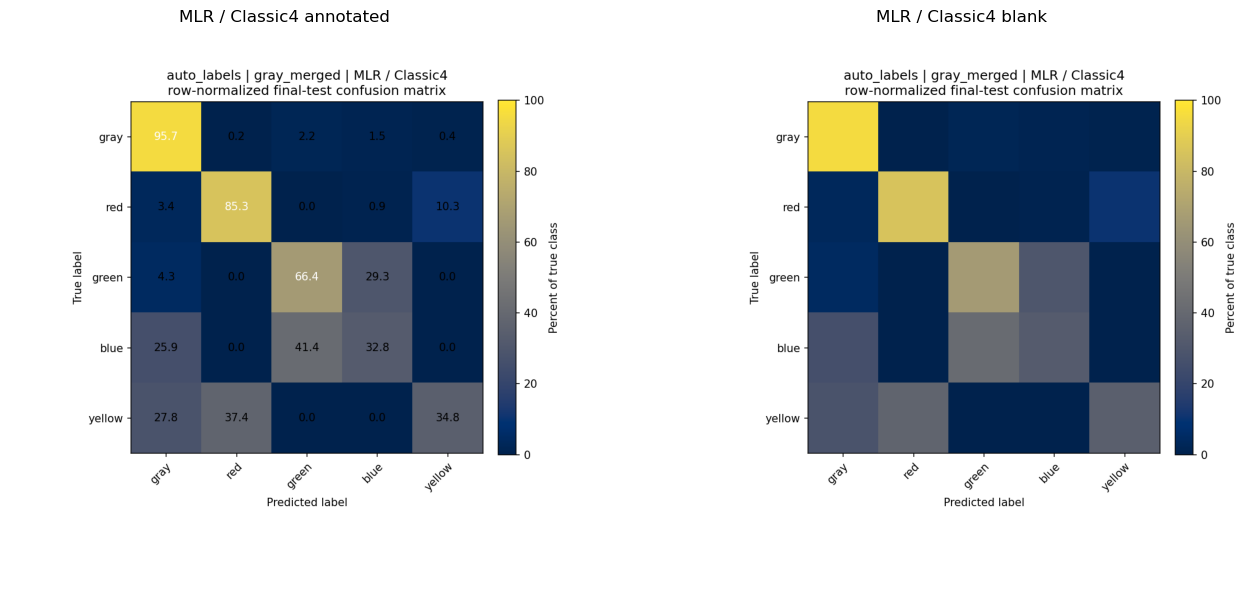


auto_labels confusion matrices — MLR / Classic4_plus_s
Final test accuracy: 97.62%


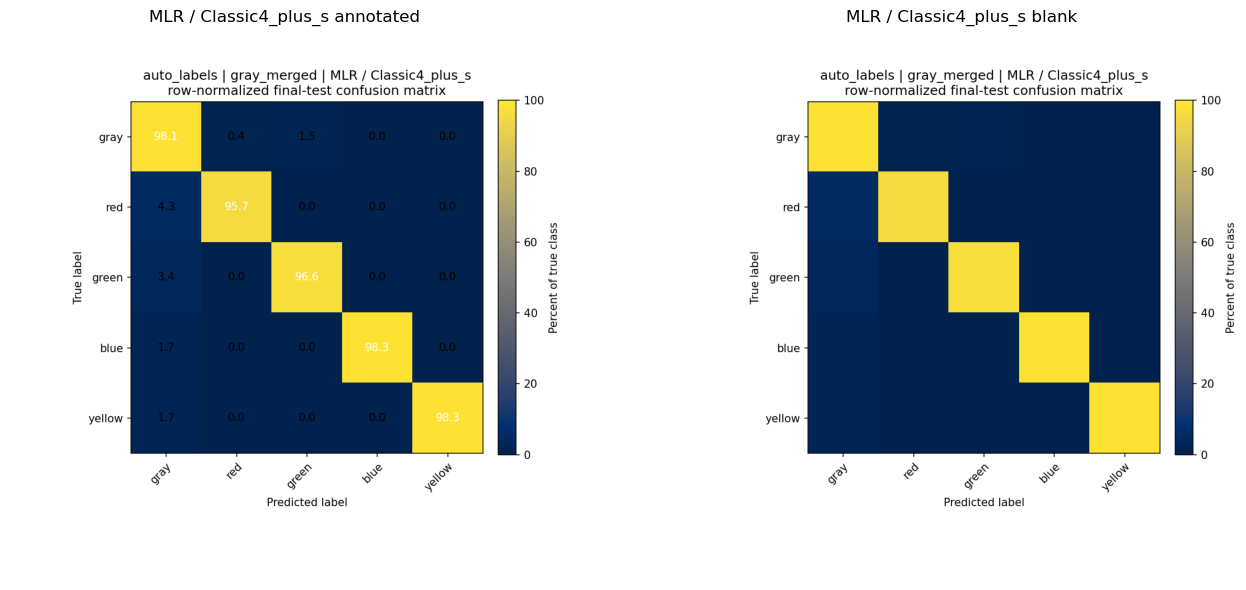


auto_labels confusion matrices — MLR / Neitz8
Final test accuracy: 99.14%


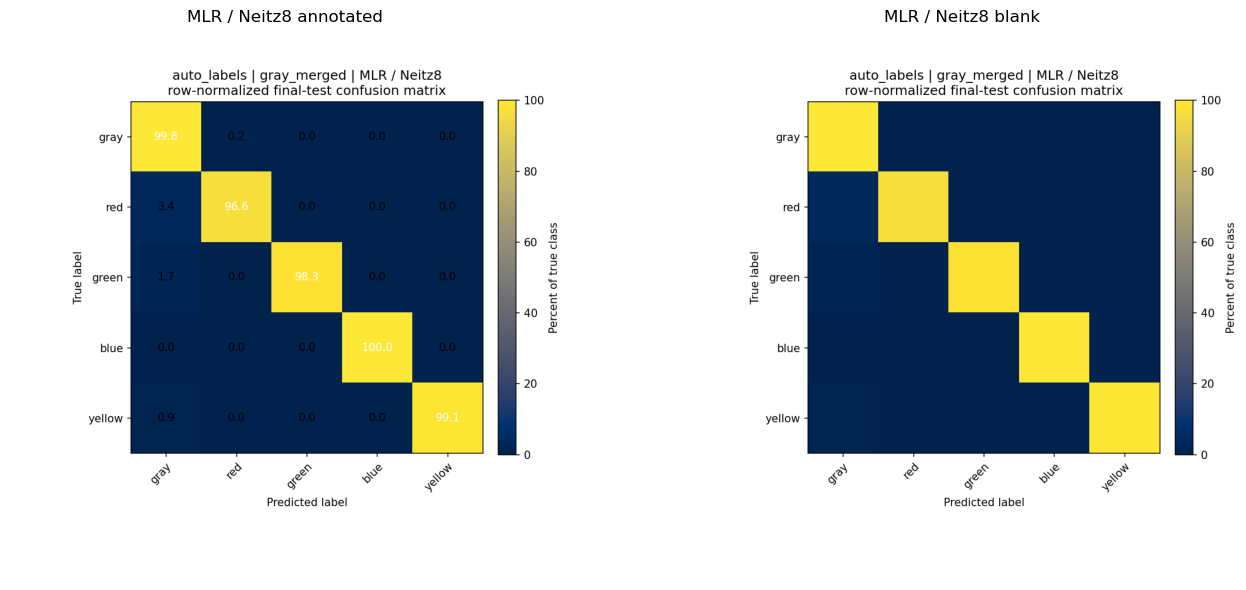


auto_labels confusion matrices — RF / Classic4
Final test accuracy: 62.38%


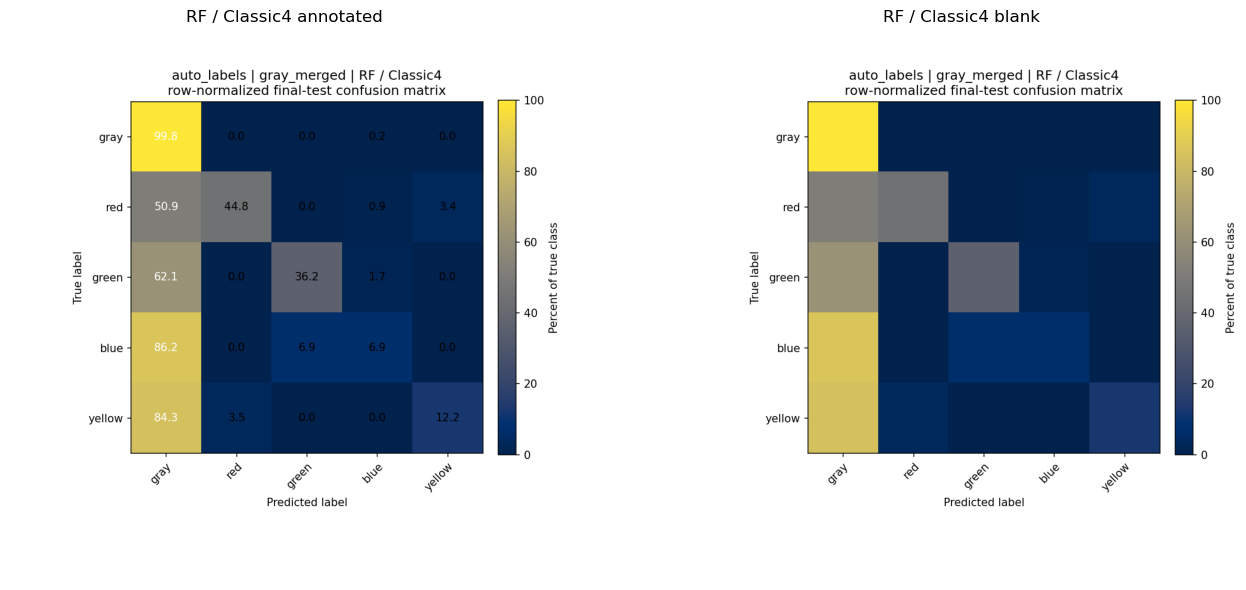


auto_labels confusion matrices — RF / Classic4_plus_s
Final test accuracy: 91.24%


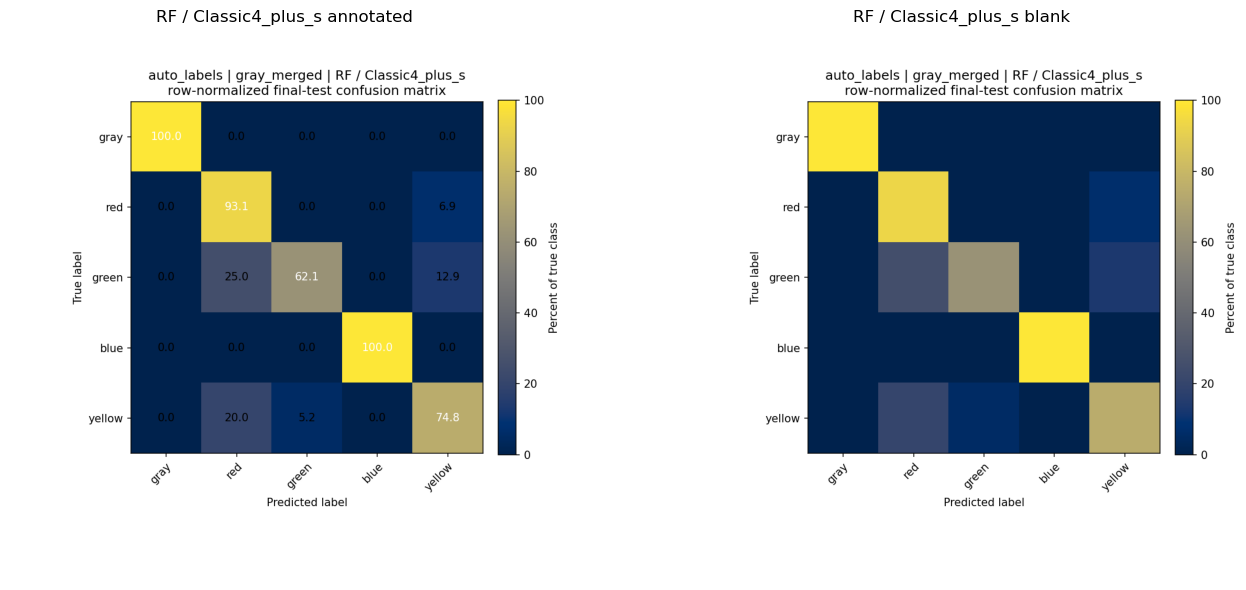


auto_labels confusion matrices — RF / Neitz8
Final test accuracy: 98.59%


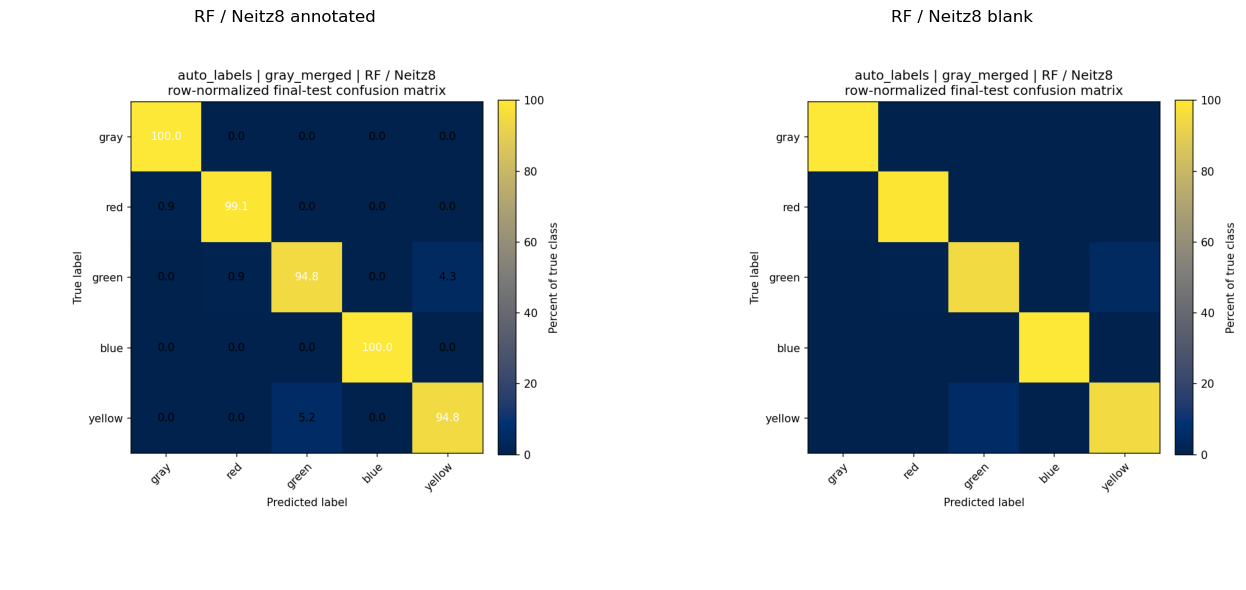


auto_labels confusion matrices — SVM / Classic4
Final test accuracy: 59.46%


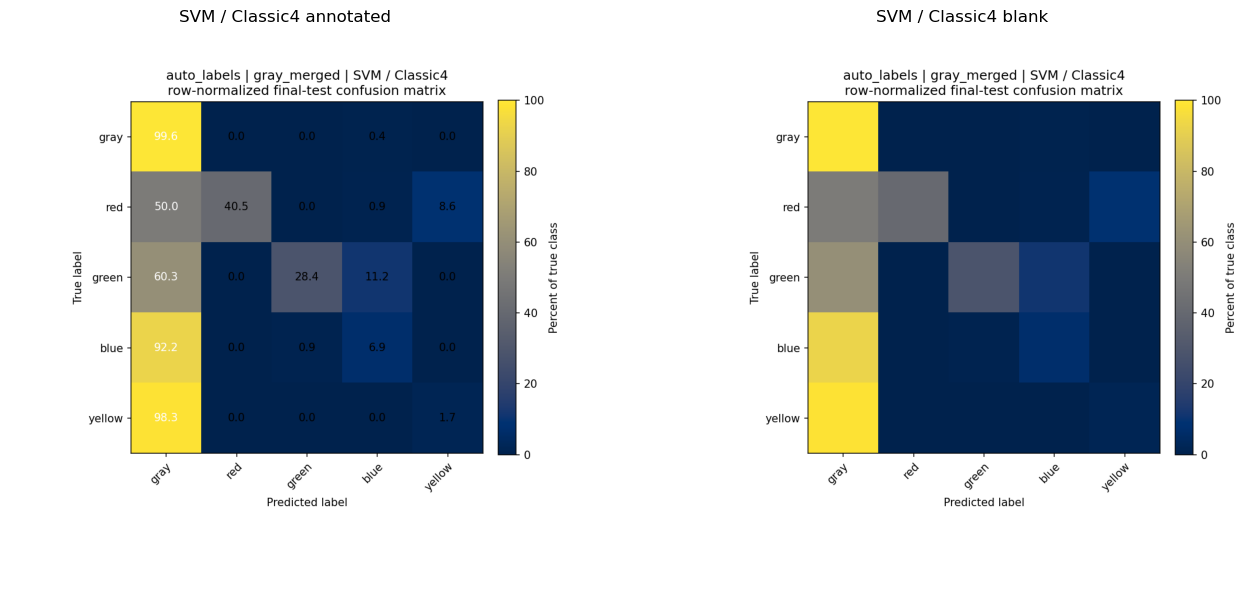


auto_labels confusion matrices — SVM / Classic4_plus_s
Final test accuracy: 83.46%


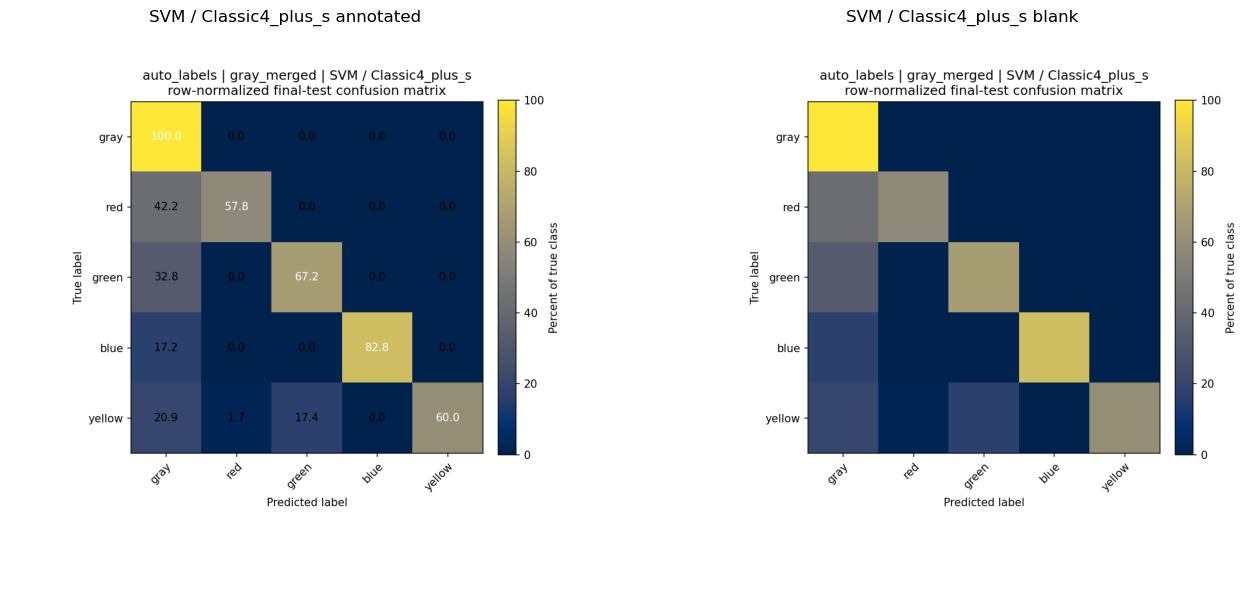


auto_labels confusion matrices — SVM / Neitz8
Final test accuracy: 85.30%


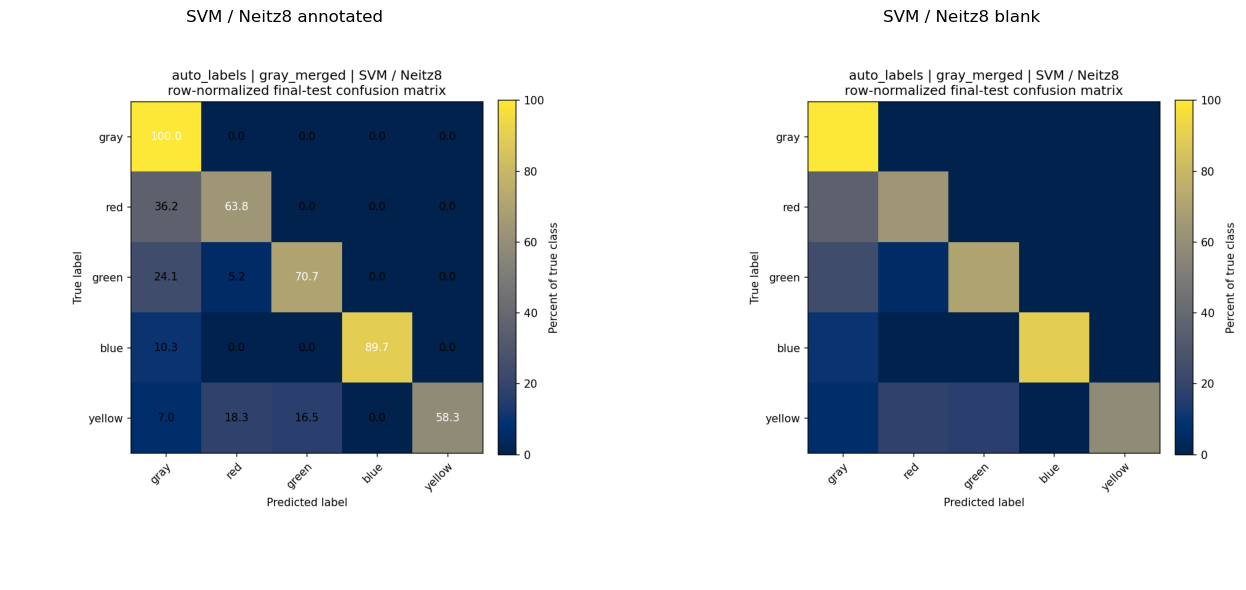

In [10]:
# Cell 10 — Build, display, and save confusion matrices for the active evaluation mode  # 03.26.2026 Support automated-label or human-review evaluation with merged or separate gray classes.
# Use the top-of-notebook settings to compute or reload the active confusion-matrix outputs, then rebuild the figures.  # 03.26.2026 Explain the purpose of this configurable evaluation cell.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # 03.26.2026 Use the notebook output directory if Cell 4 saved it with this name.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # 03.26.2026 Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # 03.26.2026 Fall back to a simpler output-directory variable name if needed.
    note_output_dir = Path(OUTPUT_DIR)  # 03.26.2026 Convert the fallback output directory into a Path object.
else:  # 03.26.2026 Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # 03.26.2026 Explain which earlier cell must be rerun.

summaries_dir = note_output_dir / "summaries"  # 03.26.2026 Build the summaries-folder path for notebook-level long tables.
summaries_dir.mkdir(parents=True, exist_ok=True)  # 03.26.2026 Make sure the summaries folder exists before any files are saved.
eval_output_dir = note_output_dir / EVAL_OUTPUT_FOLDER_NAME  # 03.26.2026 Build the figure-output folder path for the active evaluation mode.
eval_output_dir.mkdir(parents=True, exist_ok=True)  # 03.26.2026 Make sure the active evaluation-output folder exists before any files are saved.
summary_long_path = summaries_dir / NOTEBOOK_SUMMARY_FILE_NAME  # 03.26.2026 Build the notebook-level long-summary path for the active evaluation mode.
accuracy_summary_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_{EVAL_MODE_SUFFIX}_accuracy_summary.csv"  # 03.26.2026 Build the short accuracy-summary path for the active evaluation mode.

def evaluation_label_from_text(label_text):  # 03.26.2026 Convert one text label into the active evaluation label after applying the gray-choice setting.
    label_text = str(label_text).strip()  # 03.26.2026 Normalize the incoming label text before any evaluation mapping is applied.
    if COMBINE_GRAY_CLASSES and label_text in {"gray_d", "gray_l"}:  # 03.26.2026 Collapse both gray subclasses into one shared gray label when gray merging is enabled.
        return "gray"  # 03.26.2026 Return the merged gray label for either gray subclass.
    return label_text  # 03.26.2026 Leave every non-gray label unchanged for evaluation.

def decode_label_int_array(label_int_array):  # 03.26.2026 Decode saved integer class IDs into the notebook's original text labels.
    return [str(CLASS_ORDER[int(label_value)]) for label_value in np.asarray(label_int_array, dtype=np.int64)]  # 03.26.2026 Convert every saved integer class ID into its matching text label.

def build_eval_cm_long_df(y_true_labels, y_pred_labels, model_name, group_name, accuracy_value, summary_type, review_scope_name, n_human_reviewed_images):  # 03.26.2026 Build the long-format confusion-matrix table for the active evaluation labels.
    cm_counts = confusion_matrix(y_true_labels, y_pred_labels, labels=EVAL_CLASS_ORDER)  # 03.26.2026 Build the raw confusion-matrix counts using the active evaluation class order.
    row_totals = cm_counts.sum(axis=1).astype(np.int64)  # 03.26.2026 Count how many items belong to each true-label row in the active evaluation.
    rows = []  # 03.26.2026 Collect one long-format row per confusion-matrix cell.
    for true_idx, true_label in enumerate(EVAL_CLASS_ORDER):  # 03.26.2026 Walk through each true-label row in the active evaluation order.
        for pred_idx, pred_label in enumerate(EVAL_CLASS_ORDER):  # 03.26.2026 Walk through each predicted-label column in the active evaluation order.
            raw_count = int(cm_counts[true_idx, pred_idx])  # 03.26.2026 Read the raw count in this confusion-matrix cell.
            true_class_total = int(row_totals[true_idx])  # 03.26.2026 Read the total number of images in this true-label row.
            percent_value = (float(raw_count) / float(true_class_total) * 100.0) if true_class_total > 0 else 0.0  # 03.26.2026 Convert the raw count into a row-normalized percentage.
            rows.append({"model": str(model_name), "group": str(group_name), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "raw_count": raw_count, "true_class_total": true_class_total, "percent_of_true_class": percent_value, "final_test_accuracy": float(accuracy_value), "summary_type": str(summary_type), "review_scope_name": str(review_scope_name), "n_human_reviewed_images": int(n_human_reviewed_images), "n_test_images_total": int(len(y_true_labels))})  # 03.26.2026 Save one long-format row while keeping the familiar summary schema.
    return pd.DataFrame(rows)  # 03.26.2026 Return the completed long-format confusion-matrix table.

def build_percent_matrix_from_long(long_df, model_name, group_name):  # 03.26.2026 Convert saved long-format rows back into one row-normalized percentage matrix.
    sub_df = long_df.loc[(long_df["model"].astype(str) == str(model_name)) & (long_df["group"].astype(str) == str(group_name)), ["true_label", "pred_label", "percent_of_true_class"]].copy()  # 03.26.2026 Keep only the rows for this one model-group pair.
    if len(sub_df) == 0:  # 03.26.2026 Stop if the requested model-group rows are missing.
        raise RuntimeError("No long-format confusion-matrix rows were found for " + str(model_name) + " / " + str(group_name))  # 03.26.2026 Explain which model-group pair is missing.
    matrix_df = sub_df.pivot(index="true_label", columns="pred_label", values="percent_of_true_class").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # 03.26.2026 Rebuild the row-normalized percentage matrix in the active evaluation order.
    return matrix_df.to_numpy(dtype=np.float64)  # 03.26.2026 Return the rebuilt percentage matrix as a NumPy array.

def save_confusion_matrix_png(cm_pct, out_path, title_text, annotate_numbers):  # 03.26.2026 Save one row-normalized confusion matrix as a PNG using the requested colormap.
    fig, ax = plt.subplots(figsize=(7, 7))  # 03.26.2026 Create one square figure for the confusion matrix.
    image = ax.imshow(cm_pct, cmap="cividis", vmin=0.0, vmax=100.0)  # 03.26.2026 Draw the row-normalized percentages using the requested cividis colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each predicted-label column in the active evaluation order.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each true-label row in the active evaluation order.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # 03.26.2026 Show the predicted labels on the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # 03.26.2026 Show the true labels on the y axis.
    ax.set_xlabel("Predicted label")  # 03.26.2026 Label the x axis.
    ax.set_ylabel("True label")  # 03.26.2026 Label the y axis.
    ax.set_title(title_text)  # 03.26.2026 Add the descriptive figure title.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # 03.26.2026 Add the color scale bar.
    colorbar.set_label("Percent of true class")  # 03.26.2026 Label the colorbar.
    if annotate_numbers:  # 03.26.2026 Write the numeric percentage into each cell when requested.
        for row_idx in range(cm_pct.shape[0]):  # 03.26.2026 Loop over the true-label rows.
            for col_idx in range(cm_pct.shape[1]):  # 03.26.2026 Loop over the predicted-label columns.
                value = float(cm_pct[row_idx, col_idx])  # 03.26.2026 Read the current cell percentage.
                text_color = "white" if value >= 50.0 else "black"  # 03.26.2026 Choose a readable text color for the current background shade.
                ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=10)  # 03.26.2026 Write the rounded percentage value into the cell.
    fig.subplots_adjust(left=0.22, bottom=0.20, right=0.92, top=0.90)  # 03.26.2026 Reserve room so labels and the colorbar are not clipped.
    fig.savefig(out_path, dpi=150)  # 03.26.2026 Save the confusion-matrix figure to disk.
    plt.close(fig)  # 03.26.2026 Close the figure so notebook memory does not keep growing.

if LOAD_SAVED_RESULTS_ONLY:  # 03.26.2026 Reload the previously saved notebook-level summary instead of recomputing it.
    if not summary_long_path.exists():  # 03.26.2026 Stop if the saved notebook-level summary for the active mode is missing.
        raise FileNotFoundError("The saved long-summary file for the active mode was not found: " + str(summary_long_path))  # 03.26.2026 Explain which saved file is required for reload-only mode.
    summary_long_df = pd.read_csv(summary_long_path)  # 03.26.2026 Load the previously saved long-format confusion-matrix table for the active mode.
else:  # 03.26.2026 Compute or load the active long-format confusion-matrix table during a fresh notebook run.
    if USE_HUMAN_REVIEW:  # 03.26.2026 Build the active confusion matrices from scope-specific human-reviewed label overrides.
        if "REVIEW_SCOPE_DIR" not in globals() or "REVIEW_SCOPE_NAME" not in globals() or "REVIEW_SCOPE_SELECTED_RUN_KEYS" not in globals():  # 03.26.2026 Stop if no review scope has been built for the human-review workflow.
            raise RuntimeError("Run Cell 8 before building confusion matrices in human-review mode.")  # 03.26.2026 Explain which earlier step is required for human-review mode.
        if "SELECTED_RUN_DATA" not in globals() or len(SELECTED_RUN_DATA) == 0:  # 03.26.2026 Stop if the per-run loaded data are missing for the human-review workflow.
            raise RuntimeError("SELECTED_RUN_DATA is missing. Please rerun Cell 6 before running this cell in human-review mode.")  # 03.26.2026 Explain which earlier step must be rerun.
        scope_dir = Path(REVIEW_SCOPE_DIR)  # 03.26.2026 Convert the active review-scope directory into a Path object.
        scope_name = str(REVIEW_SCOPE_NAME)  # 03.26.2026 Read the active review-scope name as text.
        scope_labels_path = Path(REVIEW_SCOPE_HUMAN_LABELS_PATH) if "REVIEW_SCOPE_HUMAN_LABELS_PATH" in globals() else scope_dir / "scope_human_labels.csv"  # 03.26.2026 Build the path to the saved scope human-label table.
        scope_predictions_path = scope_dir / "scope_predictions_long.csv"  # 03.26.2026 Build the path to the saved scope predictions-long table.
        if not scope_labels_path.exists():  # 03.26.2026 Stop if the scope human-label file is missing.
            raise FileNotFoundError("scope_human_labels.csv was not found for the current review scope: " + str(scope_labels_path))  # 03.26.2026 Explain what is missing for the human-review workflow.
        scope_labels_df = pd.read_csv(scope_labels_path)  # 03.26.2026 Load the current scope human-label table from disk.
        scope_predictions_df = pd.read_csv(scope_predictions_path) if scope_predictions_path.exists() else pd.DataFrame(columns=["stim_ID", "test_pos", "run_key"])  # 03.26.2026 Load the current scope predictions-long table when it exists.
        if "stim_ID" not in scope_labels_df.columns and "stim_id" in scope_labels_df.columns:  # 03.26.2026 Rename lowercase stim_id when the saved scope-label file uses that schema.
            scope_labels_df = scope_labels_df.rename(columns={"stim_id": "stim_ID"})  # 03.26.2026 Rename the saved stim_id column to the shared stim_ID name.
        if len(scope_labels_df) == 0:  # 03.26.2026 Stop if the current scope does not contain any saved human labels yet.
            raise RuntimeError("The current review scope has no saved human labels yet, so human-review confusion matrices cannot be built.")  # 03.26.2026 Explain why the human-review workflow cannot continue.
        scope_labels_df["stim_ID"] = pd.to_numeric(scope_labels_df["stim_ID"], errors="coerce")  # 03.26.2026 Convert scope-label stim_ID values into numeric form.
        scope_labels_df = scope_labels_df.loc[~scope_labels_df["stim_ID"].isna()].copy()  # 03.26.2026 Keep only rows with a valid scope-label stim_ID.
        scope_labels_df["stim_ID"] = scope_labels_df["stim_ID"].astype(np.int64)  # 03.26.2026 Convert scope-label stim_ID values to integer type.
        scope_labels_df["human_label"] = scope_labels_df["human_label"].astype(str)  # 03.26.2026 Convert saved human-label text values into plain strings.
        scope_labels_df = scope_labels_df.sort_values(["stim_ID", "saved_at", "review_order"], kind="mergesort").drop_duplicates(subset=["stim_ID"], keep="last")  # 03.26.2026 Keep only the newest saved human label per stim_ID.
        if len(scope_predictions_df) > 0:  # 03.26.2026 Standardize the current scope predictions-long table when rows are present.
            if "stim_ID" not in scope_predictions_df.columns and "stim_id" in scope_predictions_df.columns:  # 03.26.2026 Rename lowercase stim_id when the predictions-long file uses that schema.
                scope_predictions_df = scope_predictions_df.rename(columns={"stim_id": "stim_ID"})  # 03.26.2026 Rename the saved stim_id column to the shared stim_ID name.
            scope_predictions_df["stim_ID"] = pd.to_numeric(scope_predictions_df["stim_ID"], errors="coerce")  # 03.26.2026 Convert scope-prediction stim_ID values into numeric form.
            scope_predictions_df["test_pos"] = pd.to_numeric(scope_predictions_df["test_pos"], errors="coerce")  # 03.26.2026 Convert scope-prediction test positions into numeric form.
            scope_predictions_df = scope_predictions_df.loc[~scope_predictions_df["stim_ID"].isna() & ~scope_predictions_df["test_pos"].isna()].copy()  # 03.26.2026 Keep only complete scope-prediction rows.
            scope_predictions_df["stim_ID"] = scope_predictions_df["stim_ID"].astype(np.int64)  # 03.26.2026 Convert scope-prediction stim_ID values to integer type.
            scope_predictions_df["test_pos"] = scope_predictions_df["test_pos"].astype(np.int64)  # 03.26.2026 Convert scope-prediction test_pos values to integer type.
        summary_parts = []  # 03.26.2026 Collect one human-review long-format confusion-matrix table per reviewed run.
        for run_key in [str(run_key) for run_key in REVIEW_SCOPE_SELECTED_RUN_KEYS]:  # 03.26.2026 Build one human-review result per run in the active review scope.
            run_record = SELECTED_RUN_DATA[run_key]  # 03.26.2026 Read the fully loaded data for this reviewed run.
            y_true_labels = decode_label_int_array(run_record["y_true_test_int"])  # 03.26.2026 Decode the saved true-label integers into the original text labels.
            y_pred_labels = decode_label_int_array(run_record["y_pred_test_int_original"])  # 03.26.2026 Decode the saved original prediction integers into the original text labels.
            run_scope_predictions_df = scope_predictions_df.loc[scope_predictions_df["run_key"].astype(str) == str(run_key), ["stim_ID", "test_pos"]].copy() if len(scope_predictions_df) > 0 else pd.DataFrame(columns=["stim_ID", "test_pos"])  # 03.26.2026 Keep only the active scope rows that belong to this reviewed run.
            run_human_overrides_df = run_scope_predictions_df.merge(scope_labels_df[["stim_ID", "human_label"]], on="stim_ID", how="inner") if len(run_scope_predictions_df) > 0 else pd.DataFrame(columns=["stim_ID", "test_pos", "human_label"])  # 03.26.2026 Keep only reviewed scope items that should override this run's predictions.
            run_human_overrides_df = run_human_overrides_df.sort_values(["test_pos", "stim_ID"], kind="mergesort").drop_duplicates(subset=["stim_ID"], keep="last") if len(run_human_overrides_df) > 0 else run_human_overrides_df  # 03.26.2026 Keep one newest override row per reviewed stim_ID for this run.
            for override_row in run_human_overrides_df.itertuples(index=False):  # 03.26.2026 Replace the model prediction only at each reviewed scope image.
                y_pred_labels[int(override_row.test_pos)] = str(override_row.human_label)  # 03.26.2026 Use the saved human-reviewed label at this final-test position.
            y_true_eval = [evaluation_label_from_text(label_text) for label_text in y_true_labels]  # 03.26.2026 Convert the true-label list into the active evaluation labels.
            y_pred_eval = [evaluation_label_from_text(label_text) for label_text in y_pred_labels]  # 03.26.2026 Convert the prediction list into the active evaluation labels.
            eval_accuracy = float(np.mean(np.asarray(y_true_eval) == np.asarray(y_pred_eval)))  # 03.26.2026 Recompute the full final-test accuracy after human-review overrides in the active evaluation space.
            model_name = str(run_record["run_row"]["model"])  # 03.26.2026 Read the model name for this reviewed run.
            group_name = str(run_record["run_row"]["group"])  # 03.26.2026 Read the group name for this reviewed run.
            summary_parts.append(build_eval_cm_long_df(y_true_eval, y_pred_eval, model_name, group_name, eval_accuracy, "human_review", scope_name, int(len(run_human_overrides_df))))  # 03.26.2026 Save this reviewed run's long-format confusion-matrix table.
        summary_long_df = pd.concat(summary_parts, ignore_index=True) if len(summary_parts) > 0 else pd.DataFrame()  # 03.26.2026 Stack all reviewed-run long-format confusion-matrix tables into one dataframe.
        summary_long_df.to_csv(summary_long_path, index=False)  # 03.26.2026 Save the notebook-level human-review long-summary table for this evaluation mode.
    elif COMBINE_GRAY_CLASSES:  # 03.26.2026 Recompute the notebook-level automated-label summary when gray merging is enabled.
        if "SELECTED_RUN_DATA" not in globals() or len(SELECTED_RUN_DATA) == 0:  # 03.26.2026 Stop if the per-run loaded data are missing for gray-merged automated evaluation.
            raise RuntimeError("SELECTED_RUN_DATA is missing. Please rerun Cell 6 before running this cell with gray merging enabled.")  # 03.26.2026 Explain which earlier step must be rerun.
        summary_parts = []  # 03.26.2026 Collect one automated-label long-format confusion-matrix table per selected run.
        for run_key in [str(run_key) for run_key in SELECTED_RUN_DATA.keys()]:  # 03.26.2026 Build one automated-label result per currently loaded selected run.
            run_record = SELECTED_RUN_DATA[run_key]  # 03.26.2026 Read the fully loaded data for this selected run.
            y_true_labels = decode_label_int_array(run_record["y_true_test_int"])  # 03.26.2026 Decode the saved true-label integers into the original text labels.
            y_pred_labels = decode_label_int_array(run_record["y_pred_test_int_original"])  # 03.26.2026 Decode the saved prediction integers into the original text labels.
            y_true_eval = [evaluation_label_from_text(label_text) for label_text in y_true_labels]  # 03.26.2026 Convert the true-label list into the active gray-merged evaluation labels.
            y_pred_eval = [evaluation_label_from_text(label_text) for label_text in y_pred_labels]  # 03.26.2026 Convert the prediction list into the active gray-merged evaluation labels.
            eval_accuracy = float(np.mean(np.asarray(y_true_eval) == np.asarray(y_pred_eval)))  # 03.26.2026 Recompute the full final-test accuracy under the active gray-merged evaluation rule.
            model_name = str(run_record["run_row"]["model"])  # 03.26.2026 Read the model name for this selected run.
            group_name = str(run_record["run_row"]["group"])  # 03.26.2026 Read the group name for this selected run.
            summary_parts.append(build_eval_cm_long_df(y_true_eval, y_pred_eval, model_name, group_name, eval_accuracy, "auto_labels", "", 0))  # 03.26.2026 Save this selected run's gray-merged long-format confusion-matrix table.
        summary_long_df = pd.concat(summary_parts, ignore_index=True) if len(summary_parts) > 0 else pd.DataFrame()  # 03.26.2026 Stack all gray-merged automated-label long-format confusion-matrix tables into one dataframe.
        summary_long_df.to_csv(summary_long_path, index=False)  # 03.26.2026 Save the notebook-level gray-merged automated-label long-summary table.
    else:  # 03.26.2026 Reuse the original notebook-level automated-label summary when gray subclasses stay separate.
        if not summary_long_path.exists():  # 03.26.2026 Stop if the original notebook-level summary was not created by Cell 6 yet.
            raise FileNotFoundError("simple_summary_original_long.csv was not found. Please run Cell 6 before running this cell with separate gray classes.")  # 03.26.2026 Explain which earlier cell creates the needed summary file.
        summary_long_df = pd.read_csv(summary_long_path)  # 03.26.2026 Load the original notebook-level automated-label long-summary table from disk.

if len(summary_long_df) == 0:  # 03.26.2026 Stop if the active evaluation produced no long-format confusion-matrix rows.
    raise RuntimeError("No long-format confusion-matrix rows are available for the active evaluation mode.")  # 03.26.2026 Explain why the cell cannot continue.

summary_long_df["model"] = summary_long_df["model"].astype(str)  # 03.26.2026 Convert model names to text for stable matching and file naming.
summary_long_df["group"] = summary_long_df["group"].astype(str)  # 03.26.2026 Convert group names to text for stable matching and file naming.
summary_long_df["true_label"] = summary_long_df["true_label"].astype(str)  # 03.26.2026 Convert true-label values to text for stable matching.
summary_long_df["pred_label"] = summary_long_df["pred_label"].astype(str)  # 03.26.2026 Convert predicted-label values to text for stable matching.
summary_long_df["percent_of_true_class"] = pd.to_numeric(summary_long_df["percent_of_true_class"], errors="coerce")  # 03.26.2026 Convert row-normalized percentages into numeric values.
summary_long_df["final_test_accuracy"] = pd.to_numeric(summary_long_df["final_test_accuracy"], errors="coerce")  # 03.26.2026 Convert final-test accuracies into numeric values.
summary_long_df["n_human_reviewed_images"] = pd.to_numeric(summary_long_df["n_human_reviewed_images"], errors="coerce").fillna(0).astype(int) if "n_human_reviewed_images" in summary_long_df.columns else 0  # 03.26.2026 Convert reviewed-image counts into integers when that column exists.
summary_long_df["review_scope_name"] = summary_long_df["review_scope_name"].astype(str) if "review_scope_name" in summary_long_df.columns else ""  # 03.26.2026 Normalize review-scope names into text when that column exists.

accuracy_summary_df = summary_long_df[["model", "group", "final_test_accuracy", "review_scope_name", "n_human_reviewed_images"]].drop_duplicates().copy()  # 03.26.2026 Build one short accuracy-summary row per model-group pair in the active evaluation mode.
accuracy_summary_df["final_test_accuracy_percent"] = accuracy_summary_df["final_test_accuracy"].astype(float) * 100.0  # 03.26.2026 Convert the saved final-test accuracy fraction into a percentage.
accuracy_summary_df = accuracy_summary_df.sort_values(["model", "group", "review_scope_name"], kind="mergesort").reset_index(drop=True)  # 03.26.2026 Put the accuracy-summary rows into stable readable order.
accuracy_summary_df.to_csv(accuracy_summary_path, index=False)  # 03.26.2026 Save the short accuracy-summary CSV for the active evaluation mode.

inline_display_records = []  # 03.26.2026 Collect the saved figure paths and summary info for inline display.
for _, accuracy_row in accuracy_summary_df.iterrows():  # 03.26.2026 Save one annotated and one blank confusion-matrix figure per active model-group pair.
    model_name = str(accuracy_row["model"])  # 03.26.2026 Read the model name for this figure.
    group_name = str(accuracy_row["group"])  # 03.26.2026 Read the group name for this figure.
    eval_accuracy_percent = float(accuracy_row["final_test_accuracy_percent"])  # 03.26.2026 Read the saved final-test accuracy percentage for this figure.
    review_scope_name = str(accuracy_row["review_scope_name"])  # 03.26.2026 Read the saved review-scope name for this figure when one exists.
    n_human_reviewed_images = int(accuracy_row["n_human_reviewed_images"])  # 03.26.2026 Read how many reviewed images contributed to this figure.
    cm_pct = build_percent_matrix_from_long(summary_long_df, model_name, group_name)  # 03.26.2026 Rebuild the row-normalized percentage matrix for this model-group pair.
    safe_model_name = sanitize_name(model_name)  # 03.26.2026 Convert the model name into a folder-safe name.
    safe_group_name = sanitize_name(group_name)  # 03.26.2026 Convert the group name into a folder-safe name.
    annotated_png_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_annotated.png"  # 03.26.2026 Build the annotated confusion-matrix PNG path for this figure.
    blank_png_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_blank.png"  # 03.26.2026 Build the blank confusion-matrix PNG path for this figure.
    title_text = f"{LABEL_SOURCE_SUFFIX} | {EVAL_MODE_SUFFIX} | {model_name} / {group_name}\nrow-normalized final-test confusion matrix"  # 03.26.2026 Build the descriptive figure title for this model-group pair.
    save_confusion_matrix_png(cm_pct, annotated_png_path, title_text, True)  # 03.26.2026 Save the annotated confusion-matrix figure to disk.
    save_confusion_matrix_png(cm_pct, blank_png_path, title_text, False)  # 03.26.2026 Save the blank confusion-matrix figure to disk.
    inline_display_records.append({"model": model_name, "group": group_name, "final_test_accuracy_percent": eval_accuracy_percent, "review_scope_name": review_scope_name, "n_human_reviewed_images": n_human_reviewed_images, "annotated_png_path": annotated_png_path, "blank_png_path": blank_png_path})  # 03.26.2026 Save the inline-display information for this figure.

print("Active evaluation output folder:", eval_output_dir.resolve())  # 03.26.2026 Show where the active confusion-matrix figures were saved.
print("Active notebook-level long summary:", summary_long_path)  # 03.26.2026 Show which notebook-level long-summary file was used for this evaluation mode.
print("Active accuracy summary:", accuracy_summary_path)  # 03.26.2026 Show where the short accuracy-summary CSV was saved.
print()  # 03.26.2026 Add a blank line before the summary table.
display(accuracy_summary_df)  # 03.26.2026 Display the short accuracy-summary table inline.

for display_record in inline_display_records:  # 03.26.2026 Show each saved confusion matrix inline for quick notebook inspection.
    print()  # 03.26.2026 Add a blank line before each model-group figure pair.
    print(f"{LABEL_SOURCE_SUFFIX} confusion matrices — {display_record['model']} / {display_record['group']}")  # 03.26.2026 Label this model-group figure section.
    print(f"Final test accuracy: {display_record['final_test_accuracy_percent']:.2f}%")  # 03.26.2026 Show the active final-test accuracy percentage for this model-group pair.
    if USE_HUMAN_REVIEW:  # 03.26.2026 Show the saved human-review details only when the active label source is human review.
        print(f"Review scope: {display_record['review_scope_name']}")  # 03.26.2026 Show which saved review scope supplied the human-reviewed labels.
        print(f"Human-reviewed images used: {display_record['n_human_reviewed_images']}")  # 03.26.2026 Show how many reviewed images contributed to this model-group result.
    annotated_img = plt.imread(str(display_record["annotated_png_path"]))  # 03.26.2026 Read the saved annotated PNG back from disk.
    blank_img = plt.imread(str(display_record["blank_png_path"]))  # 03.26.2026 Read the saved blank PNG back from disk.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 03.26.2026 Create one two-panel figure for the annotated and blank PNGs.
    axes[0].imshow(annotated_img)  # 03.26.2026 Draw the annotated confusion-matrix PNG.
    axes[0].set_title(f"{display_record['model']} / {display_record['group']} annotated")  # 03.26.2026 Add the annotated-panel title.
    axes[0].axis("off")  # 03.26.2026 Hide the axes around the annotated PNG.
    axes[1].imshow(blank_img)  # 03.26.2026 Draw the blank confusion-matrix PNG.
    axes[1].set_title(f"{display_record['model']} / {display_record['group']} blank")  # 03.26.2026 Add the blank-panel title.
    axes[1].axis("off")  # 03.26.2026 Hide the axes around the blank PNG.
    plt.tight_layout()  # 03.26.2026 Adjust the layout so titles and images fit cleanly.
    plt.show()  # 03.26.2026 Display the two-panel figure inline in the notebook.


In [11]:

# Cell 11 — Refresh and inspect the one simple summary CSV
# Very short description: Rebuild the one master summary CSV and show a short accuracy-only view for quick inspection.

if "NOTEBOOK_OUTPUT_DIR" not in globals():  # Stop if the notebook output folder has not been chosen yet.
    raise RuntimeError("Run Cell 4 before rebuilding the master summary CSV.")  # Explain the required step.

MASTER_SIMPLE_SUMMARY_DF, MASTER_SIMPLE_SUMMARY_PATH = refresh_simple_summary_master(NOTEBOOK_OUTPUT_DIR)  # Rebuild the one master summary CSV from the original and any hybrid long tables.
ACCURACY_VIEW_DF = MASTER_SIMPLE_SUMMARY_DF[["model", "group", "summary_type", "review_scope_name", "final_test_accuracy"]].drop_duplicates().sort_values(["summary_type", "model", "group", "review_scope_name"], kind="mergesort").reset_index(drop=True)  # Build a short accuracy-only view of the master table.
ACCURACY_VIEW_DF["final_test_accuracy_percent"] = ACCURACY_VIEW_DF["final_test_accuracy"].astype(float) * 100.0  # Convert the accuracy fraction into a percent for easier reading.

print("Master summary CSV:", MASTER_SIMPLE_SUMMARY_PATH)  # Show where the one master summary CSV was saved.
print("Rows in master summary:", len(MASTER_SIMPLE_SUMMARY_DF))  # Show how many long-format rows are in the master summary.
display(ACCURACY_VIEW_DF)  # Display the short accuracy-only view for quick inspection.


Master summary CSV: MLR_SVM_RF_autoLabels_comboGray_20260330/summaries/simple_summary_master.csv
Rows in master summary: 549


,model,group,summary_type,review_scope_name,final_test_accuracy,final_test_accuracy_percent
0,MLR,Classic4,auto_labels,NaN,0.752432,75.243243
1,MLR,Classic4_plus_s,auto_labels,NaN,0.976216,97.621622
2,MLR,Neitz8,auto_labels,NaN,0.991351,99.135135
3,RF,Classic4,auto_labels,NaN,0.623784,62.378378
4,RF,Classic4_plus_s,auto_labels,NaN,0.912432,91.243243
5,RF,Neitz8,auto_labels,NaN,0.985946,98.594595
6,SVM,Classic4,auto_labels,NaN,0.594595,59.459459
7,SVM,Classic4_plus_s,auto_labels,NaN,0.834595,83.459459
8,SVM,Neitz8,auto_labels,NaN,0.852973,85.297297
9,MLR,Classic4,original,NaN,0.611892,61.189189



auto_labels difference matrix — MLR — Classic4 minus Classic4_plus_s
Lower accuracy: 75.24%   Higher accuracy: 97.62%


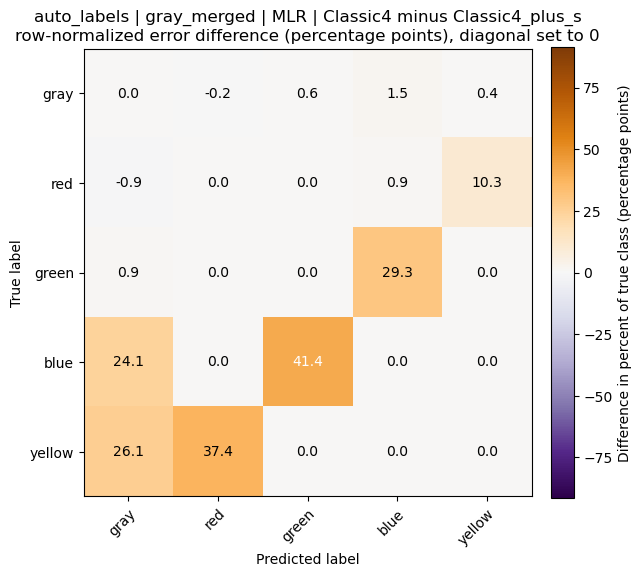


auto_labels difference matrix — MLR — Classic4 minus Neitz8
Lower accuracy: 75.24%   Higher accuracy: 99.14%


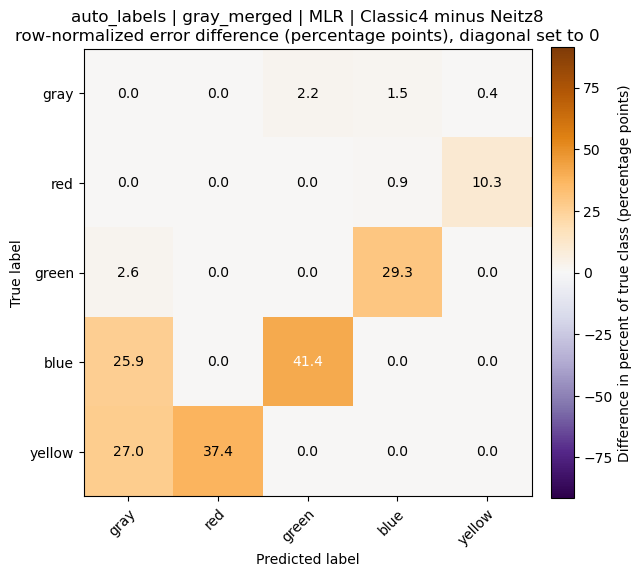


auto_labels difference matrix — MLR — Classic4_plus_s minus Neitz8
Lower accuracy: 97.62%   Higher accuracy: 99.14%


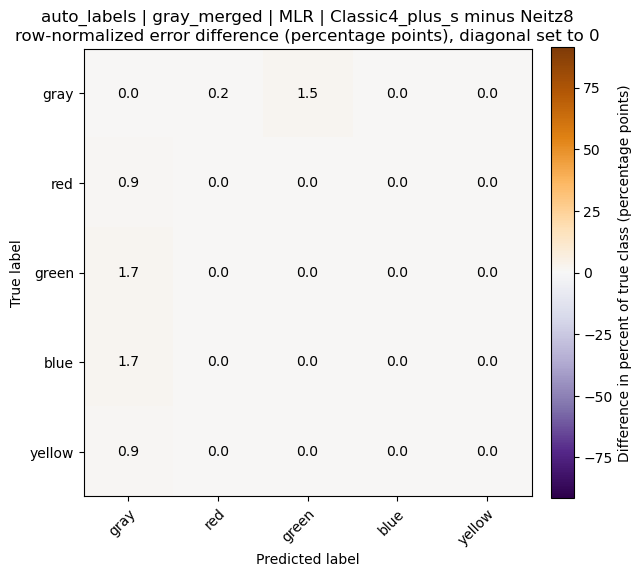


auto_labels difference matrix — RF — Classic4 minus Classic4_plus_s
Lower accuracy: 62.38%   Higher accuracy: 91.24%


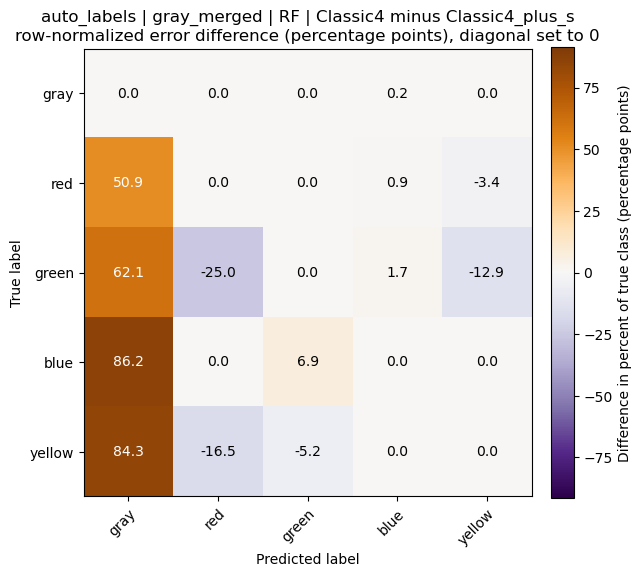


auto_labels difference matrix — RF — Classic4 minus Neitz8
Lower accuracy: 62.38%   Higher accuracy: 98.59%


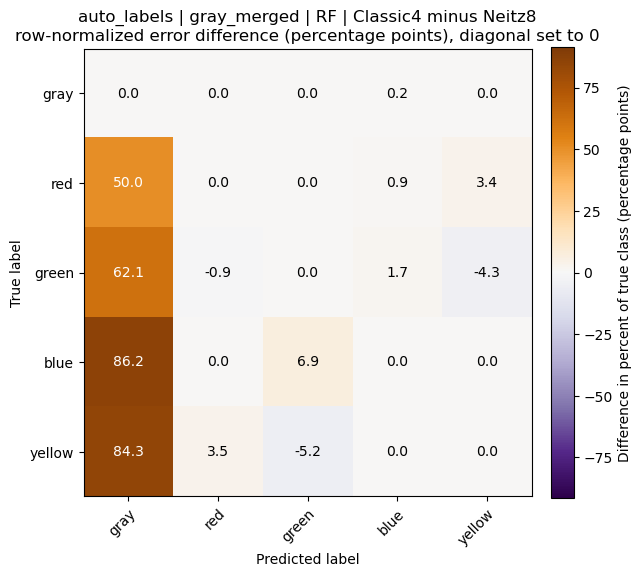


auto_labels difference matrix — RF — Classic4_plus_s minus Neitz8
Lower accuracy: 91.24%   Higher accuracy: 98.59%


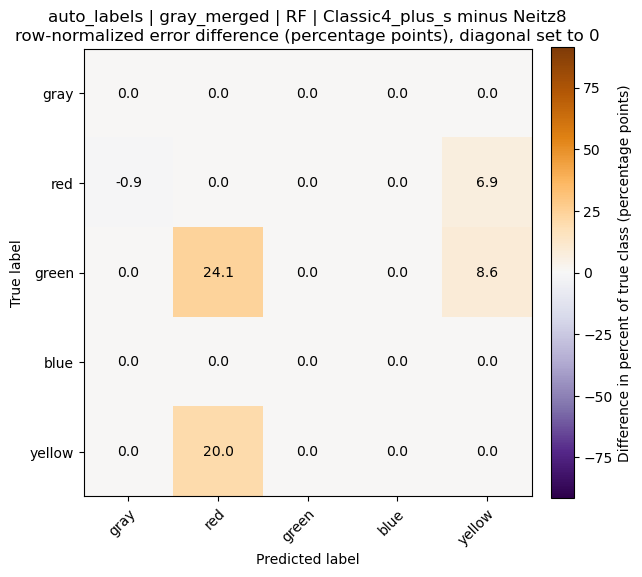


auto_labels difference matrix — SVM — Classic4 minus Classic4_plus_s
Lower accuracy: 59.46%   Higher accuracy: 83.46%


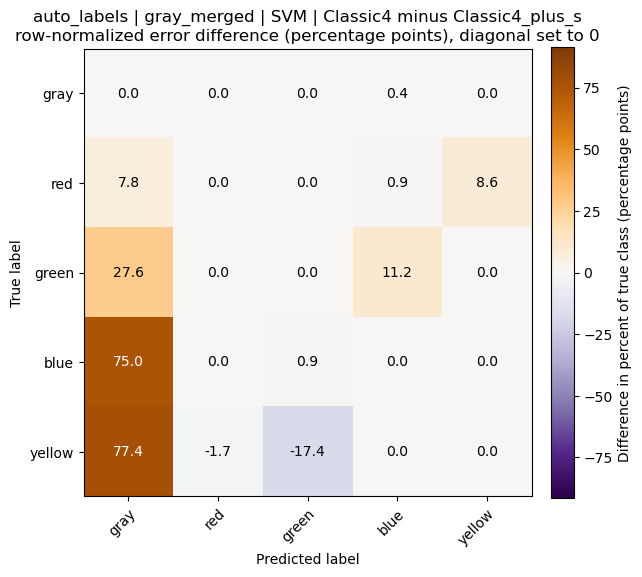


auto_labels difference matrix — SVM — Classic4 minus Neitz8
Lower accuracy: 59.46%   Higher accuracy: 85.30%


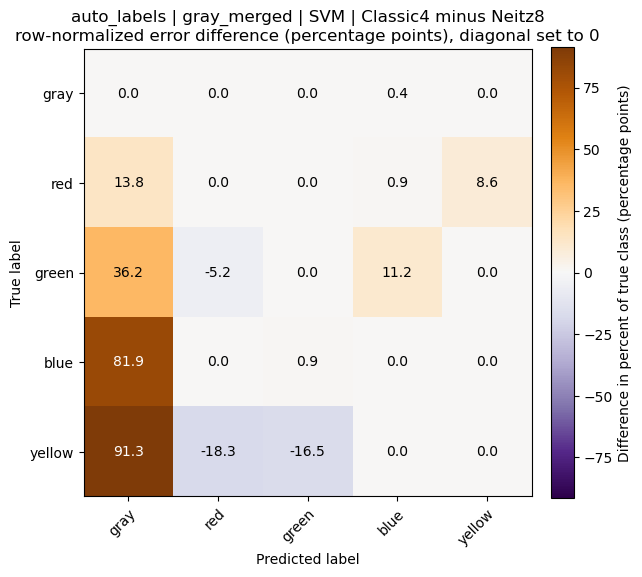


auto_labels difference matrix — SVM — Classic4_plus_s minus Neitz8
Lower accuracy: 83.46%   Higher accuracy: 85.30%


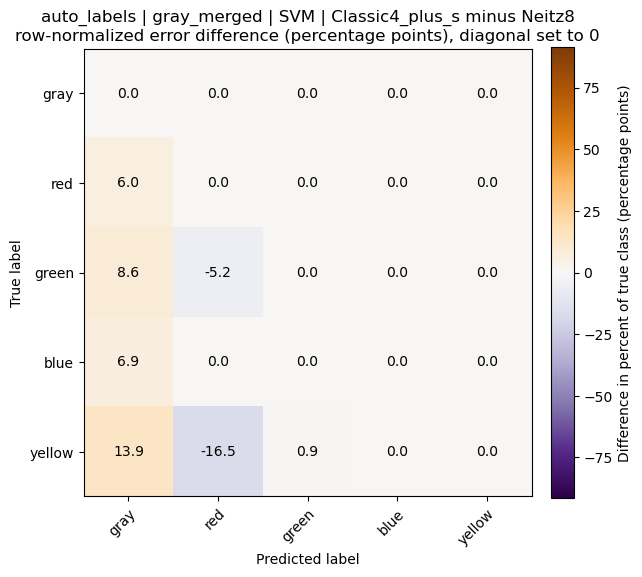


Difference matrices saved in: /data/retina-neitz/notebooks/MLR_SVM_RF_autoLabels_comboGray_20260330/gray_merged_outputs/difference_matrices
Global symmetric color limit used for all difference matrices: ±91.4
Long numeric difference CSV saved to: MLR_SVM_RF_autoLabels_comboGray_20260330/gray_merged_outputs/difference_matrices/difference_matrices_long_auto_labels_gray_merged.csv
Difference-matrix summary CSV saved to: MLR_SVM_RF_autoLabels_comboGray_20260330/gray_merged_outputs/difference_matrices/difference_matrices_summary_auto_labels_gray_merged.csv


,source_type,model,group_low_accuracy,group_high_accuracy,accuracy_low_percent,accuracy_high_percent,annotated_png_path,blank_png_path
0,auto_labels,MLR,Classic4,Classic4_plus_s,75.243243,97.621622,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
1,auto_labels,MLR,Classic4,Neitz8,75.243243,99.135135,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
2,auto_labels,MLR,Classic4_plus_s,Neitz8,97.621622,99.135135,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
3,auto_labels,RF,Classic4,Classic4_plus_s,62.378378,91.243243,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
4,auto_labels,RF,Classic4,Neitz8,62.378378,98.594595,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
5,auto_labels,RF,Classic4_plus_s,Neitz8,91.243243,98.594595,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
6,auto_labels,SVM,Classic4,Classic4_plus_s,59.459459,83.459459,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
7,auto_labels,SVM,Classic4,Neitz8,59.459459,85.297297,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...
8,auto_labels,SVM,Classic4_plus_s,Neitz8,83.459459,85.297297,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...,MLR_SVM_RF_autoLabels_comboGray_20260330/gray_...


In [12]:
# Cell 12 — Build, display, and save pairwise difference matrices for the active evaluation mode  # 03.26.2026 Support automated-label or human-review difference matrices with merged or separate gray classes.
# Use the active notebook-level long summary to rebuild pairwise difference figures with the requested reversed PuOr colormap.  # 03.26.2026 Explain the purpose of this configurable difference-matrix cell.

from matplotlib import colors as mcolors  # 03.26.2026 Import the normalization helper used to center the color scale at zero.

if "NOTEBOOK_OUTPUT_DIR" in globals():  # 03.26.2026 Use the notebook output directory if that variable exists.
    note_output_dir = Path(NOTEBOOK_OUTPUT_DIR)  # 03.26.2026 Convert the saved output directory into a Path object.
elif "OUTPUT_DIR" in globals():  # 03.26.2026 Fall back to the simpler output-directory variable name if needed.
    note_output_dir = Path(OUTPUT_DIR)  # 03.26.2026 Convert the fallback output directory into a Path object.
else:  # 03.26.2026 Stop if no output directory variable is available.
    raise RuntimeError("The notebook output directory was not found. Please rerun Cell 4 before running this cell.")  # 03.26.2026 Explain which earlier cell must be rerun.

if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # 03.26.2026 Stop if the selected-run table is missing for the active comparison set.
    raise RuntimeError("SELECTED_RUNS_DF is missing. Run Cell 6 before building the active difference matrices.")  # 03.26.2026 Explain which earlier step is required.

summary_long_path = note_output_dir / "summaries" / NOTEBOOK_SUMMARY_FILE_NAME  # 03.26.2026 Build the notebook-level long-summary path for the active evaluation mode.
if not summary_long_path.exists():  # 03.26.2026 Stop if the active notebook-level long summary is missing.
    raise FileNotFoundError("The notebook-level long-summary file for the active evaluation mode was not found: " + str(summary_long_path))  # 03.26.2026 Explain which saved file is required.
summary_long_df = pd.read_csv(summary_long_path)  # 03.26.2026 Load the active notebook-level long-format confusion-matrix table from disk.

summary_long_df["model"] = summary_long_df["model"].astype(str)  # 03.26.2026 Convert model names to text for stable matching.
summary_long_df["group"] = summary_long_df["group"].astype(str)  # 03.26.2026 Convert group names to text for stable matching.
summary_long_df["true_label"] = summary_long_df["true_label"].astype(str)  # 03.26.2026 Convert true-label values to text for stable matching.
summary_long_df["pred_label"] = summary_long_df["pred_label"].astype(str)  # 03.26.2026 Convert predicted-label values to text for stable matching.
summary_long_df["percent_of_true_class"] = pd.to_numeric(summary_long_df["percent_of_true_class"], errors="coerce")  # 03.26.2026 Convert row-normalized percentages into numeric values.
summary_long_df["final_test_accuracy"] = pd.to_numeric(summary_long_df["final_test_accuracy"], errors="coerce")  # 03.26.2026 Convert final-test accuracies into numeric values.

selected_model_group_df = SELECTED_RUNS_DF[["model", "group"]].copy()  # 03.26.2026 Keep only the selected model-group pairs for comparison matching.
selected_model_group_df["model"] = selected_model_group_df["model"].astype(str)  # 03.26.2026 Convert selected model names to text.
selected_model_group_df["group"] = selected_model_group_df["group"].astype(str)  # 03.26.2026 Convert selected group names to text.
selected_model_group_pairs = set(selected_model_group_df.drop_duplicates().itertuples(index=False, name=None))  # 03.26.2026 Build the set of selected model-group pairs.
available_pairs = set(summary_long_df[["model", "group"]].drop_duplicates().itertuples(index=False, name=None))  # 03.26.2026 Build the set of model-group pairs available in the active long summary.
missing_pairs = sorted(selected_model_group_pairs - available_pairs)  # 03.26.2026 Find any selected model-group pairs missing from the active long summary.
if len(missing_pairs) > 0:  # 03.26.2026 Stop if any selected runs are missing from the active long summary.
    raise RuntimeError("Active long-format confusion-matrix rows are missing for: " + ", ".join([f"{model_name} / {group_name}" for model_name, group_name in missing_pairs]))  # 03.26.2026 Explain which selected model-group pairs are unavailable.

difference_output_dir = note_output_dir / EVAL_OUTPUT_FOLDER_NAME / "difference_matrices"  # 03.26.2026 Build the difference-matrix output folder for the active evaluation mode.
difference_output_dir.mkdir(parents=True, exist_ok=True)  # 03.26.2026 Make sure the active difference-matrix output folder exists before files are saved.
difference_long_csv_path = difference_output_dir / f"difference_matrices_long_{LABEL_SOURCE_SUFFIX}_{EVAL_MODE_SUFFIX}.csv"  # 03.26.2026 Build the long numeric difference-table CSV path for the active evaluation mode.
difference_summary_csv_path = difference_output_dir / f"difference_matrices_summary_{LABEL_SOURCE_SUFFIX}_{EVAL_MODE_SUFFIX}.csv"  # 03.26.2026 Build the short difference-summary CSV path for the active evaluation mode.

def build_percent_matrix_from_long(long_df, model_name, group_name):  # 03.26.2026 Build one row-normalized percentage matrix from the active long-format confusion-matrix table.
    sub_df = long_df.loc[(long_df["model"].astype(str) == str(model_name)) & (long_df["group"].astype(str) == str(group_name)), ["true_label", "pred_label", "percent_of_true_class"]].copy()  # 03.26.2026 Keep only the rows for this one model-group pair.
    if len(sub_df) == 0:  # 03.26.2026 Stop if the requested model-group rows are missing.
        raise RuntimeError("No long-format confusion-matrix rows were found for " + str(model_name) + " / " + str(group_name))  # 03.26.2026 Explain which model-group pair is missing.
    matrix_df = sub_df.pivot(index="true_label", columns="pred_label", values="percent_of_true_class").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # 03.26.2026 Rebuild the row-normalized percentage matrix in the active evaluation order.
    return matrix_df.to_numpy(dtype=np.float64)  # 03.26.2026 Return the rebuilt percentage matrix as a NumPy array.

def save_difference_matrix_png(diff_matrix, out_path, title_text, annotate_numbers, color_limit):  # 03.26.2026 Save one difference matrix as a PNG using the requested reversed PuOr colormap.
    fig, ax = plt.subplots(figsize=(7, 7))  # 03.26.2026 Create one square figure for the difference matrix.
    norm = mcolors.TwoSlopeNorm(vmin=-float(color_limit), vcenter=0.0, vmax=float(color_limit))  # 03.26.2026 Center the color scale at zero and use the shared symmetric min and max.
    image = ax.imshow(diff_matrix, cmap="PuOr_r", norm=norm)  # 03.26.2026 Draw the difference matrix using the requested reversed PuOr colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each predicted-label column in the active evaluation order.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each true-label row in the active evaluation order.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # 03.26.2026 Show the predicted labels on the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # 03.26.2026 Show the true labels on the y axis.
    ax.set_xlabel("Predicted label")  # 03.26.2026 Label the x axis.
    ax.set_ylabel("True label")  # 03.26.2026 Label the y axis.
    ax.set_title(title_text)  # 03.26.2026 Add the descriptive figure title.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # 03.26.2026 Add the color scale bar to the figure.
    colorbar.set_label("Difference in percent of true class (percentage points)")  # 03.26.2026 Label the colorbar with the meaning of the values.
    if annotate_numbers:  # 03.26.2026 Write the numeric difference into each matrix cell when requested.
        for row_idx in range(diff_matrix.shape[0]):  # 03.26.2026 Loop over the true-label rows.
            for col_idx in range(diff_matrix.shape[1]):  # 03.26.2026 Loop over the predicted-label columns.
                value = float(diff_matrix[row_idx, col_idx])  # 03.26.2026 Read the current difference value.
                text_color = "white" if abs(value) >= float(color_limit) * 0.45 else "black"  # 03.26.2026 Choose a readable text color for the current background shade.
                ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=10)  # 03.26.2026 Write the rounded difference value into the cell.
    fig.subplots_adjust(left=0.22, bottom=0.20, right=0.92, top=0.90)  # 03.26.2026 Reserve room so labels and title are not clipped.
    fig.savefig(out_path, dpi=150)  # 03.26.2026 Save the difference-matrix figure to disk.
    plt.close(fig)  # 03.26.2026 Close the figure so notebook memory does not keep growing.

def display_difference_matrix_inline(diff_matrix, title_text, color_limit):  # 03.26.2026 Display one annotated difference matrix inline using the shared symmetric color scale.
    fig, ax = plt.subplots(figsize=(7, 7))  # 03.26.2026 Create one square figure for inline display.
    norm = mcolors.TwoSlopeNorm(vmin=-float(color_limit), vcenter=0.0, vmax=float(color_limit))  # 03.26.2026 Center the color scale at zero and use the shared symmetric min and max.
    image = ax.imshow(diff_matrix, cmap="PuOr_r", norm=norm)  # 03.26.2026 Draw the inline difference matrix using the requested reversed PuOr colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each predicted-label column in the active evaluation order.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # 03.26.2026 Put one tick at each true-label row in the active evaluation order.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # 03.26.2026 Show the predicted labels on the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # 03.26.2026 Show the true labels on the y axis.
    ax.set_xlabel("Predicted label")  # 03.26.2026 Label the x axis.
    ax.set_ylabel("True label")  # 03.26.2026 Label the y axis.
    ax.set_title(title_text)  # 03.26.2026 Add the descriptive figure title.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # 03.26.2026 Add the color scale bar to the inline figure.
    colorbar.set_label("Difference in percent of true class (percentage points)")  # 03.26.2026 Label the colorbar with the meaning of the values.
    for row_idx in range(diff_matrix.shape[0]):  # 03.26.2026 Loop over the true-label rows for inline numeric annotation.
        for col_idx in range(diff_matrix.shape[1]):  # 03.26.2026 Loop over the predicted-label columns for inline numeric annotation.
            value = float(diff_matrix[row_idx, col_idx])  # 03.26.2026 Read the current inline difference value.
            text_color = "white" if abs(value) >= float(color_limit) * 0.45 else "black"  # 03.26.2026 Choose a readable inline text color for the current background shade.
            ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=10)  # 03.26.2026 Write the rounded inline difference value into the cell.
    fig.subplots_adjust(left=0.22, bottom=0.20, right=0.92, top=0.90)  # 03.26.2026 Reserve room so labels and title are not clipped.
    plt.show()  # 03.26.2026 Display the inline difference-matrix figure.
    plt.close(fig)  # 03.26.2026 Close the figure after inline display to avoid unnecessary memory growth.

accuracy_map = {}  # 03.26.2026 Store one final-test accuracy percentage per available model-group pair.
for _, accuracy_row in summary_long_df[["model", "group", "final_test_accuracy"]].drop_duplicates().iterrows():  # 03.26.2026 Read each unique model-group accuracy once.
    accuracy_map[(str(accuracy_row["model"]), str(accuracy_row["group"]))] = float(accuracy_row["final_test_accuracy"]) * 100.0  # 03.26.2026 Save the final-test accuracy as a percentage.

difference_jobs = []  # 03.26.2026 Collect one prepared difference-matrix job per within-model pair.
difference_long_rows = []  # 03.26.2026 Collect one numeric long-format row per difference-matrix cell.
source_type = LABEL_SOURCE_SUFFIX  # 03.26.2026 Use the active label-source text as the saved source type for every difference matrix in this run.
for model_name in sorted(SELECTED_RUNS_DF["model"].astype(str).unique().tolist()):  # 03.26.2026 Work through each selected model one at a time.
    model_group_names = sorted(SELECTED_RUNS_DF.loc[SELECTED_RUNS_DF["model"].astype(str) == str(model_name), "group"].astype(str).unique().tolist())  # 03.26.2026 Read the selected group names for this model.
    for group_name_a, group_name_b in itertools.combinations(model_group_names, 2):  # 03.26.2026 Build each within-model pair once.
        accuracy_a = float(accuracy_map[(str(model_name), str(group_name_a))])  # 03.26.2026 Read the final-test accuracy percentage for the first group.
        accuracy_b = float(accuracy_map[(str(model_name), str(group_name_b))])  # 03.26.2026 Read the final-test accuracy percentage for the second group.
        if accuracy_a < accuracy_b:  # 03.26.2026 Put the lower-accuracy group first when the first group has lower accuracy.
            low_group_name = str(group_name_a)  # 03.26.2026 Save the lower-accuracy group name.
            high_group_name = str(group_name_b)  # 03.26.2026 Save the higher-accuracy group name.
            low_accuracy = float(accuracy_a)  # 03.26.2026 Save the lower accuracy percentage.
            high_accuracy = float(accuracy_b)  # 03.26.2026 Save the higher accuracy percentage.
        elif accuracy_b < accuracy_a:  # 03.26.2026 Put the lower-accuracy group first when the second group has lower accuracy.
            low_group_name = str(group_name_b)  # 03.26.2026 Save the lower-accuracy group name.
            high_group_name = str(group_name_a)  # 03.26.2026 Save the higher-accuracy group name.
            low_accuracy = float(accuracy_b)  # 03.26.2026 Save the lower accuracy percentage.
            high_accuracy = float(accuracy_a)  # 03.26.2026 Save the higher accuracy percentage.
        else:  # 03.26.2026 Break exact ties alphabetically so the subtraction direction stays deterministic.
            low_group_name = min(str(group_name_a), str(group_name_b))  # 03.26.2026 Use alphabetical order for the first group when accuracies tie exactly.
            high_group_name = max(str(group_name_a), str(group_name_b))  # 03.26.2026 Use alphabetical order for the second group when accuracies tie exactly.
            low_accuracy = float(accuracy_map[(str(model_name), str(low_group_name))])  # 03.26.2026 Read the first tie group's accuracy percentage.
            high_accuracy = float(accuracy_map[(str(model_name), str(high_group_name))])  # 03.26.2026 Read the second tie group's accuracy percentage.
        low_matrix = build_percent_matrix_from_long(summary_long_df, model_name, low_group_name)  # 03.26.2026 Build the row-normalized percentage matrix for the lower-accuracy group.
        high_matrix = build_percent_matrix_from_long(summary_long_df, model_name, high_group_name)  # 03.26.2026 Build the row-normalized percentage matrix for the higher-accuracy group.
        diff_matrix = low_matrix - high_matrix  # 03.26.2026 Subtract the higher-accuracy matrix from the lower-accuracy matrix to get the difference matrix.
        np.fill_diagonal(diff_matrix, 0.0)  # 03.26.2026 Force the diagonal to zero so the figures show error differences only.
        comparison_name = str(low_group_name) + "_minus_" + str(high_group_name)  # 03.26.2026 Build the readable comparison name in the requested lower-minus-higher direction.
        difference_jobs.append({"source_type": str(source_type), "model": str(model_name), "group_low_accuracy": str(low_group_name), "group_high_accuracy": str(high_group_name), "accuracy_low_percent": float(low_accuracy), "accuracy_high_percent": float(high_accuracy), "comparison_name": str(comparison_name), "diff_matrix": diff_matrix.copy()})  # 03.26.2026 Save this difference-matrix job for later color-scale calculation and figure generation.
        for row_idx, true_label in enumerate(EVAL_CLASS_ORDER):  # 03.26.2026 Save one numeric row per true-predicted difference-matrix cell.
            for col_idx, pred_label in enumerate(EVAL_CLASS_ORDER):  # 03.26.2026 Save one numeric row per true-predicted difference-matrix cell.
                difference_long_rows.append({"source_type": str(source_type), "model": str(model_name), "group_low_accuracy": str(low_group_name), "group_high_accuracy": str(high_group_name), "accuracy_low_percent": float(low_accuracy), "accuracy_high_percent": float(high_accuracy), "comparison_name": str(comparison_name), "true_label": str(true_label), "pred_label": str(pred_label), "difference_percent_of_true_class": float(diff_matrix[row_idx, col_idx])})  # 03.26.2026 Save this one numeric difference value for the long-format CSV.

if len(difference_jobs) == 0:  # 03.26.2026 Stop if no within-model pairs were available to compare.
    raise RuntimeError("No within-model pairs were available, so no difference matrices could be built.")  # 03.26.2026 Explain why the cell produced no outputs.

all_difference_values = []  # 03.26.2026 Collect all off-diagonal difference values so one shared symmetric color scale can be fitted across the whole set.
for job in difference_jobs:  # 03.26.2026 Read each saved difference-matrix job once.
    current_matrix = job["diff_matrix"].copy()  # 03.26.2026 Work on a copy of the current difference matrix.
    current_mask = ~np.eye(current_matrix.shape[0], dtype=bool)  # 03.26.2026 Build the off-diagonal mask so only error-difference cells contribute to the shared color scale.
    all_difference_values.extend(current_matrix[current_mask].ravel().tolist())  # 03.26.2026 Add all off-diagonal values from this matrix to the global list.

global_absmax = float(np.max(np.abs(np.asarray(all_difference_values, dtype=np.float64)))) if len(all_difference_values) > 0 else 0.0  # 03.26.2026 Find the largest absolute off-diagonal difference value across all matrices.
global_color_limit = max(0.1, float(np.ceil(global_absmax * 10.0) / 10.0))  # 03.26.2026 Round the shared absolute color limit up to one decimal place and keep a small positive fallback.

difference_long_df = pd.DataFrame(difference_long_rows)  # 03.26.2026 Convert the collected long-format numeric rows into one dataframe.
difference_long_df.to_csv(difference_long_csv_path, index=False)  # 03.26.2026 Save the long-format numeric difference CSV to disk.

comparison_summary_rows = []  # 03.26.2026 Collect one short summary row per saved difference matrix.
for job in difference_jobs:  # 03.26.2026 Save and display each difference matrix using the shared symmetric color scale.
    model_name = str(job["model"])  # 03.26.2026 Read the model name for this job.
    low_group_name = str(job["group_low_accuracy"])  # 03.26.2026 Read the lower-accuracy group name for this job.
    high_group_name = str(job["group_high_accuracy"])  # 03.26.2026 Read the higher-accuracy group name for this job.
    low_accuracy = float(job["accuracy_low_percent"])  # 03.26.2026 Read the lower accuracy percentage for this job.
    high_accuracy = float(job["accuracy_high_percent"])  # 03.26.2026 Read the higher accuracy percentage for this job.
    diff_matrix = job["diff_matrix"].copy()  # 03.26.2026 Read the prepared difference matrix for this job.
    safe_model_name = sanitize_name(model_name)  # 03.26.2026 Convert the model name into a folder-safe name.
    safe_low_group_name = sanitize_name(low_group_name)  # 03.26.2026 Convert the lower-accuracy group name into a folder-safe name.
    safe_high_group_name = sanitize_name(high_group_name)  # 03.26.2026 Convert the higher-accuracy group name into a folder-safe name.
    annotated_png_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_low_group_name}_minus_{safe_high_group_name}_annotated.png"  # 03.26.2026 Build the annotated difference-matrix PNG path for this job.
    blank_png_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_low_group_name}_minus_{safe_high_group_name}_blank.png"  # 03.26.2026 Build the blank difference-matrix PNG path for this job.
    title_text = f"{LABEL_SOURCE_SUFFIX} | {EVAL_MODE_SUFFIX} | {model_name} | {low_group_name} minus {high_group_name}\nrow-normalized error difference (percentage points), diagonal set to 0"  # 03.26.2026 Build the descriptive figure title for this difference-matrix job.
    save_difference_matrix_png(diff_matrix, annotated_png_path, title_text, True, global_color_limit)  # 03.26.2026 Save the annotated difference-matrix figure to disk.
    save_difference_matrix_png(diff_matrix, blank_png_path, title_text, False, global_color_limit)  # 03.26.2026 Save the blank difference-matrix figure to disk.
    comparison_summary_rows.append({"source_type": str(source_type), "model": str(model_name), "group_low_accuracy": str(low_group_name), "group_high_accuracy": str(high_group_name), "accuracy_low_percent": float(low_accuracy), "accuracy_high_percent": float(high_accuracy), "annotated_png_path": str(annotated_png_path), "blank_png_path": str(blank_png_path)})  # 03.26.2026 Save one short summary row for this difference matrix.
    print()  # 03.26.2026 Add a blank line before each inline figure.
    print(f"{LABEL_SOURCE_SUFFIX} difference matrix — {model_name} — {low_group_name} minus {high_group_name}")  # 03.26.2026 Label the current inline figure section.
    print(f"Lower accuracy: {low_accuracy:.2f}%   Higher accuracy: {high_accuracy:.2f}%")  # 03.26.2026 Show the accuracy values that determined the subtraction order.
    display_difference_matrix_inline(diff_matrix, title_text, global_color_limit)  # 03.26.2026 Display the annotated difference-matrix figure inline.

difference_summary_df = pd.DataFrame(comparison_summary_rows).sort_values(["source_type", "model", "group_low_accuracy", "group_high_accuracy"], kind="mergesort").reset_index(drop=True)  # 03.26.2026 Build the one-row-per-matrix summary table.
difference_summary_df.to_csv(difference_summary_csv_path, index=False)  # 03.26.2026 Save the short difference-summary CSV to disk.

print()  # 03.26.2026 Add a blank line before the final summary output.
print("Difference matrices saved in:", difference_output_dir.resolve())  # 03.26.2026 Show where the active difference-matrix outputs were saved.
print("Global symmetric color limit used for all difference matrices:", f"±{global_color_limit:.1f}")  # 03.26.2026 Show the shared symmetric color scale used across the whole set.
print("Long numeric difference CSV saved to:", difference_long_csv_path)  # 03.26.2026 Show where the long numeric difference CSV was saved.
print("Difference-matrix summary CSV saved to:", difference_summary_csv_path)  # 03.26.2026 Show where the short difference-summary CSV was saved.
display(difference_summary_df)  # 03.26.2026 Display the short difference-summary table inline.
